# DOE

## L32 Taguchi

In [1]:
import itertools
import pandas as pd

# 5 base columns (A..E) at 2 levels -> 32 runs
runs = list(itertools.product([1, 2], repeat=5))
A, B, C, D, E = zip(*runs)

# F is an interaction of A and B (still orthogonal)
F = [1 if a == b else 2 for a, b in zip(A, B)]

df_coded = pd.DataFrame({
    "Run": range(1, 33),
    "A (Power)": A,
    "B (Substrate Temp)": B,
    "C (O2 flow)": C,
    "D (Pressure)": D,
    "E (Anneal cond)": E,
    "F (Anneal temp)": F,
})

# Map to your actual levels
df = pd.DataFrame({
    "Run": df_coded["Run"],
    "Power (W)": df_coded["A (Power)"].map({1: 10, "low": 10, 2: 30}),
    "Substrate Temperature (°C)": df_coded["B (Substrate Temp)"].map({1: "RT", 2: 400}),
    "Oxygen flow rate (sccm)": df_coded["C (O2 flow)"].map({1: 0.3, 2: 3.0}),
    "Background Pressure (m Torr)": df_coded["D (Pressure)"].map({1: 2, 2: 4}),
    "Annealing condition": df_coded["E (Anneal cond)"].map({1: "O2", 2: "N2"}),
    "Annealing temperature": df_coded["F (Anneal temp)"].map({1: "150 C", 2: "400 C"}),
})

# Save to Excel
df
df.to_excel("output/L32_design_inOX_BEOL.xlsx", index=False)
del A, B, C, D, E, F


In [2]:
import itertools
import pandas as pd
import numpy as np
from itertools import combinations

# -----------------------------
# 1) Full 2^6 factorial (coded 0/1)
# -----------------------------
# Factors: A=Power, B=Substrate, C=O2, D=Pressure, E=Gas, F=Anneal Temp
all_codes = list(itertools.product([0, 1], repeat=6))  # 64 combos

def map_level(val, low, high):
    return low if val == 0 else high

rows = []
for idx, (a,b,c,d,e,f) in enumerate(all_codes, start=1):
    rows.append({
        "idx": idx,                           # 1-64 full factorial index
        "Power (W)":           map_level(a, 10, 30),
        "Substrate Temp (°C)": map_level(b, "RT", 400),
        "O2 flow (sccm)":      map_level(c, 0.3, 3.0),
        "Pressure (mTorr)":    map_level(d, 2, 4),
        "Anneal gas":          map_level(e, "O2", "N2"),
        "Anneal Temp (°C)":    map_level(f, "150 C", "400 C"),
        "code": (a,b,c,d,e,f),
    })

full = pd.DataFrame(rows)

# -----------------------------
# 2) Your original 8 runs
# -----------------------------
orig_conditions = [
    (10,  "RT",  0.3, 2, "O2", "150 C"),  # Exp 1
    (10,  "RT",  0.3, 4, "N2", "400 C"),  # Exp 2
    (10,  400,   3.0, 2, "O2", "400 C"),  # Exp 3
    (10,  400,   3.0, 4, "N2", "150 C"),  # Exp 4
    (30,  "RT",  3.0, 4, "O2", "400 C"),  # Exp 5
    (30,  "RT",  3.0, 2, "N2", "150 C"),  # Exp 6
    (30,  400,   0.3, 2, "N2", "400 C"),  # Exp 7
    (30,  400,   0.3, 4, "O2", "150 C"),  # Exp 8
]

orig_idx_1based = []
for cond in orig_conditions:
    match = full[
        (full["Power (W)"]           == cond[0]) &
        (full["Substrate Temp (°C)"] == cond[1]) &
        (full["O2 flow (sccm)"]      == cond[2]) &
        (full["Pressure (mTorr)"]    == cond[3]) &
        (full["Anneal gas"]          == cond[4]) &
        (full["Anneal Temp (°C)"]    == cond[5])
    ]
    orig_idx_1based.append(int(match["idx"].iloc[0]))

print("Original 8 experiments are at full-factorial indices:", orig_idx_1based)

# -----------------------------
# 3) Precomputed 32-run subset that:
#    - is balanced (16 low / 16 high per factor)
#    - has near 8/8/8/8 pairwise counts
#    - includes all orig_idx_1based
# -----------------------------
# These indices were selected by a small greedy search over the 64 runs.
selected_indices_1based = [
    1, 8, 26, 31, 46, 43, 52, 53,   # includes all 8 original runs
    2, 63, 7, 58, 9, 56, 16, 49,
    19, 38, 29, 44, 20, 45, 30, 35,
    5, 60, 11, 54, 10, 55, 17, 48
]

design32 = full[full["idx"].isin(selected_indices_1based)].copy()
design32 = design32.sort_values("idx").reset_index(drop=True)

# give them new run numbers 1..32
design32["Run_L32"] = range(1, 33)

# mark which runs are the original L8 experiments
design32["Orig_L8"] = False
for idx in orig_idx_1based:
    design32.loc[design32["idx"] == idx, "Orig_L8"] = True

print(design32[["Run_L32", "idx",
                "Power (W)", "Substrate Temp (°C)",
                "O2 flow (sccm)", "Pressure (mTorr)",
                "Anneal gas", "Anneal Temp (°C)", "Orig_L8"]])

# Optional: save to Excel
design32.to_excel("output/L32_design_inOX_BEOL_with_L8_included.xlsx", index=False)


Original 8 experiments are at full-factorial indices: [1, 8, 26, 31, 46, 43, 52, 53]
    Run_L32  idx  Power (W) Substrate Temp (°C)  O2 flow (sccm)  \
0         1    1         10                  RT             0.3   
1         2    2         10                  RT             0.3   
2         3    5         10                  RT             0.3   
3         4    7         10                  RT             0.3   
4         5    8         10                  RT             0.3   
5         6    9         10                  RT             3.0   
6         7   10         10                  RT             3.0   
7         8   11         10                  RT             3.0   
8         9   16         10                  RT             3.0   
9        10   17         10                 400             0.3   
10       11   19         10                 400             0.3   
11       12   20         10                 400             0.3   
12       13   26         10                 

## Sobol DOE

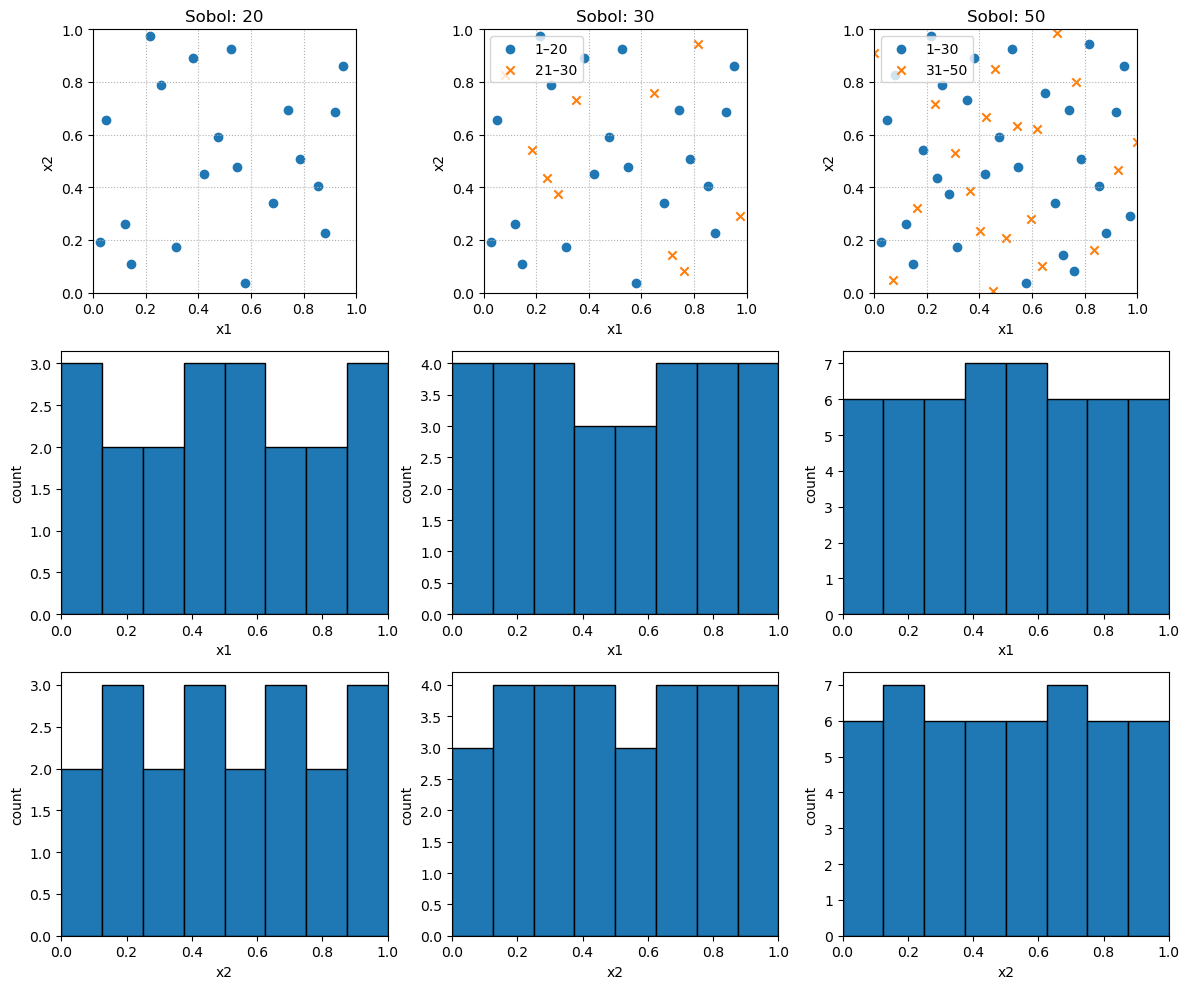

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.quasirandom import SobolEngine

# ------------------------------------------------
# 1) Build a 2D Sobol sequence and draw 50 points
# ------------------------------------------------
sobol = SobolEngine(dimension=2, scramble=True, seed=0)
samples_50 = sobol.draw(50).numpy()

# Slices
s20 = samples_50[:20]
s30 = samples_50[:30]
s50 = samples_50[:50]

s30_new = samples_50[20:30]   # 21–30
s50_new = samples_50[30:50]   # 31–50

datasets = [
    ("Sobol: 20", s20),
    ("Sobol: 30", s30),
    ("Sobol: 50", s50),
]

# ------------------------------------------------
# 2) Plot: for each n, scatter + x-hist + y-hist
# ------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for col, (title, pts) in enumerate(datasets):
    x = pts[:, 0]
    y = pts[:, 1]

    # ---------- Row 1: scatter ----------
    ax_scatter = axes[0, col]

    if col == 0:
        ax_scatter.scatter(x, y, marker="o")
    elif col == 1:
        ax_scatter.scatter(s20[:, 0], s20[:, 1], marker="o", label="1–20")
        ax_scatter.scatter(s30_new[:, 0], s30_new[:, 1], marker="x", label="21–30")
        ax_scatter.legend()
    else:
        ax_scatter.scatter(s30[:, 0], s30[:, 1], marker="o", label="1–30")
        ax_scatter.scatter(s50_new[:, 0], s50_new[:, 1], marker="x", label="31–50")
        ax_scatter.legend()

    ax_scatter.set_title(title)
    ax_scatter.set_xlabel("x1")
    ax_scatter.set_ylabel("x2")
    ax_scatter.set_xlim(0, 1)
    ax_scatter.set_ylim(0, 1)
    ax_scatter.set_aspect("equal", "box")
    ax_scatter.grid(True, linestyle=":")

    # ---------- Row 2: histogram of x1 ----------
    ax_x = axes[1, col]
    ax_x.hist(x, bins=8, range=(0, 1), edgecolor="black", linewidth=1)
    ax_x.set_xlabel("x1")
    ax_x.set_ylabel("count")
    ax_x.set_xlim(0, 1)

    # ---------- Row 3: histogram of x2 ----------
    ax_y = axes[2, col]
    ax_y.hist(y, bins=8, range=(0, 1), edgecolor="black", linewidth=1)
    ax_y.set_xlabel("x2")
    ax_y.set_ylabel("count")
    ax_y.set_xlim(0, 1)

plt.tight_layout()
plt.show()


In [4]:
import torch
import pandas as pd
from torch.quasirandom import SobolEngine

# number of Sobol points you want for the surrogate
n_samples = 30   # change this to 40, 60, etc.

# -------------------------
# Define parameter ranges
# -------------------------
# I treat RT ≈ 25 °C so the surrogate can see a continuous range
bounds = {
    "Power (W)": (10.0, 30.0),
    "Substrate Temp (°C)": (25.0, 400.0),   # RT ≈ 25 °C
    "Oxygen flow rate (sccm)": (0.3, 3.0),
    "Background Pressure (mTorr)": (2.0, 4.0),
    "Annealing temperature (°C)": (150.0, 400.0),
    # Annealing condition is categorical (O2 / N2),
    # we will generate it from a Sobol dim in [0,1]
    "Annealing condition (raw)": (0.0, 1.0),
}

param_names = list(bounds.keys())
dim = len(param_names)

# -------------------------
# Sobol in [0,1]^d
# -------------------------
engine = SobolEngine(dimension=dim, scramble=True, seed=123)
sobol_unit = engine.draw(n_samples)  # shape [n_samples, dim], values in [0,1]

# -------------------------
# Scale numeric parameters
# -------------------------
scaled = {}
for i, name in enumerate(param_names):
    low, high = bounds[name]
    # linear scaling from [0,1] to [low, high]
    scaled[name] = low + (high - low) * sobol_unit[:, i].numpy()

# Convert to DataFrame
df = pd.DataFrame(scaled)

# -------------------------
# Map annealing condition to O2 / N2
# -------------------------
df["Annealing condition"] = df["Annealing condition (raw)"].apply(
    lambda x: "O2" if x < 0.5 else "N2"
)

# Drop the raw helper column
df = df.drop(columns=["Annealing condition (raw)"])

df["Power (W)"] = df["Power (W)"].round(0).astype(int)
df["Background Pressure (mTorr)"] = df["Background Pressure (mTorr)"].round(2)#.astype(int)

df["Substrate Temp (°C)"] = df["Substrate Temp (°C)"].round(0).astype(int)
df["Annealing temperature (°C)"] = df["Annealing temperature (°C)"].round(0).astype(int)


df["Oxygen flow rate (sccm)"] = df["Oxygen flow rate (sccm)"].round(1)

# Optional: order columns to match your Taguchi table
df = df[
    [
        "Power (W)",
        "Substrate Temp (°C)",
        "Oxygen flow rate (sccm)",
        "Background Pressure (mTorr)",
        "Annealing condition",
        "Annealing temperature (°C)",
    ]
]


display(df)
print("Number of samples:", len(df))
print("Unique rows:", len(df.drop_duplicates()))
df.to_excel(
    "output/sobol_experiments.xlsx",
    index=False,
    float_format="%.2f",   # 2 decimals everywhere
)


,Power (W),Substrate Temp (°C),Oxygen flow rate (sccm),Background Pressure (mTorr),Annealing condition,Annealing temperature (°C)
0,12,243,1.4,3.98,N2,389
1,21,134,2.2,2.20,O2,152
2,30,334,0.9,3.17,O2,266
3,19,43,2.7,2.89,N2,277
4,15,365,1.9,2.65,N2,312
5,26,104,1.1,3.44,O2,229
6,23,281,2.4,2.47,O2,187
7,14,189,0.6,3.75,N2,356
8,13,320,2.6,3.37,N2,174
9,24,59,0.4,2.59,O2,382


Number of samples: 30
Unique rows: 30


## SOBOL by steps

,Power (W),Substrate Temp (°C),Oxygen flow rate (sccm),Background Pressure (mTorr),Annealing condition,Annealing temperature (°C)
0,12,400,1.4,3.98,N2,389
1,21,23,2.2,2.20,O2,152
2,30,400,0.9,3.17,O2,266
3,19,23,2.7,2.89,N2,277
4,15,400,1.9,2.65,N2,312
5,26,23,1.1,3.44,O2,229
6,23,400,2.4,2.47,O2,187
7,14,23,0.6,3.75,N2,356
8,13,400,2.6,3.37,N2,174
9,24,23,0.4,2.59,O2,382


Total samples: 20
Unique rows: 20


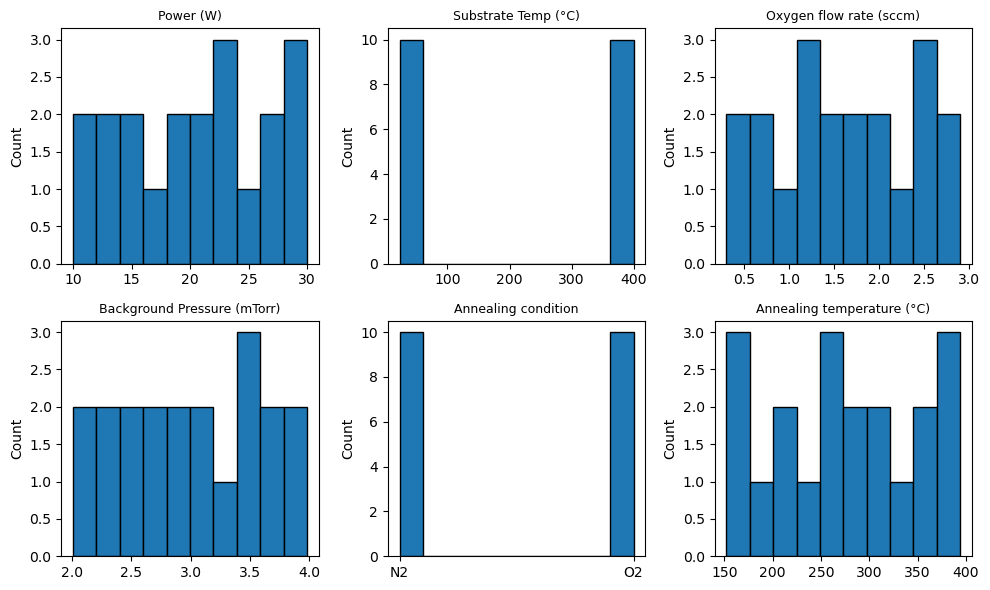

In [5]:
import torch
import pandas as pd
from torch.quasirandom import SobolEngine
import matplotlib.pyplot as plt

# -------------------------
# 1) Define parameter ranges and helpers
# -------------------------
bounds = {
    "Power (W)": (10.0, 30.0),
    "Substrate Temp (°C)": (25.0, 400.0),   # used only for info now
    "Oxygen flow rate (sccm)": (0.3, 3.0),
    "Background Pressure (mTorr)": (2.0, 4.0),
    "Annealing temperature (°C)": (150.0, 400.0),
    # Annealing condition is categorical (O2 / N2),
    # we will generate it from a Sobol dim in [0,1]
    "Annealing condition (raw)": (0.0, 1.0),
}

param_names = list(bounds.keys())
dim = len(param_names)


def sobol_to_df(sobol_unit: torch.Tensor) -> pd.DataFrame:
    """
    Map Sobol points in [0,1]^dim to your parameter ranges,
    apply rounding and categorical mapping, and return a DataFrame.
    """
    scaled = {}
    for i, name in enumerate(param_names):
        # special case: substrate temp is categorical {23, 400}
        if name == "Substrate Temp (°C)":
            raw = sobol_unit[:, i].numpy()  # in [0,1]
            scaled[name] = np.where(raw < 0.5, 23.0, 400.0)
        else:
            low, high = bounds[name]
            scaled[name] = low + (high - low) * sobol_unit[:, i].numpy()

    df = pd.DataFrame(scaled)

    # Map annealing condition to O2 / N2
    df["Annealing condition"] = df["Annealing condition (raw)"].apply(
        lambda x: "O2" if x < 0.5 else "N2"
    )
    df = df.drop(columns=["Annealing condition (raw)"])

    # Rounding rules
    df["Power (W)"] = df["Power (W)"].round(0).astype(int)
    df["Background Pressure (mTorr)"] = df["Background Pressure (mTorr)"].round(2)

    # Substrate temp is already exactly 23 or 400, rounding is harmless
    df["Substrate Temp (°C)"] = df["Substrate Temp (°C)"].round(0).astype(int)
    df["Annealing temperature (°C)"] = df["Annealing temperature (°C)"].round(0).astype(int)

    df["Oxygen flow rate (sccm)"] = df["Oxygen flow rate (sccm)"].round(1)

    # Order columns
    df = df[
        [
            "Power (W)",
            "Substrate Temp (°C)",
            "Oxygen flow rate (sccm)",
            "Background Pressure (mTorr)",
            "Annealing condition",
            "Annealing temperature (°C)",
        ]
    ]
    return df


def generate_sobol_batch(n_existing: int, n_new: int, seed: int = 123) -> pd.DataFrame:
    """
    Generate a new batch of Sobol samples, continuing after n_existing points.

    - n_existing: how many points you already used from this Sobol sequence
    - n_new: how many NEW points you want now
    - seed: keep the same seed every time so skipping works correctly
    """
    engine = SobolEngine(dimension=dim, scramble=True, seed=seed)

    # Skip the first n_existing points
    if n_existing > 0:
        _ = engine.draw(n_existing)

    # Draw only the new points
    sobol_unit_new = engine.draw(n_new)

    # Scale, round, and map to DataFrame
    df_new = sobol_to_df(sobol_unit_new)
    return df_new


# -------------------------
# 2) Example usage
# -------------------------

# First batch: 20 experiments
df_batch1 = generate_sobol_batch(n_existing=0, n_new=20, seed=123)

# Later, you decide to add 10 more experiments
# You already used 20 points, so n_existing = 20
df_batch2 = generate_sobol_batch(n_existing=20, n_new=0, seed=123)

# Combine them
df_all = pd.concat([df_batch1, df_batch2], ignore_index=True)

df_all.to_excel("output/sobol_example.xlsx",
                index=False,
                float_format="%.2f")
display(df_all)
print("Total samples:", len(df_all))
print("Unique rows:", len(df_all.drop_duplicates()))

# -------------------------
# 3) Plot distributions
# -------------------------
cols = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Oxygen flow rate (sccm)",
    "Background Pressure (mTorr)",
    "Annealing condition",
    "Annealing temperature (°C)",
    
]

n = len(cols)
n_rows, n_cols = 2, 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    ax.hist(df_all[col], bins=10, edgecolor="black")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("Count")

# hide any unused subplot
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## Sobol with constrains v03

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from pandas.plotting import scatter_matrix

# -----------------------------------
# Configuration & Batch Settings
# -----------------------------------
n_samples = 30
seed = 42
n_repeats = 3  # Number of times each sample configuration is repeated

# To run just Batch 1, leave as [1]. 
# To run and plot both, change to [1, 2]. 
# To generate ONLY Batch 2, change to [2].
batches_to_run = [1] 

# Bounds
power_bounds = (10.0, 30.0)
oxygen_bounds = (0.3, 3.0)
pressure_bounds = (2.0, 4.0)
anneal_bounds = (150.0, 600.0)

# Sobol dimension
d = 6

def generate_batch(batch_number, n_samples, seed, d):
    """Generates a specific batch of Sobol samples."""
    m = int(np.log2(n_samples))
    if 2**m != n_samples:
        raise ValueError("n_samples must be a power of 2, e.g. 8, 16, 32, 64")

    sampler = qmc.Sobol(d=d, scramble=True, seed=seed)

    # Fast-forward the sequence if we are on a later batch
    if batch_number > 1:
        sampler.fast_forward((batch_number - 1) * n_samples)

    U = sampler.random_base2(m=m)

    # Scale independent continuous variables
    power_float = qmc.scale(U[:, [0]], [power_bounds[0]], [power_bounds[1]]).flatten()
    power = np.round(power_float).astype(int)

    oxygen = qmc.scale(U[:, [2]], [oxygen_bounds[0]], [oxygen_bounds[1]]).flatten()
    pressure = qmc.scale(U[:, [3]], [pressure_bounds[0]], [pressure_bounds[1]]).flatten()

    substrate = np.zeros(n_samples)
    anneal = np.zeros(n_samples, dtype=int) 

    u_sub = U[:, 1]  
    u_ann = U[:, 4]  
    u_cond = U[:, 5] 

    # Map Annealing Condition (50/50 split)
    anneal_cond = np.where(u_cond < 0.5, 'N', 'O')

    eps = 1e-6

    for i in range(n_samples):
        # Evaluate Substrate Temperature
        if u_sub[i] < 0.18:
            s = 25.0
        else:
            s = 400.0 + (2 * u_sub[i] - 1) * (600.0 - 400.0)
        
        substrate[i] = s

        # Evaluate Annealing Temperature
        lower_ann = max(anneal_bounds[0], s + eps)
        upper_ann = anneal_bounds[1]

        if lower_ann >= upper_ann:
            s = anneal_bounds[1] - 2.0  
            substrate[i] = s
            lower_ann = s + eps

        raw_anneal = lower_ann + u_ann[i] * (upper_ann - lower_ann)
        ann_val = int(np.round(raw_anneal))
        
        if ann_val <= s:
            ann_val = int(np.floor(s)) + 1
            
        if ann_val > int(anneal_bounds[1]):
            ann_val = int(anneal_bounds[1])
            if ann_val <= s:
                s = float(ann_val - 1)
                substrate[i] = s
                
        anneal[i] = ann_val

    # Build dataframe for this specific batch
    df = pd.DataFrame({
        "Sample": np.arange(1, n_samples + 1) + ((batch_number - 1) * n_samples),
        "Batch": batch_number,
        "Power (W)": power,
        "Substrate Temperature (C)": substrate,
        "Oxygen Flow Rate (sccm)": oxygen,
        "Background Pressure (Torr)": pressure,
        "Annealing Temperature (C)": anneal,
        "Annealing Condition": anneal_cond
    })
    
    df["Annealing Condition (0=N, 1=O)"] = np.where(df["Annealing Condition"] == 'N', 0, 1)
    df["Constraint OK"] = df["Substrate Temperature (C)"] < df["Annealing Temperature (C)"]
    
    return df

# -----------------------------------
# Execute Generation & Save Files
# -----------------------------------
all_dfs = []

for b in batches_to_run:
    df_b = generate_batch(b, n_samples, seed, d)
    
    # Rounded version for export
    df_export = df_b.copy()
    df_export = df_export.drop(columns=["Annealing Condition (0=N, 1=O)"])

    # Apply Repetitions for Excel
    df_export = df_export.loc[df_export.index.repeat(n_repeats)].reset_index(drop=True)
    df_export.insert(2, "Repetition", df_export.groupby("Sample").cumcount() + 1)

    for c in df_export.columns:
        if c not in ["Sample", "Batch", "Repetition", "Constraint OK", "Power (W)", "Annealing Temperature (C)", "Annealing Condition"]:
            df_export[c] = df_export[c].round(4)

    # Save CSV individual file
    csv_path = f"sobol_constrained_batch_{b}_repeated.xlsx"
    df_export.to_excel(csv_path, index=False)
    
    print(f"Batch {b} Generated. Constraint check passed: {df_b['Constraint OK'].all()}")
    print(f"Saved Excel to: {csv_path} (Contains {len(df_export)} total rows)\n")
    
    all_dfs.append(df_b)

# Combine all generated batches into one dataframe for plotting (WITHOUT repetitions)
df_combined = pd.concat(all_dfs, ignore_index=True)

# -----------------------------------
# Visualizations (Combined, No Repetitions)
# -----------------------------------
plot_cols = [
    "Power (W)",
    "Substrate Temperature (C)",
    "Oxygen Flow Rate (sccm)",
    "Background Pressure (Torr)",
    "Annealing Temperature (C)",
    "Annealing Condition (0=N, 1=O)"
]

# Create dynamic strings for titles and filenames
batch_str = "_".join(map(str, batches_to_run))
title_suffix = f"Batch {batch_str}" if len(batches_to_run) == 1 else f"Batches {', '.join(map(str, batches_to_run))}"

# Color code: Blue for Batch 1, Orange for Batch 2
colors = np.where(df_combined["Batch"] == 1, 'tab:blue', 'tab:orange') if len(batches_to_run) > 1 else 'tab:blue'

axes = scatter_matrix(
    df_combined[plot_cols],
    figsize=(14, 14),
    diagonal="hist",
    alpha=0.8,
    color=colors,
    grid=False
)

# --- NEW: Rotate text in scatter matrix to 45 degrees ---
for ax in axes.flatten():
    # Rotate the variable names on the edges
    ax.xaxis.label.set_rotation(45)
    ax.xaxis.label.set_ha('right')
    ax.yaxis.label.set_rotation(45)
    ax.yaxis.label.set_ha('right')
    
    # Rotate the actual tick numbers
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=45, ha='right')

plt.suptitle(f"Sobol Pairplot - {title_suffix}", y=0.92, fontsize=16)
plt.savefig(f"sobol_pairplot_batches_{batch_str}.png", dpi=300, bbox_inches="tight")
plt.show()

# Correlation matrix
corr = df_combined[plot_cols].corr()
print(f"Correlation matrix ({title_suffix}):")
print(corr.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, interpolation="nearest", aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(plot_cols)))
ax.set_xticklabels(plot_cols, rotation=45, ha="right")

ax.set_yticks(range(len(plot_cols)))
# --- NEW: Rotate y-axis text in correlation matrix to 45 degrees ---
ax.set_yticklabels(plot_cols, rotation=45, ha="right")

ax.set_title(f"Correlation matrix - {title_suffix}")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(f"sobol_correlation_batches_{batch_str}.png", dpi=300, bbox_inches="tight")
plt.show()

ValueError: n_samples must be a power of 2, e.g. 8, 16, 32, 64

## Sobol w contrained substrate 0 or 400 and above 

<>:221: SyntaxWarning: invalid escape sequence '\g'
<>:221: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2110232/3742772306.py:221: SyntaxWarning: invalid escape sequence '\g'
  ax.fill_between([0, 700], [0, 700], 0, color='red', alpha=0.10, label='Infeasible ($T_{sub} \geq T_{anneal}$)')
/tmp/ipykernel_2110232/3742772306.py:38: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  U = sampler.random(n=n_samples)


Batch 1 Generated. Constraint check passed: True
Saved Excel to: output/DoE/sobol_constrained_batch_1_repeated.xlsx (Contains 90 total rows)



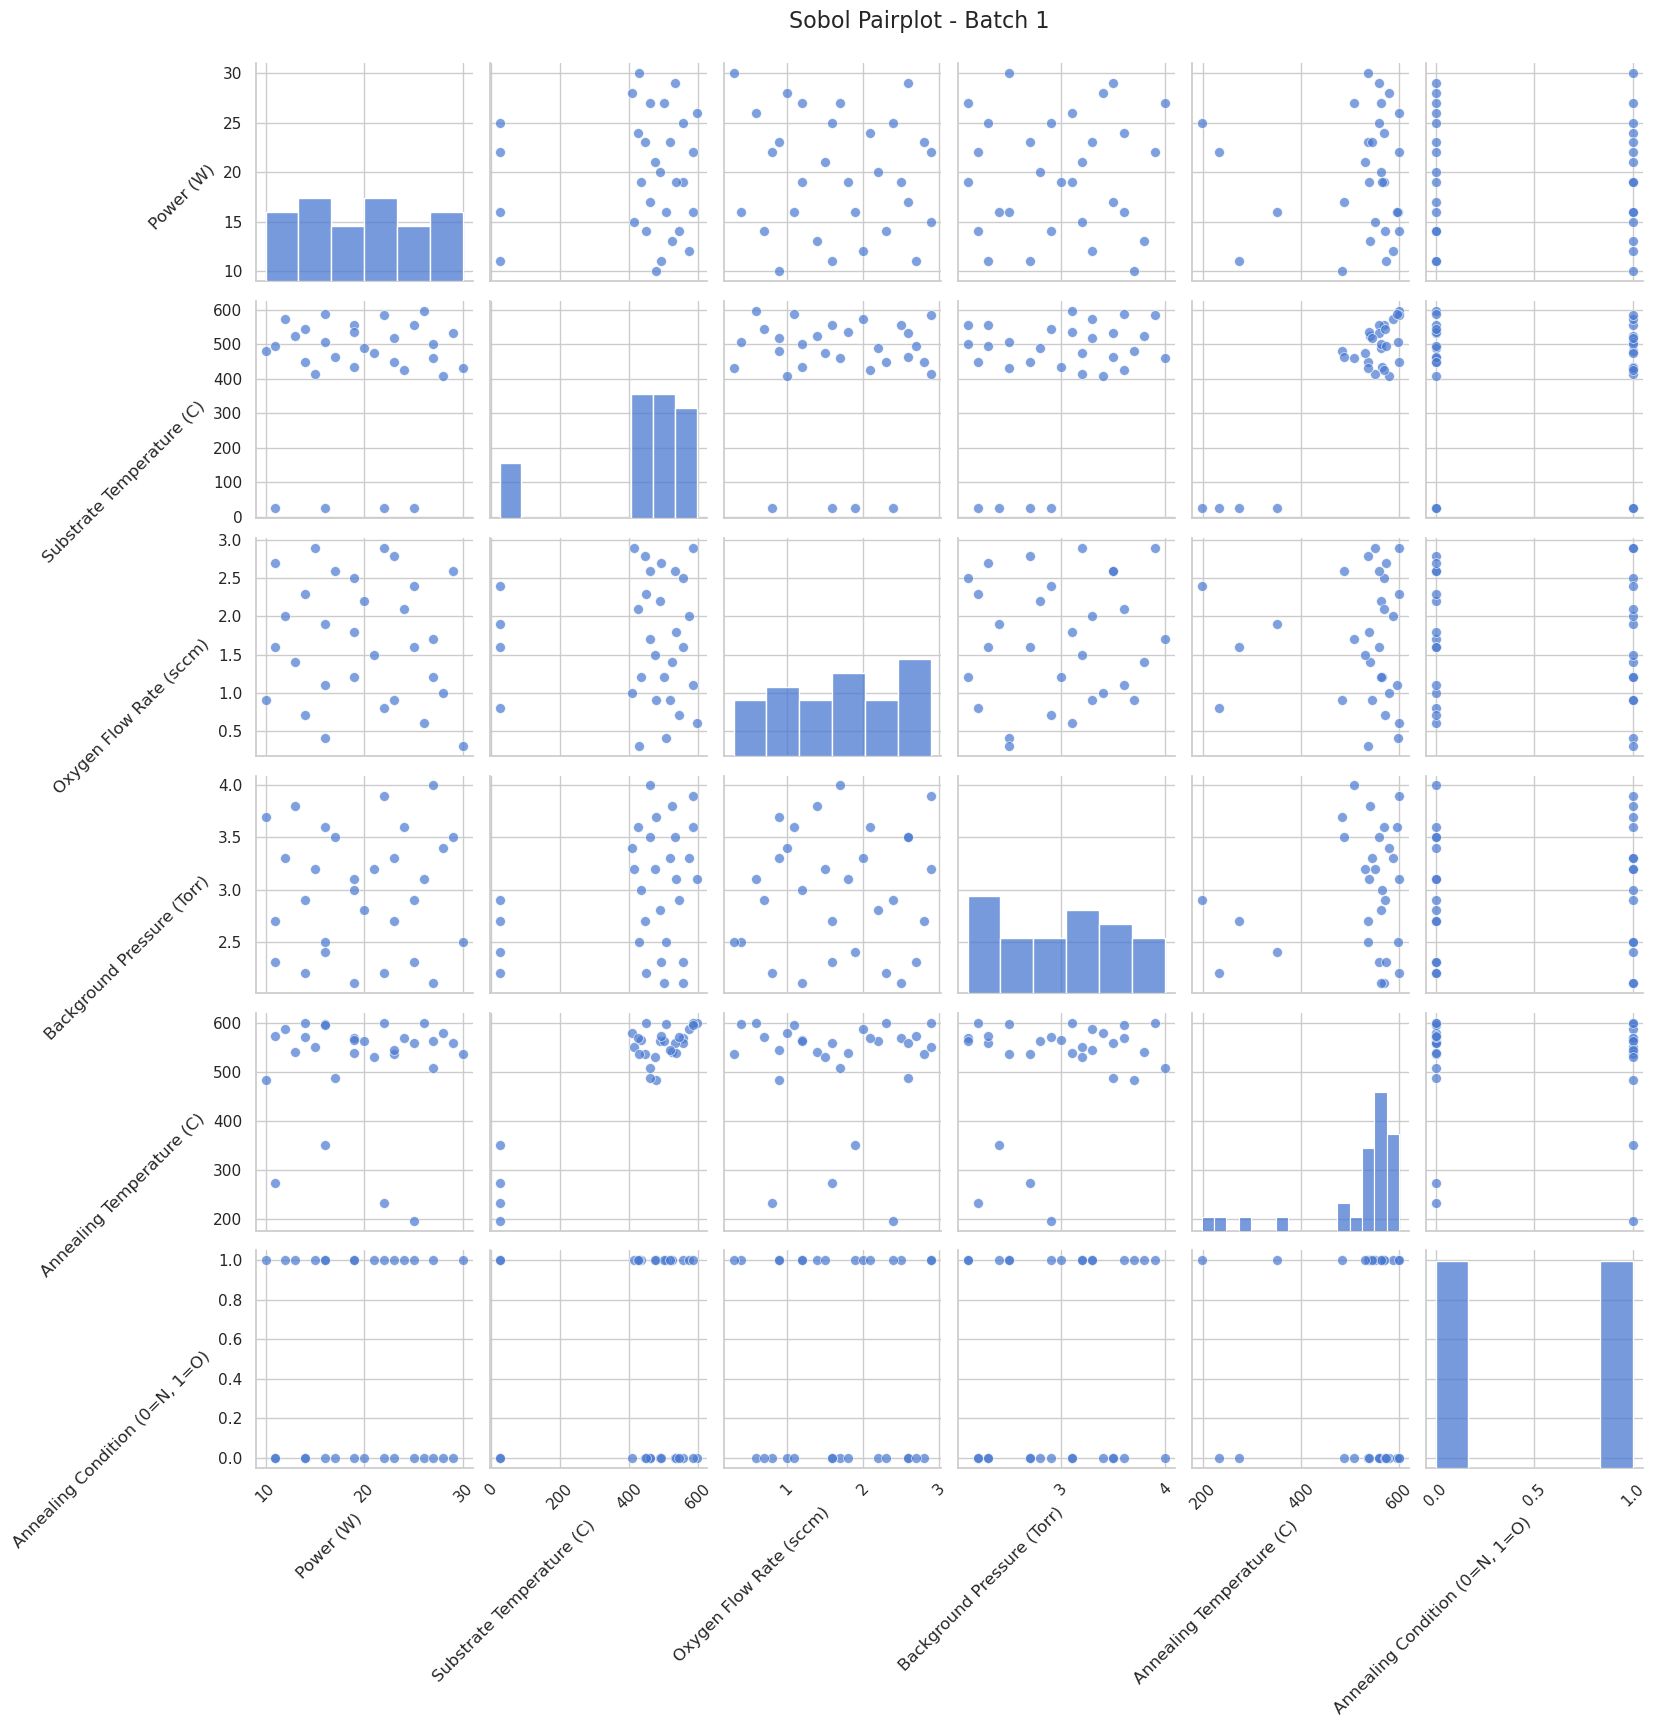

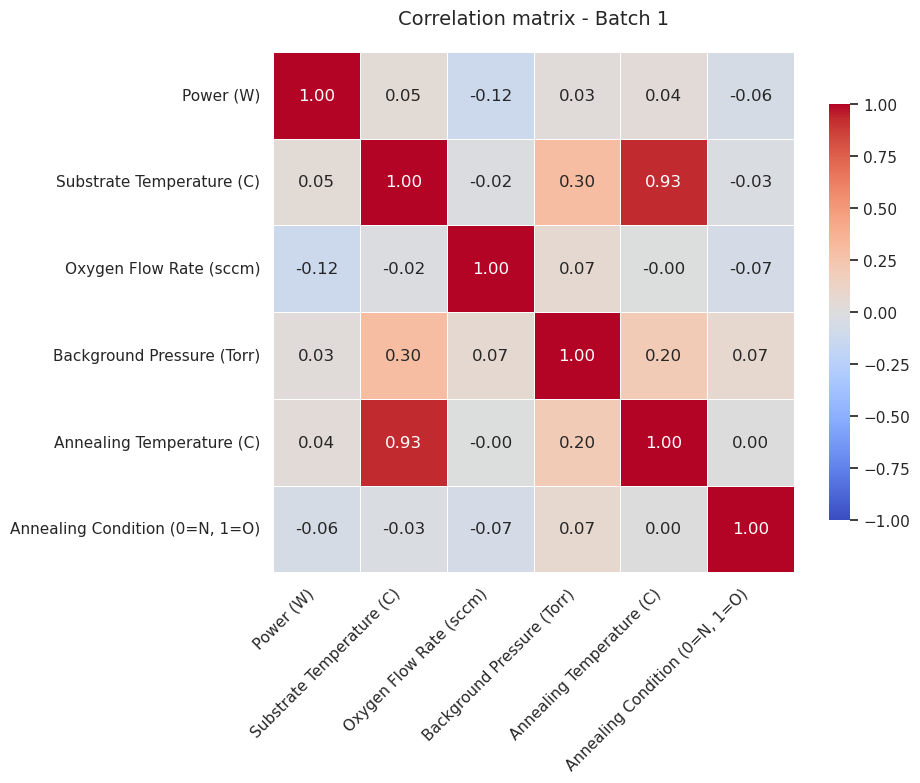

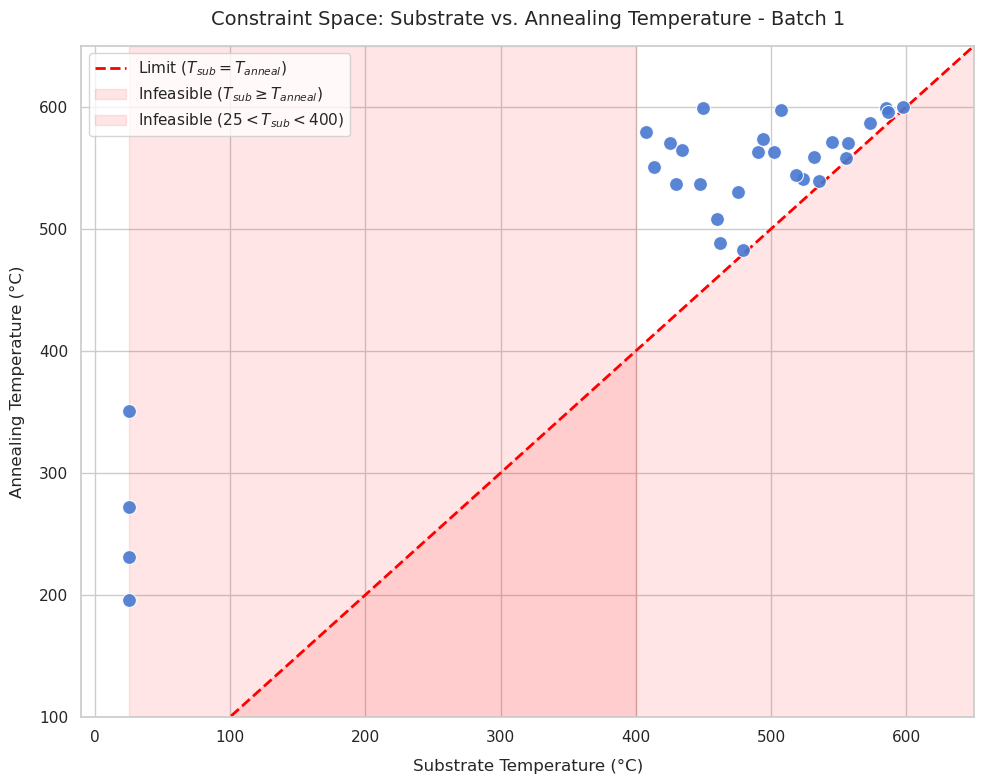

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
import seaborn as sns 

# -----------------------------------
# Configuration & Batch Settings
# -----------------------------------
n_samples = 30
seed = 42
n_repeats = 3  # Number of times each sample configuration is repeated
prob_room_temp = 0.14  # Probability (0.0 to 1.0) of Substrate being at Room Temp (25 C)

# To run just Batch 1, leave as [1]. 
# To run and plot both, change to [1, 2]. 
# To generate ONLY Batch 2, change to [2].
batches_to_run = [1] 

# Bounds
power_bounds = (10.0, 30.0)
oxygen_bounds = (0.3, 3.0)
pressure_bounds = (2.0, 4.0)
anneal_bounds = (150.0, 600.0)

# Sobol dimension
d = 6

def generate_batch(batch_number, n_samples, seed, d):
    """Generates a specific batch of Sobol samples."""
    sampler = qmc.Sobol(d=d, scramble=True, seed=seed)

    # Fast-forward the sequence if we are on a later batch
    if batch_number > 1:
        sampler.fast_forward((batch_number - 1) * n_samples)

    # Use .random() instead of .random_base2() to allow any integer
    U = sampler.random(n=n_samples)

    # Scale independent continuous variables
    power_float = qmc.scale(U[:, [0]], [power_bounds[0]], [power_bounds[1]]).flatten()
    power = np.round(power_float).astype(int)

    oxygen = qmc.scale(U[:, [2]], [oxygen_bounds[0]], [oxygen_bounds[1]]).flatten()
    pressure = qmc.scale(U[:, [3]], [pressure_bounds[0]], [pressure_bounds[1]]).flatten()

    substrate = np.zeros(n_samples)
    anneal = np.zeros(n_samples, dtype=int) 

    u_sub = U[:, 1]  
    u_ann = U[:, 4]  
    u_cond = U[:, 5] 

    # Map Annealing Condition (50/50 split)
    anneal_cond = np.where(u_cond < 0.5, 'N', 'O')

    eps = 1e-6

    for i in range(n_samples):
        # Evaluate Substrate Temperature
        if u_sub[i] < prob_room_temp:
            s = 25.0
        else:
            # Correctly map the remaining probability range to [400, 600]
            s = 400.0 + ((u_sub[i] - prob_room_temp) / (1.0 - prob_room_temp)) * (600.0 - 400.0)
        
        substrate[i] = s

        # Evaluate Annealing Temperature
        lower_ann = max(anneal_bounds[0], s + eps)
        upper_ann = anneal_bounds[1]

        if lower_ann >= upper_ann:
            s = anneal_bounds[1] - 2.0  
            substrate[i] = s
            lower_ann = s + eps

        raw_anneal = lower_ann + u_ann[i] * (upper_ann - lower_ann)
        ann_val = int(np.round(raw_anneal))
        
        if ann_val <= s:
            ann_val = int(np.floor(s)) + 1
            
        if ann_val > int(anneal_bounds[1]):
            ann_val = int(anneal_bounds[1])
            if ann_val <= s:
                s = float(ann_val - 1)
                substrate[i] = s
                
        anneal[i] = ann_val

    # Build dataframe for this specific batch
    # --- CHANGED: Applied np.round(..., 1) directly to the arrays ---
    df = pd.DataFrame({
        "Sample": np.arange(1, n_samples + 1) + ((batch_number - 1) * n_samples),
        "Batch": batch_number,
        "Power (W)": power,
        "Substrate Temperature (C)": np.round(substrate, 1),
        "Oxygen Flow Rate (sccm)": np.round(oxygen, 1),
        "Background Pressure (Torr)": np.round(pressure, 1),
        "Annealing Temperature (C)": anneal,
        "Annealing Condition": anneal_cond
    })
    
    df["Annealing Condition (0=N, 1=O)"] = np.where(df["Annealing Condition"] == 'N', 0, 1)
    df["Constraint OK"] = df["Substrate Temperature (C)"] < df["Annealing Temperature (C)"]
    
    return df

# -----------------------------------
# Execute Generation & Save Files
# -----------------------------------
all_dfs = []

for b in batches_to_run:
    df_b = generate_batch(b, n_samples, seed, d)
    
    # Rounded version for export
    df_export = df_b.copy()
    df_export = df_export.drop(columns=["Annealing Condition (0=N, 1=O)"])

    # Apply Repetitions for Excel
    df_export = df_export.loc[df_export.index.repeat(n_repeats)].reset_index(drop=True)
    
    # Insert Repetition at index 1 (right after Sample)
    df_export.insert(1, "Repetition", df_export.groupby("Sample").cumcount() + 1)

    # Move Batch column to the far right
    cols = list(df_export.columns)
    cols.remove("Batch")
    cols.append("Batch")
    df_export = df_export[cols]

    # Save CSV individual file
    csv_path = f"output/DoE/sobol_constrained_batch_{b}_repeated.xlsx"
    df_export.to_excel(csv_path, index=False)
    
    print(f"Batch {b} Generated. Constraint check passed: {df_b['Constraint OK'].all()}")
    print(f"Saved Excel to: {csv_path} (Contains {len(df_export)} total rows)\n")
    
    all_dfs.append(df_b)

# Combine all generated batches into one dataframe for plotting (WITHOUT repetitions)
df_combined = pd.concat(all_dfs, ignore_index=True)

# -----------------------------------
# Visualizations (Combined, No Repetitions)
# -----------------------------------

# Set a clean, professional aesthetic for the plots
sns.set_theme(style="whitegrid", palette="muted")

plot_cols = [
    "Power (W)",
    "Substrate Temperature (C)",
    "Oxygen Flow Rate (sccm)",
    "Background Pressure (Torr)",
    "Annealing Temperature (C)",
    "Annealing Condition (0=N, 1=O)"
]

# Create dynamic strings for titles and filenames
batch_str = "_".join(map(str, batches_to_run))
title_suffix = f"Batch {batch_str}" if len(batches_to_run) == 1 else f"Batches {', '.join(map(str, batches_to_run))}"

# 1. Prettier Pairplot using Seaborn
pairplot_cols = plot_cols #+ ["Batch"]

g = sns.pairplot(
    df_combined[pairplot_cols], 
    hue="Batch" if len(batches_to_run) > 1 else None,
    palette="husl" if len(batches_to_run) > 1 else None,
    diag_kind="hist",
    corner=False,
    plot_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'w'}, 
    diag_kws={'edgecolor': 'white'}
)

g.fig.suptitle(f"Sobol Pairplot - {title_suffix}", y=1.02, fontsize=16)

for ax in g.axes.flatten():
    if ax is not None:
        ax.xaxis.label.set_rotation(45)
        ax.xaxis.label.set_ha('right')
        ax.yaxis.label.set_rotation(45)
        ax.yaxis.label.set_ha('right')
        ax.tick_params(axis='x', labelrotation=45)

plt.savefig(f"output/DoE/sobol_pairplot_batches_{batch_str}.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Prettier Correlation Matrix using Seaborn Heatmap
corr = df_combined[plot_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, 
    annot=True,      
    fmt=".2f",       
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    square=True,     
    linewidths=.5,   
    cbar_kws={"shrink": .8}, 
    ax=ax
)

ax.set_title(f"Correlation matrix - {title_suffix}", pad=20, fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0) 

plt.tight_layout()
plt.savefig(f"output/DoE/sobol_correlation_batches_{batch_str}.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Constraint Visualization: Substrate vs Annealing Temperature
fig, ax = plt.subplots(figsize=(10, 8))

# Draw the constraint line (y = x) and fill the diagonal infeasible region
ax.plot([0, 700], [0, 700], color='red', linestyle='--', linewidth=2, label='Limit ($T_{sub} = T_{anneal}$)')
ax.fill_between([0, 700], [0, 700], 0, color='red', alpha=0.10, label='Infeasible ($T_{sub} \geq T_{anneal}$)')

# Vertical infeasible region for the Substrate Temperature gap
ax.axvspan(25, 400, color='red', alpha=0.10, label='Infeasible ($25 < T_{sub} < 400$)')

# Scatter the actual data points (zorder=5 ensures dots sit on top of the red shading)
sns.scatterplot(
    data=df_combined,
    x="Substrate Temperature (C)",
    y="Annealing Temperature (C)",
    hue="Batch" if len(batches_to_run) > 1 else None,
    palette="husl" if len(batches_to_run) > 1 else None,
    s=100,
    alpha=0.9,
    edgecolor='w',
    zorder=5, 
    ax=ax
)

# Define limits to make the plot look clean
ax.set_xlim(-10, 650)
ax.set_ylim(100, 650)

ax.set_title(f"Constraint Space: Substrate vs. Annealing Temperature - {title_suffix}", fontsize=14, pad=15)
ax.set_xlabel("Substrate Temperature (°C)", fontsize=12, labelpad=10)
ax.set_ylabel("Annealing Temperature (°C)", fontsize=12, labelpad=10)

# Move the legend outside or to a clean spot so it doesn't cover data
ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig(f"output/DoE/sobol_constraint_space_batches_{batch_str}.png", dpi=300, bbox_inches="tight")
plt.show()

# Preparing the master file

## V01

In [ ]:
import pandas as pd
import numpy as np
import re
import datetime as dt

file_path = "XPS & XRD.xlsx"   # <- your attached iteration 1 file

# -----------------------------
# Load sheets (iteration 1 names)
# -----------------------------
df_exp = pd.read_excel(file_path, sheet_name="Experiments")
df_xps = pd.read_excel(file_path, sheet_name="XPS")
df_xrd = pd.read_excel(file_path, sheet_name="XRD")

# -----------------------------
# Helper parsers
# -----------------------------
def extract_int(x):
    m = re.search(r"(\d+)", str(x))
    return int(m.group(1)) if m else np.nan

def normalize_temp(v):
    s = str(v).strip().upper()
    if s == "RT":
        return 25
    # handles strings like "150 C"
    m = re.search(r"(\d+(\.\d+)?)", s)
    return float(m.group(1)) if m else np.nan

def time_to_float(v):
    # Some FWHM cells are stored as Excel time (datetime.time). Use microseconds as decimal part.
    if isinstance(v, dt.time):
        # common weird case: 00:01:00.430000 -> we treat as 0.43
        if v.second == 0 and v.microsecond > 0:
            return v.microsecond / 1e6
        # fallback: convert full time to seconds (rare)
        return v.minute * 60 + v.second + v.microsecond / 1e6
    return pd.to_numeric(v, errors="coerce")

# -----------------------------
# Standardize column names to your "canonical" names
# -----------------------------
df_exp = df_exp.rename(columns={
    "Experiments": "Experiment",
    "Power_W": "Power (W)",
    "Substrate_Temp_C": "Substrate Temp (°C)",
    "O2_flow_sccm": "O2 Flow (sccm)",
    "Background_Pressure_mTorr": "Pressure (mTorr)",
    "Annealing_condition": "Anneal Condition",
    "Annealing_temperature": "Anneal Temp (°C)",
    "Hall_mobility_cm2_per_Vs": "Hall Mobility (cm^2/V·s)",
})

df_xps = df_xps.rename(columns={
    "Experiments": "Experiment",
    "In3d_p1": "In3d01",
    "In3d_p2": "In3d02",
    "O1s_p1": "O1s",
    "Ta4f_p1": "Ta4f01",
    "Ta4f_p2": "Ta4f02",
})

df_xrd = df_xrd.rename(columns={
    "Experiments": "Experiment",
    "Peak01_position": "Peak01",
    "Peak02_position": "Peak02",
    "Height_01": "Height01",
    "height_02": "Height02",
    "FWHM_01": "FWHM01",
    "FWHM_02": "FWHM02",
})

# -----------------------------
# Clean / parse key fields
# -----------------------------
# Experiment IDs
df_exp["Experiment"] = pd.to_numeric(df_exp["Experiment"], errors="coerce")
df_xps["Experiment"] = df_xps["Experiment"].apply(extract_int)
df_xrd["Experiment"] = df_xrd["Experiment"].apply(extract_int)

# Trial is already present in XPS/XRD
df_xps["Trial"] = pd.to_numeric(df_xps["Trial"], errors="coerce").astype("Int64")
df_xrd["Trial"] = pd.to_numeric(df_xrd["Trial"], errors="coerce").astype("Int64")

# Temps
df_exp["Substrate Temp (°C)"] = df_exp["Substrate Temp (°C)"].apply(normalize_temp)
df_exp["Anneal Temp (°C)"] = df_exp["Anneal Temp (°C)"].apply(normalize_temp)

# Make numeric where appropriate (leave "Too weak"/"Too low" etc as NaN)
num_cols_exp = ["Power (W)", "Substrate Temp (°C)", "O2 Flow (sccm)", "Pressure (mTorr)",
                "Anneal Temp (°C)", "Hall Mobility (cm^2/V·s)"]
for c in num_cols_exp:
    if c in df_exp.columns:
        df_exp[c] = pd.to_numeric(df_exp[c], errors="coerce")

for c in ["In3d01", "In3d02", "O1s", "Area_In3d", "Area_O1s", "Area_Ta4f"]:
    if c in df_xps.columns:
        df_xps[c] = pd.to_numeric(df_xps[c], errors="coerce")

# XRD numeric + fix time-formatted FWHM
for c in ["Peak01", "Peak02", "Height01", "Height02"]:
    if c in df_xrd.columns:
        df_xrd[c] = pd.to_numeric(df_xrd[c], errors="coerce")
for c in ["FWHM01", "FWHM02"]:
    if c in df_xrd.columns:
        df_xrd[c] = df_xrd[c].apply(time_to_float)

# -----------------------------
# Add Trial to Experiments sheet by broadcasting to 1..3
# -----------------------------
trials = [1, 2, 3]
df_exp = (
    df_exp.assign(_k=1)
          .merge(pd.DataFrame({"Trial": trials, "_k": 1}), on="_k")
          .drop(columns="_k")
)
df_exp["Trial"] = df_exp["Trial"].astype("Int64")

# Anneal Condition Num like your original code
df_exp["Anneal Condition Num"] = (
    df_exp["Anneal Condition"].astype(str).str.strip().str.upper()
    .map({"O2": 1, "N2": 2})
    .fillna(0).astype(int)
)

# -----------------------------
# Build master like your original
# -----------------------------
master_df = (
    df_exp
    .merge(df_xps, on=["Experiment", "Trial"], how="left")
    .merge(df_xrd, on=["Experiment", "Trial"], how="left")
)

# Keep old behavior: missing heights -> 0
for col in ["Height01", "Height02", "Height03"]:
    if col in master_df.columns:
        master_df[col] = master_df[col].fillna(0)

# Put core columns first
cols_order = ["Experiment", "Trial", "Anneal Condition Num"]
other_cols = [c for c in master_df.columns if c not in cols_order]
master_df = master_df[cols_order + other_cols]

display(master_df)

In [ ]:
# import pandas as pd
# master_df = pd.read_excel("master_xps_xrd_iteration0.xlsx")
# display(master_df)

,Experiment,Trial,Anneal Condition Num,Power (W),Substrate Temp (°C),O2 Flow (sccm),Pressure (mTorr),Anneal Condition,Anneal Temp (°C),Hall Mobility (cm^2/V·s),...,Area_Ta4f,Peak01,Peak02,Peak03,Height01,Height02,Height03,FWHM01,FWHM02,FWHM03
0,1,1,1,10,25,0.3,2,O2,150,12.20,...,0.0,30.7,32.4,35.1,328,1253,1076,0.12,0.26,0.12
1,1,2,1,10,25,0.3,2,O2,150,3.02,...,0.0,30.7,35.4,NaN,689,832,0,0.09,0.05,NaN
2,1,3,1,10,25,0.3,2,O2,150,49.50,...,0.0,30.6,35.4,NaN,1261,630,0,0.35,0.20,NaN
3,2,1,2,10,25,0.3,4,N2,400,9.03,...,0.0,30.5,35.6,NaN,853,519,0,0.15,0.20,NaN
4,2,2,2,10,25,0.3,4,N2,400,NaN,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN
5,2,3,2,10,25,0.3,4,N2,400,17.20,...,0.0,30.7,35.5,NaN,1312,486,0,0.55,NaN,NaN
6,3,1,1,10,400,3.0,2,O2,400,61.80,...,0.0,30.4,NaN,NaN,11239,0,0,0.69,NaN,NaN
7,3,2,1,10,400,3.0,2,O2,400,60.00,...,0.0,30.5,NaN,NaN,11477,0,0,0.67,NaN,NaN
8,3,3,1,10,400,3.0,2,O2,400,58.20,...,0.0,30.4,NaN,NaN,11524,0,0,0.68,NaN,NaN
9,4,1,2,10,400,3.0,4,N2,150,30.50,...,0.0,30.1,NaN,NaN,2849,0,0,1.00,NaN,NaN


## V02

In [13]:
import pandas as pd

# 1) path to your file
file_path = "XPS & XRD_11_06_25.xlsx"   # change to full path if needed

# 2) load the 3 sheets
df_exp = pd.read_excel(file_path, sheet_name="Experiments_v00")
df_xps = pd.read_excel(file_path, sheet_name="XPS")
df_xrd = pd.read_excel(file_path, sheet_name="XRD")

# 2) map anneal condition to numeric
# O2 -> 1, N2 -> 2, everything else -> 0
df_exp["Anneal Condition Num"] = (
    df_exp["Anneal Condition"]
    .str.strip()
    .str.upper()
    .map({"O2": 1, "N2": 2})
    .astype(int)
)


# df_exp.drop(columns=["Anneal Condition"], inplace=True)
#df_exp
master_df = (
    df_exp
    .merge(df_xps, on=["Experiment", "Trial"], how="left")
    .merge(df_xrd, on=["Experiment", "Trial"], how="left")
)

for col in ["Height01", "Height02", "Height03"]:
    if col in master_df.columns:
        master_df[col] = master_df[col].fillna(0)



cols_order = ["Experiment", "Trial", "Anneal Condition Num"]
other_cols = [c for c in master_df.columns if c not in cols_order]
master_df = master_df[cols_order + other_cols]
display(master_df)
master_df.to_excel("output/master_xps_xrd.xlsx", index=False)
print(master_df)

,Experiment,Trial,Anneal Condition Num,Power (W),Substrate Temp (°C),O2 Flow (sccm),Pressure (mTorr),Anneal Condition,Anneal Temp (°C),Hall Mobility (cm^2/V·s),...,Area_Ta4f,Peak01,Peak02,Peak03,Height01,Height02,Height03,FWHM01,FWHM02,FWHM03
0,1,1,1,10,25,0.3,2,O2,150,12.20,...,0.0,30.7,32.4,35.1,328,1253,1076,0.12,0.26,0.12
1,1,2,1,10,25,0.3,2,O2,150,3.02,...,0.0,30.7,35.4,NaN,689,832,0,0.09,0.05,NaN
2,1,3,1,10,25,0.3,2,O2,150,49.50,...,0.0,30.6,35.4,NaN,1261,630,0,0.35,0.20,NaN
3,2,1,2,10,25,0.3,4,N2,400,9.03,...,0.0,30.5,35.6,NaN,853,519,0,0.15,0.20,NaN
4,2,2,2,10,25,0.3,4,N2,400,NaN,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN
5,2,3,2,10,25,0.3,4,N2,400,17.20,...,0.0,30.7,35.5,NaN,1312,486,0,0.55,NaN,NaN
6,3,1,1,10,400,3.0,2,O2,400,61.80,...,0.0,30.4,NaN,NaN,11239,0,0,0.69,NaN,NaN
7,3,2,1,10,400,3.0,2,O2,400,60.00,...,0.0,30.5,NaN,NaN,11477,0,0,0.67,NaN,NaN
8,3,3,1,10,400,3.0,2,O2,400,58.20,...,0.0,30.4,NaN,NaN,11524,0,0,0.68,NaN,NaN
9,4,1,2,10,400,3.0,4,N2,150,30.50,...,0.0,30.1,NaN,NaN,2849,0,0,1.00,NaN,NaN


    Experiment  Trial  Anneal Condition Num  Power (W)  Substrate Temp (°C)  \
0            1      1                     1         10                   25   
1            1      2                     1         10                   25   
2            1      3                     1         10                   25   
3            2      1                     2         10                   25   
4            2      2                     2         10                   25   
5            2      3                     2         10                   25   
6            3      1                     1         10                  400   
7            3      2                     1         10                  400   
8            3      3                     1         10                  400   
9            4      1                     2         10                  400   
10           4      2                     2         10                  400   
11           4      3                     2         

In [7]:
import pandas as pd
import numpy as np

# =========================================================
# SETTINGS
# =========================================================
file_path = "XPS & XRD_11_06_25.xlsx"   # change if needed
output_path = "output/XPS_XRD_with_newdata_clean.xlsx"

# Backward compatibility: old files often used 0 for "Too low" Ta4f area.
# If False, keep NaN instead.
TOO_LOW_AS_ZERO = True

# =========================================================
# HELPERS
# =========================================================
def standardize_columns(df, alias_map):
    """
    alias_map format:
      canonical_name: [canonical_name, alias1, alias2, ...]
    """
    out = df.copy()
    rename_dict = {}
    for canon, aliases in alias_map.items():
        for a in aliases:
            if a in out.columns and a != canon:
                rename_dict[a] = canon
                break
    return out.rename(columns=rename_dict)

def append_dedup(old_df, new_df, keys=("Experiment", "Trial")):
    combined = pd.concat([old_df, new_df], ignore_index=True, sort=False)
    combined = combined.drop_duplicates(subset=list(keys), keep="last")
    combined = combined.sort_values(list(keys)).reset_index(drop=True)
    return combined

def to_num(v):
    return pd.to_numeric(pd.Series([v]), errors="coerce").iloc[0]

def split_pair(v):
    """
    "451.5,443.9" -> (451.5, 443.9, "OK")
    non-pair text     -> (NaN, NaN, original_text)
    """
    if isinstance(v, str) and "," in v:
        a, b = v.split(",")
        return float(a.strip()), float(b.strip()), "OK"
    return np.nan, np.nan, str(v)

def normalize_substrate_temp(v):
    # Keep legacy consistency (old data used 25 instead of RT)
    if isinstance(v, str) and v.strip().upper() == "RT":
        return 25
    return v

# =========================================================
# 0) LOAD CURRENT WORKBOOK
# =========================================================
df_exp = pd.read_excel(file_path, sheet_name="Experiments_v00")
df_xps = pd.read_excel(file_path, sheet_name="XPS")
df_xrd = pd.read_excel(file_path, sheet_name="XRD")

# Canonical legacy names
exp_alias = {
    "Experiment": ["Experiment", "Condition"],
    "Trial": ["Trial", "Sample"],
    "Power (W)": ["Power (W)", "Power(W)"],
    "Substrate Temp (°C)": ["Substrate Temp (°C)", "Substrate Temperature(°C)"],
    "O2 Flow (sccm)": ["O2 Flow (sccm)", "O2 flow rate(sccm)", "O: flow rate(sccm)"],
    "Pressure (mTorr)": ["Pressure (mTorr)", "Pressure(mTorr)"],
    "Anneal Condition": ["Anneal Condition", "Annealing condition"],
    "Anneal Temp (°C)": ["Anneal Temp (°C)", "Anneal Temperature(°C)", "Annealing temperature(°C)"],
    "Hall Mobility (cm^2/V·s)": ["Hall Mobility (cm^2/V·s)", "Hall mobility(cm^2/V-s)", "Hall mobility(cm^2/V·s)"],
}

xps_alias = {
    "Experiment": ["Experiment", "Condition"],
    "Trial": ["Trial", "Sample"],
    "Area_In3d": ["Area_In3d", "Area In3d"],
    "Area_O1s": ["Area_O1s", "Area O1s"],
    "Area_Ta4f": ["Area_Ta4f", "Area Ta4f"],
    "O1s": ["O1s"],
    "In3d01": ["In3d01", "In3d_1"],
    "In3d02": ["In3d02", "In3d_2"],
    "Ta4f01": ["Ta4f01", "Ta4f_1"],
    "Ta4f02": ["Ta4f02", "Ta4f_2"],
}

xrd_alias = {
    "Experiment": ["Experiment", "Condition"],
    "Trial": ["Trial", "Sample"],
    "Peak01": ["Peak01", "Peak position"],
    "Peak02": ["Peak02"],
    "Peak03": ["Peak03"],
    "Height01": ["Height01", "Height"],
    "Height02": ["Height02"],
    "Height03": ["Height03"],
    "FWHM01": ["FWHM01", "FWHM"],
    "FWHM02": ["FWHM02"],
    "FWHM03": ["FWHM03"],
}

df_exp = standardize_columns(df_exp, exp_alias)
df_xps = standardize_columns(df_xps, xps_alias)
df_xrd = standardize_columns(df_xrd, xrd_alias)

# =========================================================
# 1) NEW EXPERIMENT DATA (9-17)
# =========================================================
conditions = {
    9:  {"Power (W)": 20, "Substrate Temp (°C)": "RT", "O2 Flow (sccm)": 3,   "Pressure (mTorr)": 4, "Anneal Condition": "N2", "Anneal Temp (°C)": 400, "Hall mobility raw": [58.6, 59.8, 48.0]},
    10: {"Power (W)": 30, "Substrate Temp (°C)": "RT", "O2 Flow (sccm)": 0.3, "Pressure (mTorr)": 4, "Anneal Condition": "O2", "Anneal Temp (°C)": 600, "Hall mobility raw": [9.83, 4.03, 11.7]},
    11: {"Power (W)": 20, "Substrate Temp (°C)": 400,  "O2 Flow (sccm)": 2,   "Pressure (mTorr)": 4, "Anneal Condition": "O2", "Anneal Temp (°C)": 600, "Hall mobility raw": [90.5, 91.4, 90.3]},
    12: {"Power (W)": 20, "Substrate Temp (°C)": 400,  "O2 Flow (sccm)": 0.3, "Pressure (mTorr)": 2, "Anneal Condition": "N2", "Anneal Temp (°C)": 600, "Hall mobility raw": [49.6, 70.7, 54.5]},
    13: {"Power (W)": 10, "Substrate Temp (°C)": "RT", "O2 Flow (sccm)": 2,   "Pressure (mTorr)": 4, "Anneal Condition": "N2", "Anneal Temp (°C)": 600, "Hall mobility raw": [87.8, 87.3, 50.5]},
    14: {"Power (W)": 20, "Substrate Temp (°C)": "RT", "O2 Flow (sccm)": 2,   "Pressure (mTorr)": 2, "Anneal Condition": "N2", "Anneal Temp (°C)": 150, "Hall mobility raw": ["Insulating", "Insulating", "Insulating"]},
    15: {"Power (W)": 30, "Substrate Temp (°C)": 400,  "O2 Flow (sccm)": 2,   "Pressure (mTorr)": 2, "Anneal Condition": "N2", "Anneal Temp (°C)": 600, "Hall mobility raw": [63.8, 37.5, 74.1]},
    16: {"Power (W)": 20, "Substrate Temp (°C)": 400,  "O2 Flow (sccm)": 3,   "Pressure (mTorr)": 2, "Anneal Condition": "O2", "Anneal Temp (°C)": 600, "Hall mobility raw": [77.5, 80.7, 91.4]},
    17: {"Power (W)": 10, "Substrate Temp (°C)": "RT", "O2 Flow (sccm)": 2,   "Pressure (mTorr)": 2, "Anneal Condition": "O2", "Anneal Temp (°C)": 400, "Hall mobility raw": [49, 48.9, "Sample lost"]},
}

exp_rows = []
for exp_id, vals in conditions.items():
    for trial, hall_raw in enumerate(vals["Hall mobility raw"], start=1):
        hall_num = to_num(hall_raw)
        exp_rows.append({
            "Experiment": exp_id,
            "Trial": trial,
            "Power (W)": vals["Power (W)"],
            "Substrate Temp (°C)": normalize_substrate_temp(vals["Substrate Temp (°C)"]),
            "O2 Flow (sccm)": vals["O2 Flow (sccm)"],
            "Pressure (mTorr)": vals["Pressure (mTorr)"],
            "Anneal Condition": vals["Anneal Condition"],
            "Anneal Temp (°C)": vals["Anneal Temp (°C)"],
            "Hall Mobility (cm^2/V·s)": hall_num,
            "Hall mobility raw": hall_raw,
            "Hall mobility status": "OK" if pd.notna(hall_num) else str(hall_raw),
        })

df_exp_new = pd.DataFrame(exp_rows)

# =========================================================
# 2) NEW XRD DATA (9-17)
# =========================================================
xrd_raw = {
    "9-1":  {"Peak position": "No peak",    "Height": "/",           "FWHM": "/"},
    "9-2":  {"Peak position": 31.0,         "Height": 335,           "FWHM": 0.64},
    "9-3":  {"Peak position": 30.7,         "Height": 785,           "FWHM": 0.54},

    "10-1": {"Peak position": 30.6,         "Height": 6940,          "FWHM": 0.41},
    "10-2": {"Peak position": 31.1,         "Height": 7178,          "FWHM": 0.46},
    "10-3": {"Peak position": 30.6,         "Height": 6731,          "FWHM": 0.46},

    "11-1": {"Peak position": 30.5,         "Height": 11414,         "FWHM": 0.72},
    "11-2": {"Peak position": 30.6,         "Height": 11466,         "FWHM": 0.70},
    "11-3": {"Peak position": 30.7,         "Height": 12030,         "FWHM": 0.71},

    "12-1": {"Peak position": 30.7,         "Height": 8090,          "FWHM": 0.49},
    "12-2": {"Peak position": 30.6,         "Height": 8776,          "FWHM": 0.48},
    "12-3": {"Peak position": 30.7,         "Height": 9002,          "FWHM": 0.48},

    "13-1": {"Peak position": 30.6,         "Height": 4397,          "FWHM": 0.66},
    "13-2": {"Peak position": 30.5,         "Height": 5551,          "FWHM": 0.71},
    "13-3": {"Peak position": 30.7,         "Height": 5837,          "FWHM": 0.72},

    "14-1": {"Peak position": 30.0,         "Height": 3384,          "FWHM": 0.97},
    "14-2": {"Peak position": 29.8,         "Height": 3492,          "FWHM": 1.02},
    "14-3": {"Peak position": 29.9,         "Height": 3079,          "FWHM": 1.03},

    "15-1": {"Peak position": 30.6,         "Height": 16317,         "FWHM": 0.56},
    "15-2": {"Peak position": 30.6,         "Height": 31187,         "FWHM": 0.45},
    "15-3": {"Peak position": 30.6,         "Height": 17563,         "FWHM": 0.54},

    "16-1": {"Peak position": 30.6,         "Height": 16950,         "FWHM": 0.62},
    "16-2": {"Peak position": 30.6,         "Height": 20250,         "FWHM": 0.64},
    "16-3": {"Peak position": 30.6,         "Height": 19761,         "FWHM": 0.61},

    "17-1": {"Peak position": 30.5,         "Height": 9462,          "FWHM": 0.67},
    "17-2": {"Peak position": 30.5,         "Height": 9657,          "FWHM": 0.65},
    "17-3": {"Peak position": "Sample lost","Height": "Sample lost", "FWHM": "Sample lost"},
}

xrd_rows = []
for sid, vals in xrd_raw.items():
    exp, trial = sid.split("-")
    p = to_num(vals["Peak position"])
    h = to_num(vals["Height"])
    f = to_num(vals["FWHM"])

    status = "OK"
    if pd.isna(p) or pd.isna(h) or pd.isna(f):
        status = str(vals["Peak position"])

    xrd_rows.append({
        "Experiment": int(exp),
        "Trial": int(trial),
        "Peak01": p,
        "Peak02": np.nan,
        "Peak03": np.nan,
        "Height01": 0 if pd.isna(h) else h,
        "Height02": 0,
        "Height03": 0,
        "FWHM01": f,
        "FWHM02": np.nan,
        "FWHM03": np.nan,
        "Peak position raw": vals["Peak position"],
        "Height raw": vals["Height"],
        "FWHM raw": vals["FWHM"],
        "XRD status": status,
    })

df_xrd_new = pd.DataFrame(xrd_rows)

# =========================================================
# 3) NEW XPS DATA (9-17)
# =========================================================
xps_raw = {
    "9-1":  {"In3d":"451.5,443.9", "O1s":529.4, "Ta4f":"Too weak",    "Area In3d":27721, "Area O1s":4394, "Area Ta4f":"Too low"},
    "9-2":  {"In3d":"451.9,444.4", "O1s":529.9, "Ta4f":"Too weak",    "Area In3d":28773, "Area O1s":3799, "Area Ta4f":"Too low"},
    "9-3":  {"In3d":"451.7,444.2", "O1s":529.9, "Ta4f":"Too weak",    "Area In3d":26069, "Area O1s":4169, "Area Ta4f":"Too low"},

    "10-1": {"In3d":"451.4,443.8", "O1s":529.4, "Ta4f":"27.1,25.3",   "Area In3d":26914, "Area O1s":3753, "Area Ta4f":681},
    "10-2": {"In3d":"451.4,444.0", "O1s":529.4, "Ta4f":"27.3,25.4",   "Area In3d":27197, "Area O1s":3919, "Area Ta4f":635},
    "10-3": {"In3d":"451.4,443.9", "O1s":529.4, "Ta4f":"27.3,25.4",   "Area In3d":25793, "Area O1s":3938, "Area Ta4f":699},

    "11-1": {"In3d":"451.7,444.2", "O1s":529.8, "Ta4f":"Too weak",    "Area In3d":29816, "Area O1s":3832, "Area Ta4f":"Too low"},
    "11-2": {"In3d":"451.7,444.2", "O1s":529.6, "Ta4f":"Too weak",    "Area In3d":31302, "Area O1s":4026, "Area Ta4f":"Too low"},
    "11-3": {"In3d":"451.6,444.1", "O1s":529.6, "Ta4f":"Too weak",    "Area In3d":30849, "Area O1s":3999, "Area Ta4f":"Too low"},

    "12-1": {"In3d":"451.6,444.0", "O1s":529.5, "Ta4f":"27.8,25.8",   "Area In3d":27204, "Area O1s":3364, "Area Ta4f":251},
    "12-2": {"In3d":"451.8,444.3", "O1s":529.8, "Ta4f":"27.7,25.8",   "Area In3d":26546, "Area O1s":4204, "Area Ta4f":245},
    "12-3": {"In3d":"451.7,444.1", "O1s":529.7, "Ta4f":"27.6,25.8",   "Area In3d":27019, "Area O1s":4183, "Area Ta4f":270},

    "13-1": {"In3d":"451.4,443.9", "O1s":529.4, "Ta4f":"Too weak",    "Area In3d":28912, "Area O1s":3866, "Area Ta4f":"Too low"},
    "13-2": {"In3d":"451.3,443.7", "O1s":529.5, "Ta4f":"Too weak",    "Area In3d":30230, "Area O1s":4129, "Area Ta4f":"Too low"},
    "13-3": {"In3d":"451.4,443.8", "O1s":529.3, "Ta4f":"Too weak",    "Area In3d":29592, "Area O1s":4254, "Area Ta4f":"Too low"},

    "14-1": {"In3d":"451.4,443.8", "O1s":529.3, "Ta4f":"Too weak",    "Area In3d":26809, "Area O1s":3597, "Area Ta4f":"Too low"},
    "14-2": {"In3d":"451.4,443.9", "O1s":529.3, "Ta4f":"Too weak",    "Area In3d":25545, "Area O1s":3633, "Area Ta4f":"Too low"},
    "14-3": {"In3d":"451.4,444.0", "O1s":529.3, "Ta4f":"Too weak",    "Area In3d":26054, "Area O1s":3946, "Area Ta4f":"Too low"},

    "15-1": {"In3d":"451.7,444.2", "O1s":529.6, "Ta4f":"27.8,25.9",   "Area In3d":26702, "Area O1s":3586, "Area Ta4f":171},
    "15-2": {"In3d":"451.8,444.1", "O1s":529.7, "Ta4f":"27.7,26.0",   "Area In3d":25528, "Area O1s":3964, "Area Ta4f":248},
    "15-3": {"In3d":"451.6,444.0", "O1s":529.7, "Ta4f":"27.9,26.2",   "Area In3d":26149, "Area O1s":3736, "Area Ta4f":204},

    "16-1": {"In3d":"451.7,444.1", "O1s":529.6, "Ta4f":"Too weak",    "Area In3d":28004, "Area O1s":4074, "Area Ta4f":"Too low"},
    "16-2": {"In3d":"451.6,444.0", "O1s":529.5, "Ta4f":"Too weak",    "Area In3d":29267, "Area O1s":3852, "Area Ta4f":"Too low"},
    "16-3": {"In3d":"451.8,443.9", "O1s":529.5, "Ta4f":"Too weak",    "Area In3d":30903, "Area O1s":3767, "Area Ta4f":"Too low"},

    "17-1": {"In3d":"451.7,443.9", "O1s":529.7, "Ta4f":"Too weak",    "Area In3d":29173, "Area O1s":3828, "Area Ta4f":"Too low"},
    "17-2": {"In3d":"451.4,443.8", "O1s":529.2, "Ta4f":"Too weak",    "Area In3d":28449, "Area O1s":3341, "Area Ta4f":"Too low"},
    "17-3": {"In3d":"451.5,444.0", "O1s":529.4, "Ta4f":"Too weak",    "Area In3d":27670, "Area O1s":3789, "Area Ta4f":"Too low"},
}

xps_rows = []
for sid, vals in xps_raw.items():
    exp, trial = sid.split("-")

    in_a, in_b, in_status = split_pair(vals["In3d"])
    ta_a, ta_b, ta_status = split_pair(vals["Ta4f"])

    area_ta = to_num(vals["Area Ta4f"])
    if pd.isna(area_ta) and TOO_LOW_AS_ZERO and str(vals["Area Ta4f"]).strip().lower() == "too low":
        area_ta = 0.0

    xps_rows.append({
        "Experiment": int(exp),
        "Trial": int(trial),
        "In3d01": in_a,
        "In3d02": in_b,
        "In3d status": in_status,
        "O1s": to_num(vals["O1s"]),
        "Ta4f01": ta_a,
        "Ta4f02": ta_b,
        "Ta4f status": ta_status,
        "Area_In3d": to_num(vals["Area In3d"]),
        "Area_O1s": to_num(vals["Area O1s"]),
        "Area_Ta4f": area_ta,
        "Area Ta4f raw": vals["Area Ta4f"],
        "Area Ta4f status": "OK" if pd.notna(to_num(vals["Area Ta4f"])) else str(vals["Area Ta4f"]),
    })

df_xps_new = pd.DataFrame(xps_rows)

# =========================================================
# 4) APPEND INTO EXISTING TABLES
# =========================================================
df_exp_upd = append_dedup(df_exp, df_exp_new, keys=("Experiment", "Trial"))
df_xps_upd = append_dedup(df_xps, df_xps_new, keys=("Experiment", "Trial"))
df_xrd_upd = append_dedup(df_xrd, df_xrd_new, keys=("Experiment", "Trial"))

# Ensure numeric columns are numeric
for c in ["Power (W)", "Substrate Temp (°C)", "O2 Flow (sccm)", "Pressure (mTorr)", "Anneal Temp (°C)", "Hall Mobility (cm^2/V·s)"]:
    if c in df_exp_upd.columns:
        df_exp_upd[c] = pd.to_numeric(df_exp_upd[c], errors="coerce")

for c in ["Area_In3d", "Area_O1s", "Area_Ta4f", "O1s", "In3d01", "In3d02", "Ta4f01", "Ta4f02"]:
    if c in df_xps_upd.columns:
        df_xps_upd[c] = pd.to_numeric(df_xps_upd[c], errors="coerce")

for c in ["Peak01", "Peak02", "Peak03", "Height01", "Height02", "Height03", "FWHM01", "FWHM02", "FWHM03"]:
    if c in df_xrd_upd.columns:
        df_xrd_upd[c] = pd.to_numeric(df_xrd_upd[c], errors="coerce")

# Keep old behavior where missing heights are 0
for c in ["Height01", "Height02", "Height03"]:
    if c in df_xrd_upd.columns:
        df_xrd_upd[c] = df_xrd_upd[c].fillna(0)

# Anneal Condition Num
df_exp_upd["Anneal Condition Num"] = (
    df_exp_upd["Anneal Condition"]
    .astype(str).str.strip().str.upper()
    .map({"O2": 1, "N2": 2})
    .fillna(0)
    .astype(int)
)

# =========================================================
# 5) BUILD MASTER
# =========================================================
master_df = (
    df_exp_upd
    .merge(df_xps_upd, on=["Experiment", "Trial"], how="left", suffixes=("", "_xps"))
    .merge(df_xrd_upd, on=["Experiment", "Trial"], how="left", suffixes=("", "_xrd"))
)

# Put core columns first
front_cols = [
    "Experiment", "Trial", "Anneal Condition Num",
    "Power (W)", "Substrate Temp (°C)", "O2 Flow (sccm)",
    "Pressure (mTorr)", "Anneal Condition", "Anneal Temp (°C)",
    "Hall Mobility (cm^2/V·s)"
]
front_cols = [c for c in front_cols if c in master_df.columns]
other_cols = [c for c in master_df.columns if c not in front_cols]
master_df = master_df[front_cols + other_cols]

# =========================================================
# 6) SAVE
# =========================================================
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_exp_upd.to_excel(writer, sheet_name="Experiments_v00", index=False)
    df_xps_upd.to_excel(writer, sheet_name="XPS", index=False)
    df_xrd_upd.to_excel(writer, sheet_name="XRD", index=False)
    master_df.to_excel(writer, sheet_name="master_xps_xrd", index=False)

print(f"Saved: {output_path}")

# =========================================================
# 7) VALIDATION CHECK FOR EXP 9-17
# =========================================================
check_cols = [
    "Experiment", "Trial",
    "Power (W)", "Substrate Temp (°C)", "O2 Flow (sccm)",
    "Pressure (mTorr)", "Anneal Condition", "Anneal Temp (°C)",
    "Hall Mobility (cm^2/V·s)",
    "Peak01", "Height01", "FWHM01",
    "Area_In3d", "Area_O1s", "Area_Ta4f"
]
check_cols = [c for c in check_cols if c in master_df.columns]

print("\nPreview Exp 9-17:")
# print(master_df.loc[master_df["Experiment"].between(9, 17), check_cols].head(40).to_string(index=False))
display(master_df)


Saved: output/XPS_XRD_with_newdata_clean.xlsx

Preview Exp 9-17:


,Experiment,Trial,Anneal Condition Num,Power (W),Substrate Temp (°C),O2 Flow (sccm),Pressure (mTorr),Anneal Condition,Anneal Temp (°C),Hall Mobility (cm^2/V·s),...,Height01,Height02,Height03,FWHM01,FWHM02,FWHM03,Peak position raw,Height raw,FWHM raw,XRD status
0,1,1,1,10,25,0.3,2,O2,150,12.20,...,328,1253,1076,0.12,0.26,0.12,NaN,NaN,NaN,NaN
1,1,2,1,10,25,0.3,2,O2,150,3.02,...,689,832,0,0.09,0.05,NaN,NaN,NaN,NaN,NaN
2,1,3,1,10,25,0.3,2,O2,150,49.50,...,1261,630,0,0.35,0.20,NaN,NaN,NaN,NaN,NaN
3,2,1,2,10,25,0.3,4,N2,400,9.03,...,853,519,0,0.15,0.20,NaN,NaN,NaN,NaN,NaN
4,2,2,2,10,25,0.3,4,N2,400,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2,3,2,10,25,0.3,4,N2,400,17.20,...,1312,486,0,0.55,NaN,NaN,NaN,NaN,NaN,NaN
6,3,1,1,10,400,3.0,2,O2,400,61.80,...,11239,0,0,0.69,NaN,NaN,NaN,NaN,NaN,NaN
7,3,2,1,10,400,3.0,2,O2,400,60.00,...,11477,0,0,0.67,NaN,NaN,NaN,NaN,NaN,NaN
8,3,3,1,10,400,3.0,2,O2,400,58.20,...,11524,0,0,0.68,NaN,NaN,NaN,NaN,NaN,NaN
9,4,1,2,10,400,3.0,4,N2,150,30.50,...,2849,0,0,1.00,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
import numpy as np
import pandas as pd

FACTORS = [
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",
    "Anneal Temp (°C)",
]

# Aggregate replicates (Trial) -> one row per Experiment
old = (
    master_df
    .groupby("Experiment", as_index=False)
    .agg({
        "Power (W)": "first",
        "Substrate Temp (°C)": "first",
        "O2 Flow (sccm)": "first",
        "Pressure (mTorr)": "first",
        "Anneal Condition Num": "first",
        "Anneal Temp (°C)": "first",
        "Hall Mobility (cm^2/V·s)": ["mean", "std"],
    })
)

# Flatten the multi-index columns produced by agg
old.columns = [
    "Experiment",
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",
    "Anneal Temp (°C)",
    "Hall mobility mean (cm^2/V·s)",
    "Hall mobility std (cm^2/V·s)",
]

# Optional: if an experiment has only 1 valid replicate, std will be NaN -> set to 0
old["Hall mobility std (cm^2/V·s)"] = old["Hall mobility std (cm^2/V·s)"].fillna(0.0)

# IMPORTANT sanity check: verify factors are consistent across trials
# (If any experiment accidentally has changing factor values across trials, this will catch it.)
bad = []
for exp, g in master_df.groupby("Experiment"):
    for f in FACTORS:
        if g[f].nunique(dropna=False) != 1:
            bad.append((exp, f, g[f].unique()))
if bad:
    print("WARNING: Some experiments have inconsistent factor values across trials:")
    for item in bad:
        print(item)

old


,Experiment,Power (W),Substrate Temp (°C),O2 Flow (sccm),Pressure (mTorr),Anneal Condition Num,Anneal Temp (°C),Hall mobility mean (cm^2/V·s),Hall mobility std (cm^2/V·s)
0,1,10,25,0.3,2,1,150,21.573333,24.616907
1,2,10,25,0.3,4,2,400,13.115000,5.777062
2,3,10,400,3.0,2,1,400,60.000000,1.800000
3,4,10,400,3.0,4,2,150,27.000000,3.041381
4,5,30,25,3.0,4,1,400,6.626667,1.223942
5,6,30,25,3.0,2,2,150,10.166667,4.594446
6,7,30,400,0.3,2,2,400,10.813333,3.023001
7,8,30,400,0.3,4,1,150,9.876667,2.313144
8,9,20,25,3.0,4,2,400,55.466667,6.494100
9,10,30,25,0.3,4,1,600,8.520000,3.999287


# Mixed taguchi 

In [9]:
import numpy as np
import pandas as pd

# -----------------------------
# 1) Enter your current L8 table
# -----------------------------
# Convert RT -> 0 for substrate temp
# AnnealCondition: O2 / N2
# O2Flow: 0.3 / 3 (and later 2)

l8 = pd.DataFrame({
    "Exp": [1,2,3,4,5,6,7,8],
    "Power_W": [10,10,10,10,30,30,30,30],
    "SubTemp_C": [0,0,400,400,0,0,400,400],
    "O2Flow_sccm": [0.3,0.3,3,3,3,3,0.3,0.3],
    "Pressure_mTorr": [2,4,2,4,4,2,2,4],
    "AnnealCond": ["O2","N2","O2","N2","O2","N2","N2","O2"],
    "AnnealTemp_C": [150,400,400,150,400,150,400,150],
})

# -----------------------------------------
# 2) Add the 4-run oxygen sweep augmentation
#    Based on Exp 1 and Exp 3
# -----------------------------------------
aug = pd.DataFrame({
    "Exp": [9,10,11,12],
    "Power_W": [10,10,10,10],
    "SubTemp_C": [0,0,400,400],
    "O2Flow_sccm": [2.0,3.0,0.3,2.0],
    "Pressure_mTorr": [2,2,2,2],
    "AnnealCond": ["O2","O2","O2","O2"],
    "AnnealTemp_C": [150,150,400,400],
})

df = pd.concat([l8, aug], ignore_index=True)

# -----------------------------------------
# 3) Encoding for orthogonality checks
# -----------------------------------------
def code_2level(series, low, high):
    """
    Map a two-level factor to -1/+1.
    low -> -1, high -> +1
    """
    return series.map({low: -1, high: +1}).astype(float)

# Two-level numeric factors
X = pd.DataFrame({
    "Power": code_2level(df["Power_W"], 10, 30),
    "SubTemp": code_2level(df["SubTemp_C"], 0, 400),
    "Pressure": code_2level(df["Pressure_mTorr"], 2, 4),
    "AnnealTemp": code_2level(df["AnnealTemp_C"], 150, 400),
    "AnnealCond": df["AnnealCond"].map({"N2": -1, "O2": +1}).astype(float),
})

# Oxygen is now a 3-level factor. Represent it with two orthogonal contrast columns.
# Use simple orthogonal polynomial contrasts for levels [0.3, 2, 3]:
# Linear contrast: [-1, 0, +1]
# Quadratic contrast: [+1, -2, +1]
o2_levels = [0.3, 2.0, 3.0]
o2_lin_map = {0.3: -1.0, 2.0: 0.0, 3.0: +1.0}
o2_quad_map = {0.3: +1.0, 2.0: -2.0, 3.0: +1.0}

# If your df accidentally contains only 0.3 and 3 (no 2s), these maps still work
# but you'll only see the endpoints and correlations will be less informative.
X["O2_lin"] = df["O2Flow_sccm"].map(o2_lin_map).astype(float)
X["O2_quad"] = df["O2Flow_sccm"].map(o2_quad_map).astype(float)

# -----------------------------------------
# 4) Correlation matrix
# -----------------------------------------
corr = X.corr()

# -----------------------------------------
# 5) Orthogonality metrics
# -----------------------------------------
# (a) Max absolute off-diagonal correlation
abs_corr = corr.abs()
np.fill_diagonal(abs_corr.values, 0.0)
max_abs_offdiag_corr = abs_corr.to_numpy().max()

# (b) Condition number of standardized design matrix
# Standardize columns to mean 0, std 1
X_std = (X - X.mean()) / X.std(ddof=0)
cond_number = np.linalg.cond(X_std.to_numpy())

# -----------------------------------------
# 6) Print results
# -----------------------------------------
print("Design matrix (coded):")
print(X)

print("\nCorrelation matrix:")
print(corr.round(3))

print("\nOrthogonality metrics:")
print(f"Max |off-diagonal correlation| = {max_abs_offdiag_corr:.3f}")
print(f"Condition number (standardized X) = {cond_number:.3f}")


Design matrix (coded):
    Power  SubTemp  Pressure  AnnealTemp  AnnealCond  O2_lin  O2_quad
0    -1.0     -1.0      -1.0        -1.0         1.0    -1.0      1.0
1    -1.0     -1.0       1.0         1.0        -1.0    -1.0      1.0
2    -1.0      1.0      -1.0         1.0         1.0     1.0      1.0
3    -1.0      1.0       1.0        -1.0        -1.0     1.0      1.0
4     1.0     -1.0       1.0         1.0         1.0     1.0      1.0
5     1.0     -1.0      -1.0        -1.0        -1.0     1.0      1.0
6     1.0      1.0      -1.0         1.0        -1.0    -1.0      1.0
7     1.0      1.0       1.0        -1.0         1.0    -1.0      1.0
8    -1.0     -1.0      -1.0        -1.0         1.0     0.0     -2.0
9    -1.0     -1.0      -1.0        -1.0         1.0     1.0      1.0
10   -1.0      1.0      -1.0         1.0         1.0    -1.0      1.0
11   -1.0      1.0      -1.0         1.0         1.0     0.0     -2.0

Correlation matrix:
            Power  SubTemp  Pressure  AnnealTe

In [21]:
import pandas as pd
import numpy as np
import re
import datetime as dt

def load_iteration1(file_path: str, too_low_as_zero: bool = True) -> pd.DataFrame:
    # 1) Load sheets (iteration 1 workbook uses these names)
    df_exp = pd.read_excel(file_path, sheet_name="Experiments")
    df_xps = pd.read_excel(file_path, sheet_name="XPS")
    df_xrd = pd.read_excel(file_path, sheet_name="XRD")

    # 2) Rename columns to match your canonical naming
    df_exp = df_exp.rename(columns={
        "Experiments": "Experiment",
        "Power_W": "Power (W)",
        "Substrate_Temp_C": "Substrate Temp (°C)",
        "O2_flow_sccm": "O2 Flow (sccm)",
        "Background_Pressure_mTorr": "Pressure (mTorr)",
        "Annealing_condition": "Anneal Condition",
        "Annealing_temperature": "Anneal Temp (°C)",
        "Hall_mobility_cm2_per_Vs": "Hall Mobility (cm^2/V·s)",
    }).copy()

    df_xps = df_xps.rename(columns={
        "Experiments": "Experiment",
        "In3d_p1": "In3d01",
        "In3d_p2": "In3d02",
        "O1s_p1": "O1s",
        "Ta4f_p1": "Ta4f01",
        "Ta4f_p2": "Ta4f02",
    }).copy()

    df_xrd = df_xrd.rename(columns={
        "Experiments": "Experiment",
        "Peak01_position": "Peak01",
        "Peak02_position": "Peak02",
        "Height_01": "Height01",
        "height_02": "Height02",
        "FWHM_01": "FWHM01",
        "FWHM_02": "FWHM02",
    }).copy()

    # 3) Normalize Experiment IDs (handles "Exp 1", "Exp2", etc)
    def exp_to_int(v):
        if pd.isna(v):
            return np.nan
        if isinstance(v, (int, np.integer)):
            return int(v)
        if isinstance(v, (float, np.floating)) and not pd.isna(v):
            return int(v)
        m = re.search(r"(\d+)", str(v))
        return int(m.group(1)) if m else np.nan

    for d in (df_exp, df_xps, df_xrd):
        d["Experiment"] = d["Experiment"].apply(exp_to_int).astype("Int64")

    # 4) Clean Experiments sheet fields
    # RT -> 25 (legacy convention)
    df_exp["Substrate Temp (°C)"] = df_exp["Substrate Temp (°C)"].apply(
        lambda v: 25 if isinstance(v, str) and v.strip().upper() == "RT" else v
    )

    # "150 C" -> 150
    df_exp["Anneal Temp (°C)"] = (
        df_exp["Anneal Temp (°C)"].astype(str).str.extract(r"([-+]?\d*\.?\d+)")[0]
    )

    for c in ["Power (W)", "Substrate Temp (°C)", "O2 Flow (sccm)",
              "Pressure (mTorr)", "Anneal Temp (°C)", "Hall Mobility (cm^2/V·s)"]:
        if c in df_exp.columns:
            df_exp[c] = pd.to_numeric(df_exp[c], errors="coerce")

    # 5) Clean XPS sheet fields
    for c in ["In3d01", "In3d02", "O1s", "Ta4f01", "Ta4f02", "Area_In3d", "Area_O1s"]:
        if c in df_xps.columns:
            df_xps[c] = pd.to_numeric(df_xps[c], errors="coerce")

    if "Area_Ta4f" in df_xps.columns:
        area = pd.to_numeric(df_xps["Area_Ta4f"], errors="coerce")
        if too_low_as_zero:
            mask = area.isna() & df_xps["Area_Ta4f"].astype(str).str.strip().str.lower().eq("too low")
            area.loc[mask] = 0.0
        df_xps["Area_Ta4f"] = area

    # 6) Clean XRD sheet fields (some FWHM cells come in as Excel times)
    def fwhm_to_float(v):
        if isinstance(v, dt.time):
            # Use only seconds + microseconds (so 00:01:00.430000 becomes 0.43)
            return v.second + v.microsecond / 1e6
        return pd.to_numeric(v, errors="coerce")

    for c in ["Peak01", "Peak02", "Height01", "Height02"]:
        if c in df_xrd.columns:
            df_xrd[c] = pd.to_numeric(df_xrd[c], errors="coerce")

    for c in ["FWHM01", "FWHM02"]:
        if c in df_xrd.columns:
            df_xrd[c] = df_xrd[c].apply(fwhm_to_float)

    # Add missing "03" columns so later code does not break
    for c in ["Peak03", "Height03", "FWHM03"]:
        if c not in df_xrd.columns:
            df_xrd[c] = np.nan
    for c in ["Height01", "Height02", "Height03"]:
        df_xrd[c] = df_xrd[c].fillna(0)

    # 7) Iteration 1 Experiments sheet has no Trial column, so expand factors across trials found in XPS/XRD
    if "Trial" not in df_exp.columns:
        trials = pd.concat(
            [df_xps[["Experiment", "Trial"]], df_xrd[["Experiment", "Trial"]]],
            ignore_index=True
        ).drop_duplicates()
        df_exp = trials.merge(df_exp, on="Experiment", how="left")

    # 8) Anneal Condition Num
    df_exp["Anneal Condition Num"] = (
        df_exp["Anneal Condition"].astype(str).str.strip().str.upper()
        .map({"O2": 1, "N2": 2})
        .fillna(0)
        .astype(int)
    )

    # 9) Build master
    master_df = (
        df_exp
        .merge(df_xps, on=["Experiment", "Trial"], how="left")
        .merge(df_xrd, on=["Experiment", "Trial"], how="left")
    )

    # Optional: put key columns first
    front = ["Experiment", "Trial", "Anneal Condition Num",
             "Power (W)", "Substrate Temp (°C)", "O2 Flow (sccm)", "Pressure (mTorr)",
             "Anneal Condition", "Anneal Temp (°C)", "Hall Mobility (cm^2/V·s)"]
    front = [c for c in front if c in master_df.columns]
    rest = [c for c in master_df.columns if c not in front]
    master_df = master_df[front + rest]

    return master_df


# --- USE IT ---
file_path = r"XPS & XRD.xlsx"   # your attached iteration 1 file
master_it1 = load_iteration1(file_path, too_low_as_zero=True)

print(master_it1.head())
master_it1.to_excel("output/master_iteration1.xlsx", index=False)
print("Saved: output/master_iteration1.xlsx")

   Experiment  Trial  Anneal Condition Num  Power (W)  Substrate Temp (°C)  \
0           1      1                     1         10                   25   
1           1      2                     1         10                   25   
2           1      3                     1         10                   25   
3           2      1                     2         10                   25   
4           2      2                     2         10                   25   

   O2 Flow (sccm)  Pressure (mTorr) Anneal Condition  Anneal Temp (°C)  \
0             0.3                 2               O2               150   
1             0.3                 2               O2               150   
2             0.3                 2               O2               150   
3             0.3                 4               N2               400   
4             0.3                 4               N2               400   

   Hall Mobility (cm^2/V·s)  ...  Area_Ta4f  Peak01  Peak02     Height01  \
0         

Feasible NEW candidates (excluding duplicates of old): 131


Augmenting (swap optimization): 100%|██████████| 2000/2000 [01:28<00:00, 22.57iter/s, best=65.67, cur=65.67] 


Best combined objective: 65.66666666666666
Total runs (old + new): 26


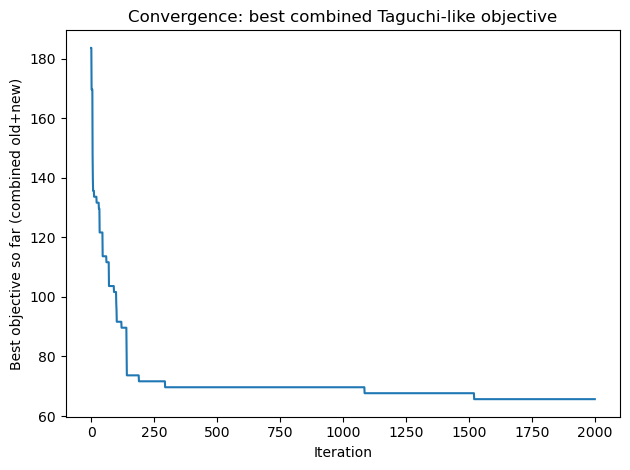

Random baseline (old fixed): 100%|██████████| 300/300 [00:13<00:00, 22.99design/s]


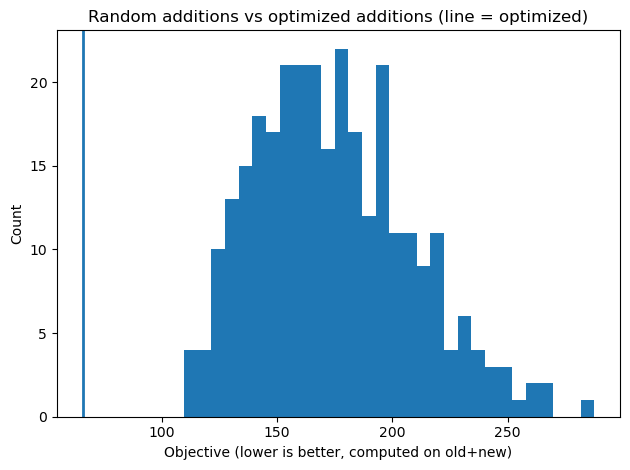

Baseline mean objective: 174.45
Baseline best objective: 109.67
Optimized objective:     65.67


,Power (W),Substrate Temp (°C),O2 Flow (sccm),Pressure (mTorr),Anneal Condition Num,Anneal Temp (°C)
0,10,25,3.0,2,2,150
1,20,25,0.3,2,2,400
2,30,25,0.3,4,1,150
3,20,25,2.0,4,1,150
4,30,25,3.0,2,1,600
5,20,25,2.0,4,1,400
6,30,400,2.0,4,2,600
7,10,400,0.3,2,1,600
8,10,400,3.0,4,2,600


In [10]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from tqdm import tqdm

FACTORS = [
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",
    "Anneal Temp (°C)",
]

# -----------------------------
# 1) Define levels for NEW candidates (edit as needed)
# -----------------------------
levels = {
    "Power (W)": [10, 20, 30],
    "Substrate Temp (°C)": [25, 400],
    "O2 Flow (sccm)": [0.3, 2.0, 3.0],
    "Pressure (mTorr)": [2, 4],
    "Anneal Condition Num": [1, 2],
    "Anneal Temp (°C)": [150, 400, 600],  # example 3 levels
}

def all_candidates(levels_dict):
    keys = list(levels_dict.keys())
    rows = list(itertools.product(*[levels_dict[k] for k in keys]))
    return pd.DataFrame(rows, columns=keys)

# Candidates for NEW experiments only (constraint applied here)
cand = all_candidates(levels)
cand = cand[cand["Substrate Temp (°C)"] < cand["Anneal Temp (°C)"]].reset_index(drop=True)

# Optional: prevent selecting exact duplicates of OLD runs (usually what you want)
def row_key(df_row):
    return tuple(df_row[f] for f in FACTORS)

old_keys = set(row_key(r) for _, r in old[FACTORS].iterrows())
cand_keys = [row_key(r) for _, r in cand.iterrows()]
cand = cand[[k not in old_keys for k in cand_keys]].reset_index(drop=True)
cand_keys = [row_key(r) for _, r in cand.iterrows()]

print("Feasible NEW candidates (excluding duplicates of old):", len(cand))

# -----------------------------
# 2) Taguchi-like pairwise balance objective on COMBINED design
# -----------------------------
def taguchi_pairwise_objective(df_all, factors):
    N = len(df_all)
    obj = 0.0
    for i in range(len(factors)):
        for j in range(i + 1, len(factors)):
            fi, fj = factors[i], factors[j]
            tab = pd.crosstab(df_all[fi], df_all[fj]).sort_index(axis=0).sort_index(axis=1)
            Li, Lj = tab.shape
            ideal = N / (Li * Lj)
            dev = tab.values - ideal
            obj += float((dev ** 2).sum())
    return obj

def random_new_set(candidates, n_add, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(candidates), size=n_add, replace=False)
    return candidates.iloc[idx].reset_index(drop=True)

# -----------------------------
# 3) Optimize NEW set using swap search, but score COMBINED = old + new
# -----------------------------
def optimize_augmentation_by_swaps(old_df, candidates, n_add, factors, n_iters=30000, seed=0, tqdm_every=200):
    rng = np.random.default_rng(seed)

    # initial new
    new_df = random_new_set(candidates, n_add, seed=seed)
    new_keys = set(row_key(r) for _, r in new_df.iterrows())

    combined = pd.concat([old_df[factors], new_df[factors]], ignore_index=True)
    cur_obj = taguchi_pairwise_objective(combined, factors)

    best_new = new_df.copy()
    best_obj = cur_obj

    hist_best = [best_obj]
    hist_cur = [cur_obj]

    pbar = tqdm(range(n_iters), desc="Augmenting (swap optimization)", unit="iter")
    for t in pbar:
        out_pos = int(rng.integers(0, n_add))
        out_key = row_key(new_df.iloc[out_pos])

        # pick candidate not already in NEW (and not duplicated with OLD due to pre-filter)
        in_idx = None
        for _ in range(50):
            j = int(rng.integers(0, len(candidates)))
            in_key = cand_keys[j]
            if in_key not in new_keys:
                in_idx = j
                break
        if in_idx is None:
            hist_best.append(best_obj)
            hist_cur.append(cur_obj)
            continue

        trial_new = new_df.copy()
        trial_new.iloc[out_pos] = candidates.iloc[in_idx]
        trial_combined = pd.concat([old_df[factors], trial_new[factors]], ignore_index=True)
        trial_obj = taguchi_pairwise_objective(trial_combined, factors)

        if trial_obj < cur_obj:
            # accept
            new_df = trial_new
            cur_obj = trial_obj
            new_keys.remove(out_key)
            new_keys.add(cand_keys[in_idx])

            if cur_obj < best_obj:
                best_obj = cur_obj
                best_new = new_df.copy()

        hist_best.append(best_obj)
        hist_cur.append(cur_obj)

        if (t % tqdm_every) == 0:
            pbar.set_postfix(cur=f"{cur_obj:.2f}", best=f"{best_obj:.2f}")

    return best_new.reset_index(drop=True), best_obj, np.array(hist_cur), np.array(hist_best)

# -----------------------------
# 4) Run augmentation
# -----------------------------
N_ADD = 9  # choose how many NEW experiments you want to add (18 is a good default)
best_new, best_obj, hist_cur, hist_best = optimize_augmentation_by_swaps(
    old, cand, N_ADD, FACTORS, n_iters=2000, seed=42
)

all_design = pd.concat([old[FACTORS], best_new[FACTORS]], ignore_index=True)

print("\nBest combined objective:", best_obj)
print("Total runs (old + new):", len(all_design))

# -----------------------------
# 5) Validation plot: compare against RANDOM additions (old fixed)
# -----------------------------
plt.figure()
plt.plot(hist_best)
plt.xlabel("Iteration")
plt.ylabel("Best objective so far (combined old+new)")
plt.title("Convergence: best combined Taguchi-like objective")
plt.tight_layout()
plt.show()

rng = np.random.default_rng(123)
n_baseline = 300
baseline = []
for _ in tqdm(range(n_baseline), desc="Random baseline (old fixed)", unit="design"):
    new0 = random_new_set(cand, N_ADD, seed=int(rng.integers(0, 1_000_000)))
    comb0 = pd.concat([old[FACTORS], new0[FACTORS]], ignore_index=True)
    baseline.append(taguchi_pairwise_objective(comb0, FACTORS))
baseline = np.array(baseline)

plt.figure()
plt.hist(baseline, bins=30)
plt.axvline(best_obj, linewidth=2)
plt.xlabel("Objective (lower is better, computed on old+new)")
plt.ylabel("Count")
plt.title("Random additions vs optimized additions (line = optimized)")
plt.tight_layout()
plt.show()

print(f"Baseline mean objective: {baseline.mean():.2f}")
print(f"Baseline best objective: {baseline.min():.2f}")
print(f"Optimized objective:     {best_obj:.2f}")

# best_new are the NEW experiments to run
best_new


In [11]:
best_new.to_excel("new_design.xlsx")

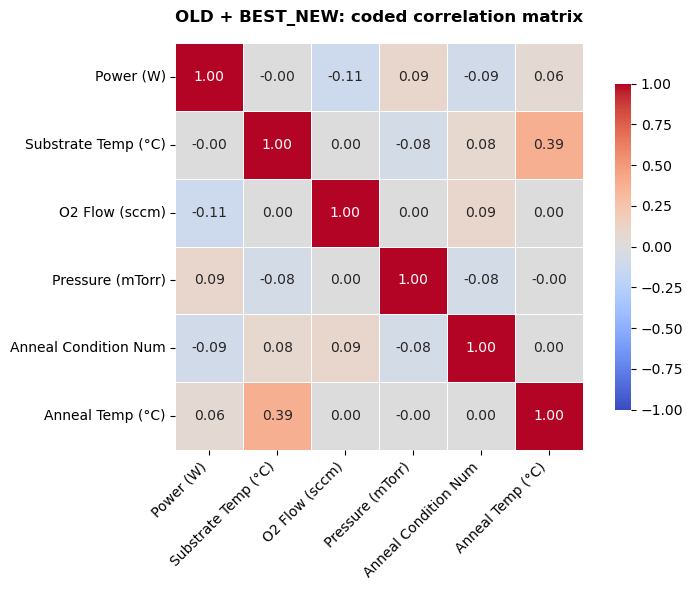

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Ensure seaborn is installed (pip install seaborn)

def code_levels(df, factors):
    """
    Code each factor to numeric values centered around 0.
    - 1 level -> 0
    - 2 levels -> [-1, +1]
    - 3 levels -> [-1, 0, +1]
    - k levels -> equally spaced in [-1, +1]
    """
    coded = pd.DataFrame(index=df.index)
    for f in factors:
        lvls = sorted(df[f].dropna().unique())
        k = len(lvls)
        if k == 0:
            coded[f] = 0.0
            continue
        if k == 1:
            mapping = {lvls[0]: 0.0}
        elif k == 2:
            mapping = {lvls[0]: -1.0, lvls[1]: +1.0}
        elif k == 3:
            mapping = {lvls[0]: -1.0, lvls[1]: 0.0, lvls[2]: +1.0}
        else:
            vals = np.linspace(-1.0, 1.0, k)
            mapping = {lv: float(v) for lv, v in zip(lvls, vals)}
        coded[f] = df[f].map(mapping).astype(float)
    return coded

def plot_corr_heatmap_improved(df, factors, title="Coded correlation matrix (orthogonality proxy)"):
    coded = code_levels(df, factors)
    # Pandas returns a DataFrame, keep it as a DataFrame for Seaborn to use the column names
    corr = coded.corr().fillna(0.0) 

    plt.figure(figsize=(8, 6)) # Adjust size as needed
    
    # Seaborn heatmap automatically handles text contrast, formatting, and colormaps
    sns.heatmap(
        corr, 
        vmin=-1, vmax=1, center=0, 
        cmap="coolwarm",       # Diverging colormap (Blue -> White -> Red)
        annot=True,            # Show numbers
        fmt=".2f",             # Format to 2 decimal places
        square=True,           # Force cells to be perfect squares
        linewidths=0.5,        # Add grid lines between cells for clarity
        cbar_kws={"shrink": 0.8} # Slightly shrink colorbar to match matrix height
    )
    
    plt.title(title, pad=15, weight='bold')
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Combine old + best_new (only factor columns)
all_design = pd.concat([old[FACTORS], best_new[FACTORS]], ignore_index=True)

# Plot correlation heatmap for the combined design
plot_corr_heatmap_improved(all_design, FACTORS, title="OLD + BEST_NEW: coded correlation matrix")

In [13]:
display(all_design)
all_design.to_excel("output/new_design.xlsx")

,Power (W),Substrate Temp (°C),O2 Flow (sccm),Pressure (mTorr),Anneal Condition Num,Anneal Temp (°C)
0,10,25,0.3,2,1,150
1,10,25,0.3,4,2,400
2,10,400,3.0,2,1,400
3,10,400,3.0,4,2,150
4,30,25,3.0,4,1,400
5,30,25,3.0,2,2,150
6,30,400,0.3,2,2,400
7,30,400,0.3,4,1,150
8,20,25,3.0,4,2,400
9,30,25,0.3,4,1,600


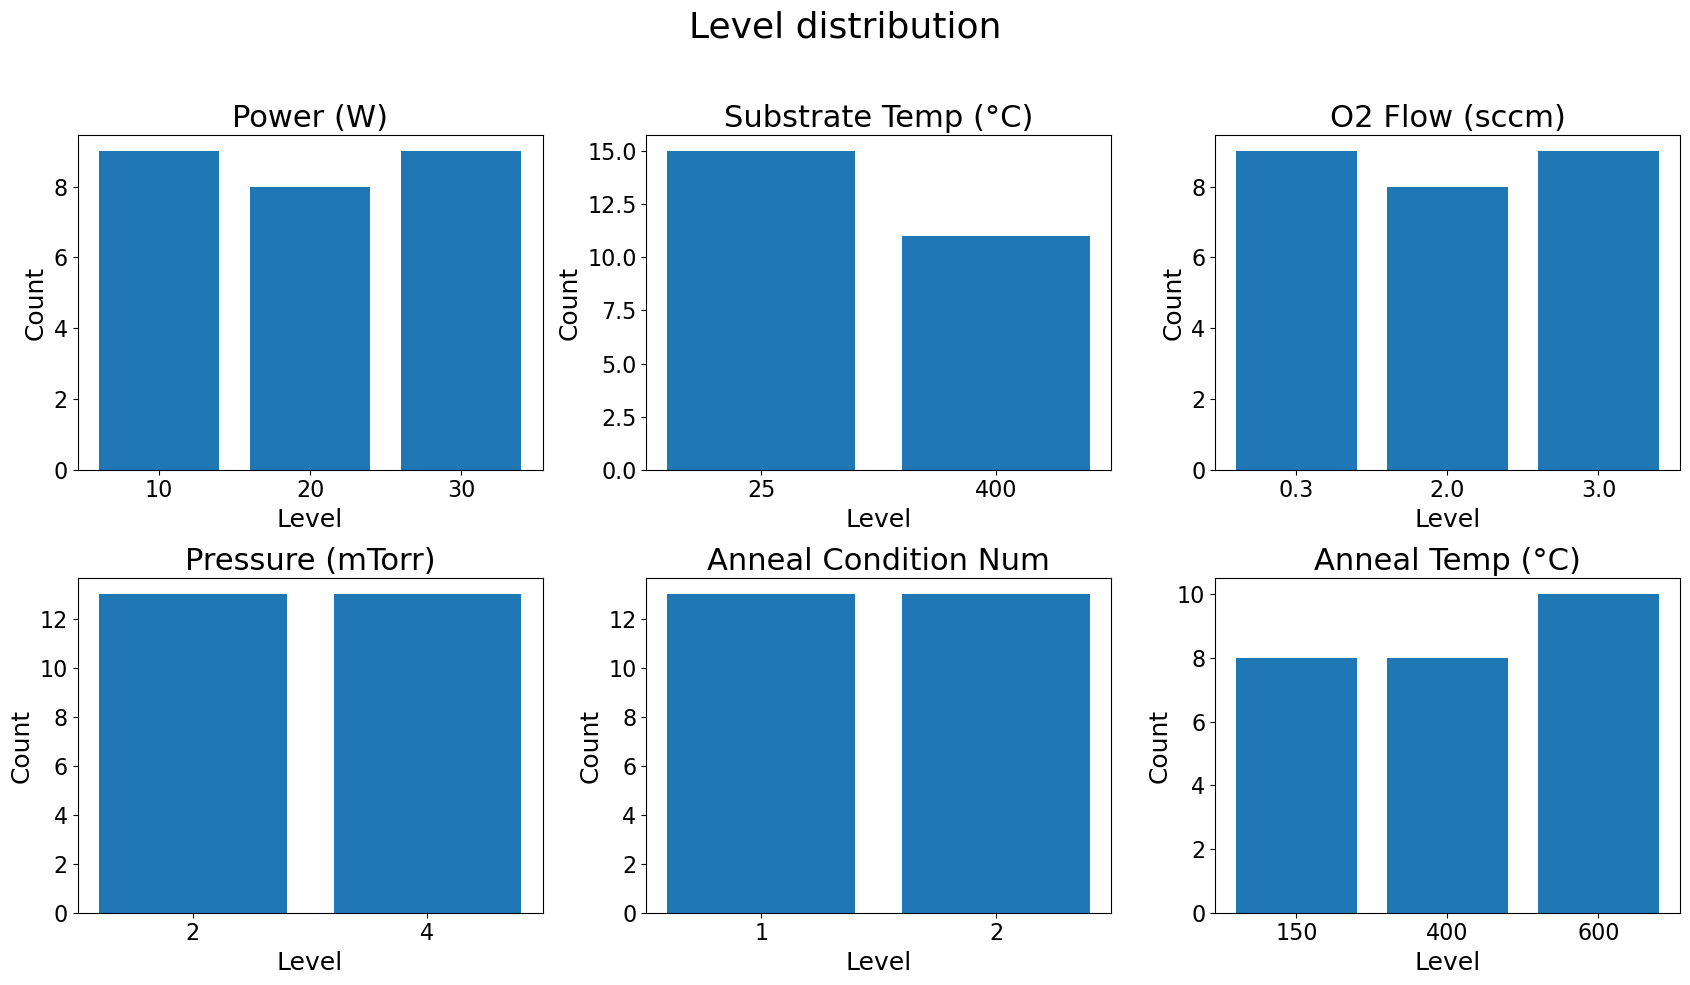

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_level_balance_grid(df, factors, title="Level distribution (combined)"):
    nrows, ncols = 2, 3  # 2x3 layout

    fig, axes = plt.subplots(nrows, ncols, figsize=(17, 10))
    axes = axes.flatten()

    for i, f in enumerate(factors):
        ax = axes[i]
        vc = df[f].value_counts().sort_index()
        ax.bar([str(x) for x in vc.index], vc.values)

        ax.set_title(f, fontsize=22)
        ax.set_ylabel("Count", fontsize=18)
        ax.set_xlabel("Level", fontsize=18)

        # make tick labels bigger
        ax.tick_params(axis="both", labelsize=16)

    # Turn off unused axes
    for j in range(i + 1, nrows * ncols):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=26)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


all_design = pd.concat([old[FACTORS], best_new[FACTORS]], ignore_index=True)

plot_level_balance_grid(
    all_design,
    FACTORS,
    title="Level distribution"
)


In [15]:
import pandas as pd

FACTORS = [
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",
    "Anneal Temp (°C)",
]

# Conventional mixed Taguchi total size
N_TOTAL = 36  # L36

# Your desired discrete levels (including your new 600°C level)
DESIRED_LEVELS = {
    "Power (W)": [10, 20, 30],
    "Substrate Temp (°C)": [25, 400],
    "O2 Flow (sccm)": [0.3, 2.0, 3.0],
    "Pressure (mTorr)": [2, 4],
    "Anneal Condition Num": [1, 2],
    "Anneal Temp (°C)": [150, 400, 600],  # <-- your choice
}

# If old has replicates in the raw file, make sure old is one row per Experiment already.
# If your `old` is already aggregated (one row per Experiment), this is fine.
old_runs = old[FACTORS].drop_duplicates().copy()

N_OLD = len(old_runs)
N_ADD_TARGET = N_TOTAL - N_OLD
print("N_OLD =", N_OLD)
print("N_TOTAL =", N_TOTAL)
print("To reach L36 total, you would add N_ADD =", N_ADD_TARGET)

# ---------- Level-balance target table ----------
rows = []
for f in FACTORS:
    levels = DESIRED_LEVELS[f]
    L = len(levels)
    target_per_level = N_TOTAL / L

    counts_old = old_runs[f].value_counts().reindex(levels, fill_value=0)

    for lvl in levels:
        cur = int(counts_old.loc[lvl])
        tgt = target_per_level
        rows.append({
            "Factor": f,
            "Level": lvl,
            "Old count": cur,
            f"Target count in N={N_TOTAL}": tgt,
            "Deficit (target - old)": tgt - cur,
        })

balance_table = pd.DataFrame(rows)
balance_table[f"Target count in N={N_TOTAL}"] = balance_table[f"Target count in N={N_TOTAL}"].round(2)
balance_table["Deficit (target - old)"] = balance_table["Deficit (target - old)"].round(2)

balance_table


N_OLD = 17
N_TOTAL = 36
To reach L36 total, you would add N_ADD = 19


,Factor,Level,Old count,Target count in N=36,Deficit (target - old)
0,Power (W),10.0,6,12.0,6.0
1,Power (W),20.0,5,12.0,7.0
2,Power (W),30.0,6,12.0,6.0
3,Substrate Temp (°C),25.0,9,18.0,9.0
4,Substrate Temp (°C),400.0,8,18.0,10.0
5,O2 Flow (sccm),0.3,6,12.0,6.0
6,O2 Flow (sccm),2.0,5,12.0,7.0
7,O2 Flow (sccm),3.0,6,12.0,6.0
8,Pressure (mTorr),2.0,9,18.0,9.0
9,Pressure (mTorr),4.0,8,18.0,10.0


How many Taguchi rows are already in OLD: 3


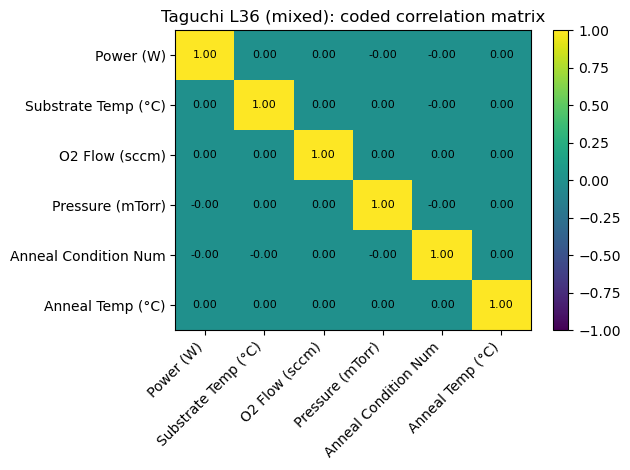

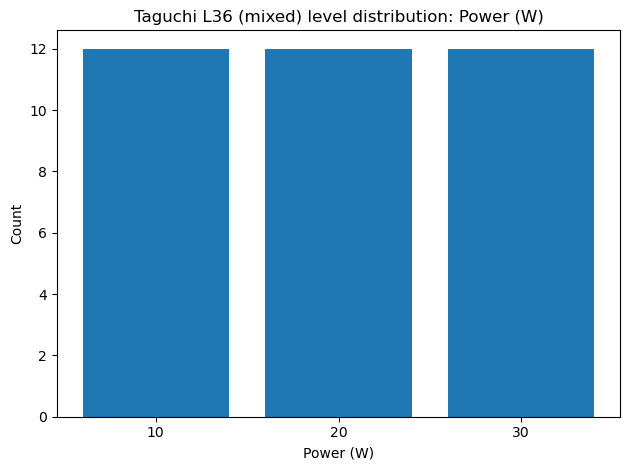

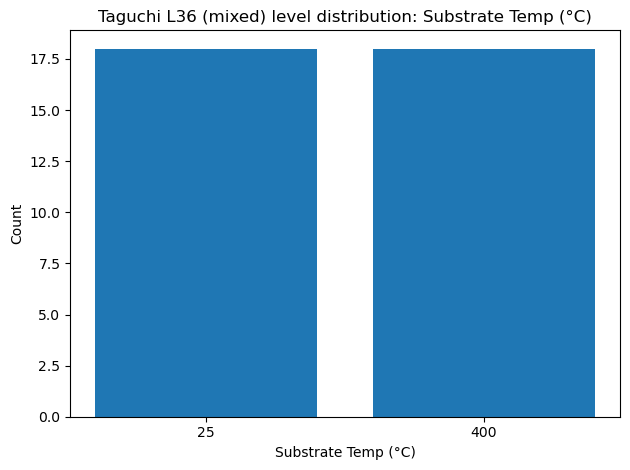

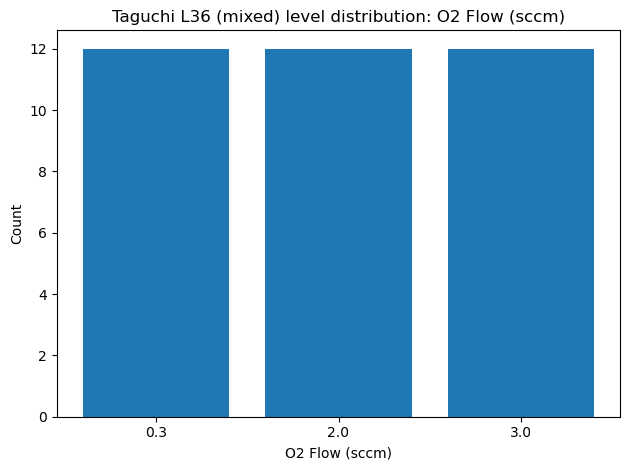

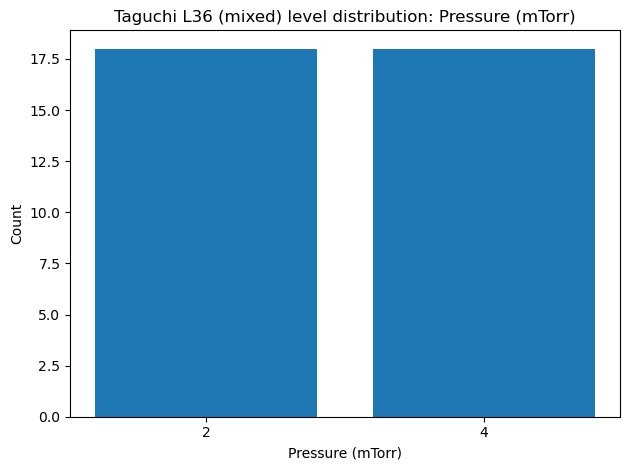

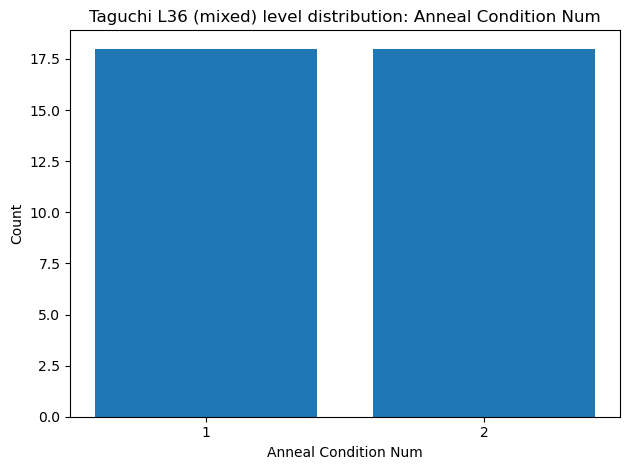

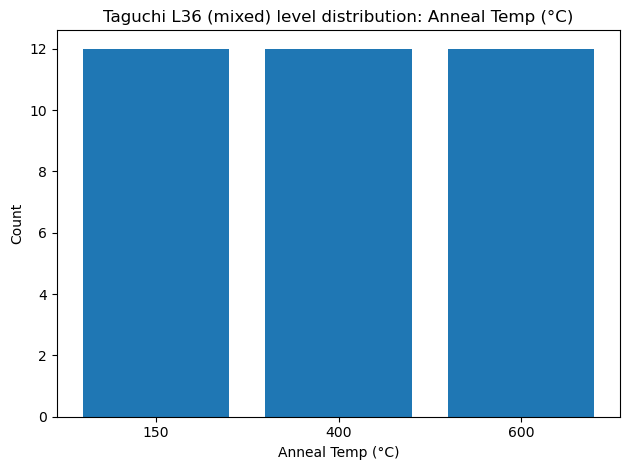

,Run,Power (W),Substrate Temp (°C),O2 Flow (sccm),Pressure (mTorr),Anneal Condition Num,Anneal Temp (°C),In OLD?
0,1,10,25,0.3,2,1,150,True
1,2,10,25,2.0,2,1,400,True
2,3,10,25,3.0,2,1,600,False
3,4,20,25,0.3,2,1,400,False
4,5,20,25,2.0,2,1,600,False
5,6,20,25,3.0,2,1,150,False
6,7,30,25,0.3,2,1,600,False
7,8,30,25,2.0,2,1,150,False
8,9,30,25,3.0,2,1,400,False
9,10,10,25,0.3,4,2,150,False


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Desired mixed-Taguchi levels
# ----------------------------
LEVELS = {
    "Power (W)": [10, 20, 30],
    "Substrate Temp (°C)": [25, 400],
    "O2 Flow (sccm)": [0.3, 2.0, 3.0],
    "Pressure (mTorr)": [2, 4],
    "Anneal Condition Num": [1, 2],
    "Anneal Temp (°C)": [150, 400, 600],
}

FACTORS = list(LEVELS.keys())

# ----------------------------
# Mixed Taguchi (36-run) table
# (this is the exact 36-run table provided earlier)
# ----------------------------
def build_mixed_taguchi_L36():
    rows = [
        (10,  25, 0.3, 2, 1, 150),
        (10,  25, 2.0, 2, 1, 400),
        (10,  25, 3.0, 2, 1, 600),
        (20,  25, 0.3, 2, 1, 400),
        (20,  25, 2.0, 2, 1, 600),
        (20,  25, 3.0, 2, 1, 150),
        (30,  25, 0.3, 2, 1, 600),
        (30,  25, 2.0, 2, 1, 150),
        (30,  25, 3.0, 2, 1, 400),

        (10,  25, 0.3, 4, 2, 150),
        (10,  25, 2.0, 4, 2, 400),
        (10,  25, 3.0, 4, 2, 600),
        (20,  25, 0.3, 4, 2, 400),
        (20,  25, 2.0, 4, 2, 600),
        (20,  25, 3.0, 4, 2, 150),
        (30,  25, 0.3, 4, 2, 600),
        (30,  25, 2.0, 4, 2, 150),
        (30,  25, 3.0, 4, 2, 400),

        (10, 400, 0.3, 2, 2, 150),
        (10, 400, 2.0, 2, 2, 400),
        (10, 400, 3.0, 2, 2, 600),
        (20, 400, 0.3, 2, 2, 400),
        (20, 400, 2.0, 2, 2, 600),
        (20, 400, 3.0, 2, 2, 150),
        (30, 400, 0.3, 2, 2, 600),
        (30, 400, 2.0, 2, 2, 150),
        (30, 400, 3.0, 2, 2, 400),

        (10, 400, 0.3, 4, 1, 150),
        (10, 400, 2.0, 4, 1, 400),
        (10, 400, 3.0, 4, 1, 600),
        (20, 400, 0.3, 4, 1, 400),
        (20, 400, 2.0, 4, 1, 600),
        (20, 400, 3.0, 4, 1, 150),
        (30, 400, 0.3, 4, 1, 600),
        (30, 400, 2.0, 4, 1, 150),
        (30, 400, 3.0, 4, 1, 400),
    ]
    df = pd.DataFrame(rows, columns=FACTORS)
    df.insert(0, "Run", np.arange(1, len(df) + 1))
    return df

taguchi36 = build_mixed_taguchi_L36()

# ----------------------------
# Helpers: coding + plots
# ----------------------------
def code_levels(df, factors, levels_map):
    coded = pd.DataFrame(index=df.index)
    for f in factors:
        lvls = levels_map[f]
        k = len(lvls)
        if k == 1:
            mapping = {lvls[0]: 0.0}
        elif k == 2:
            mapping = {lvls[0]: -1.0, lvls[1]: +1.0}
        elif k == 3:
            mapping = {lvls[0]: -1.0, lvls[1]: 0.0, lvls[2]: +1.0}
        else:
            vals = np.linspace(-1.0, 1.0, k)
            mapping = {lv: float(v) for lv, v in zip(lvls, vals)}
        coded[f] = df[f].map(mapping).astype(float)
    return coded

def plot_corr_heatmap(df, factors, levels_map, title="Coded correlation matrix"):
    coded = code_levels(df, factors, levels_map)
    corr = coded.corr().fillna(0.0).values
    labels = coded.columns.tolist()

    plt.figure()
    im = plt.imshow(corr, vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(im)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.title(title)

    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

def plot_level_balance(df, factors, title_prefix="Level distribution"):
    for f in factors:
        plt.figure()
        vc = df[f].value_counts().sort_index()
        plt.bar([str(x) for x in vc.index], vc.values)
        plt.xlabel(f)
        plt.ylabel("Count")
        plt.title(f"{title_prefix}: {f}")
        plt.tight_layout()
        plt.show()

# ----------------------------
# (Optional) Mark which Taguchi rows match OLD runs
# ----------------------------
def to_key_frame(df, factors):
    return df[factors].astype(object).apply(lambda r: tuple(r.values.tolist()), axis=1)

if "old" in globals():
    old_unique = old[FACTORS].drop_duplicates().copy()
    old_keys = set(to_key_frame(old_unique, FACTORS))
    taguchi36["In OLD?"] = to_key_frame(taguchi36, FACTORS).isin(old_keys)
    print("How many Taguchi rows are already in OLD:", int(taguchi36["In OLD?"].sum()))
else:
    print("No `old` dataframe found in globals(); skipping OLD match flag.")

# ----------------------------
# Plots for the Taguchi 36 design
# ----------------------------
plot_corr_heatmap(taguchi36, FACTORS, LEVELS, title="Taguchi L36 (mixed): coded correlation matrix")
plot_level_balance(taguchi36, FACTORS, title_prefix="Taguchi L36 (mixed) level distribution")

# If you also want to see the combined OLD + Taguchi36 distribution/corr, uncomment:
# if "old" in globals():
#     combined = pd.concat([old_unique[FACTORS], taguchi36[FACTORS]], ignore_index=True)
#     plot_corr_heatmap(combined, FACTORS, LEVELS, title="OLD + Taguchi36: coded correlation matrix")
#     plot_level_balance(combined, FACTORS, title_prefix="OLD + Taguchi36 level distribution")

taguchi36


# Leave one out

In [3]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

target = "Hall Mobility (cm^2/V·s)"

# Same process predictors you used before
process_predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
]

# -------------------------------------------------
# Build modeling dataframe with Experiment column
# -------------------------------------------------
cols_needed = ["Experiment"] + process_predictors + [target]
df_all = master_df[cols_needed].dropna().copy()

print("Number of rows used for CV:", len(df_all))
print("Experiments:", sorted(df_all["Experiment"].unique()))

# -------------------------------------------------
# Rebuild the SAME formula as in your main model
# -------------------------------------------------
main_terms = [
    "Q('Power (W)')",
    "Q('Substrate Temp (°C)')",
    "Q('O2 Flow (sccm)')",
    "Q('Pressure (mTorr)')",
    "Q('Anneal Temp (°C)')",
    # Anneal Condition only appears through interaction
]

interaction_terms = [
    "Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)')",     # Substrate Temp × O2 Flow
    "Q('Power (W)'):Q('O2 Flow (sccm)')",              # Power × O2 Flow
    "Q('Power (W)'):C(Q('Anneal Condition Num'))",     # Power × Anneal Condition (categorical)
]

rhs = " + ".join(main_terms + interaction_terms)
formula = f"Q('{target}') ~ {rhs}"
print("Formula used for CV:")
print(formula)

# -------------------------------------------------
# Leave-one-experiment-out CV
# -------------------------------------------------
results = []

for exp_id in sorted(df_all["Experiment"].unique()):
    # split train / test by experiment
    df_train = df_all[df_all["Experiment"] != exp_id]
    df_test = df_all[df_all["Experiment"] == exp_id]

    # fit on training experiments
    model_cv = smf.ols(formula=formula, data=df_train).fit()

    # predict for held-out experiment
    y_test = df_test[target]
    y_pred = model_cv.predict(df_test)

    # metrics
    mse = np.mean((y_test - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))

    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - y_test.mean()) ** 2)
    r2_test = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    results.append({
        "Held_out_experiment": exp_id,
        "n_test": len(df_test),
        "RMSE": rmse,
        "MAE": mae,
        "R2_test": r2_test,
    })

cv_df = pd.DataFrame(results)
display(cv_df)

print("\nAverage across folds:")
print(cv_df[["RMSE", "MAE", "R2_test"]].mean())


Number of rows used for CV: 23
Experiments: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Formula used for CV:
Q('Hall Mobility (cm^2/V·s)') ~ Q('Power (W)') + Q('Substrate Temp (°C)') + Q('O2 Flow (sccm)') + Q('Pressure (mTorr)') + Q('Anneal Temp (°C)') + Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)') + Q('Power (W)'):Q('O2 Flow (sccm)') + Q('Power (W)'):C(Q('Anneal Condition Num'))


,Held_out_experiment,n_test,RMSE,MAE,R2_test
0,1,3,33.776409,27.666111,-1.823912
1,2,2,27.450651,27.145000,-44.156594
2,3,3,27.184757,27.145000,-341.134734
3,4,3,27.258351,27.145000,-119.489355
4,5,3,27.163389,27.145000,-737.818387
5,6,3,27.402986,27.145000,-52.360606
6,7,3,27.256988,27.145000,-120.946819
7,8,3,27.210625,27.145000,-206.569292



Average across folds:
RMSE        28.088019
MAE         27.210139
R2_test   -203.037462
dtype: float64


# Visualization

## Noise on the data (calc coefficient of variation)

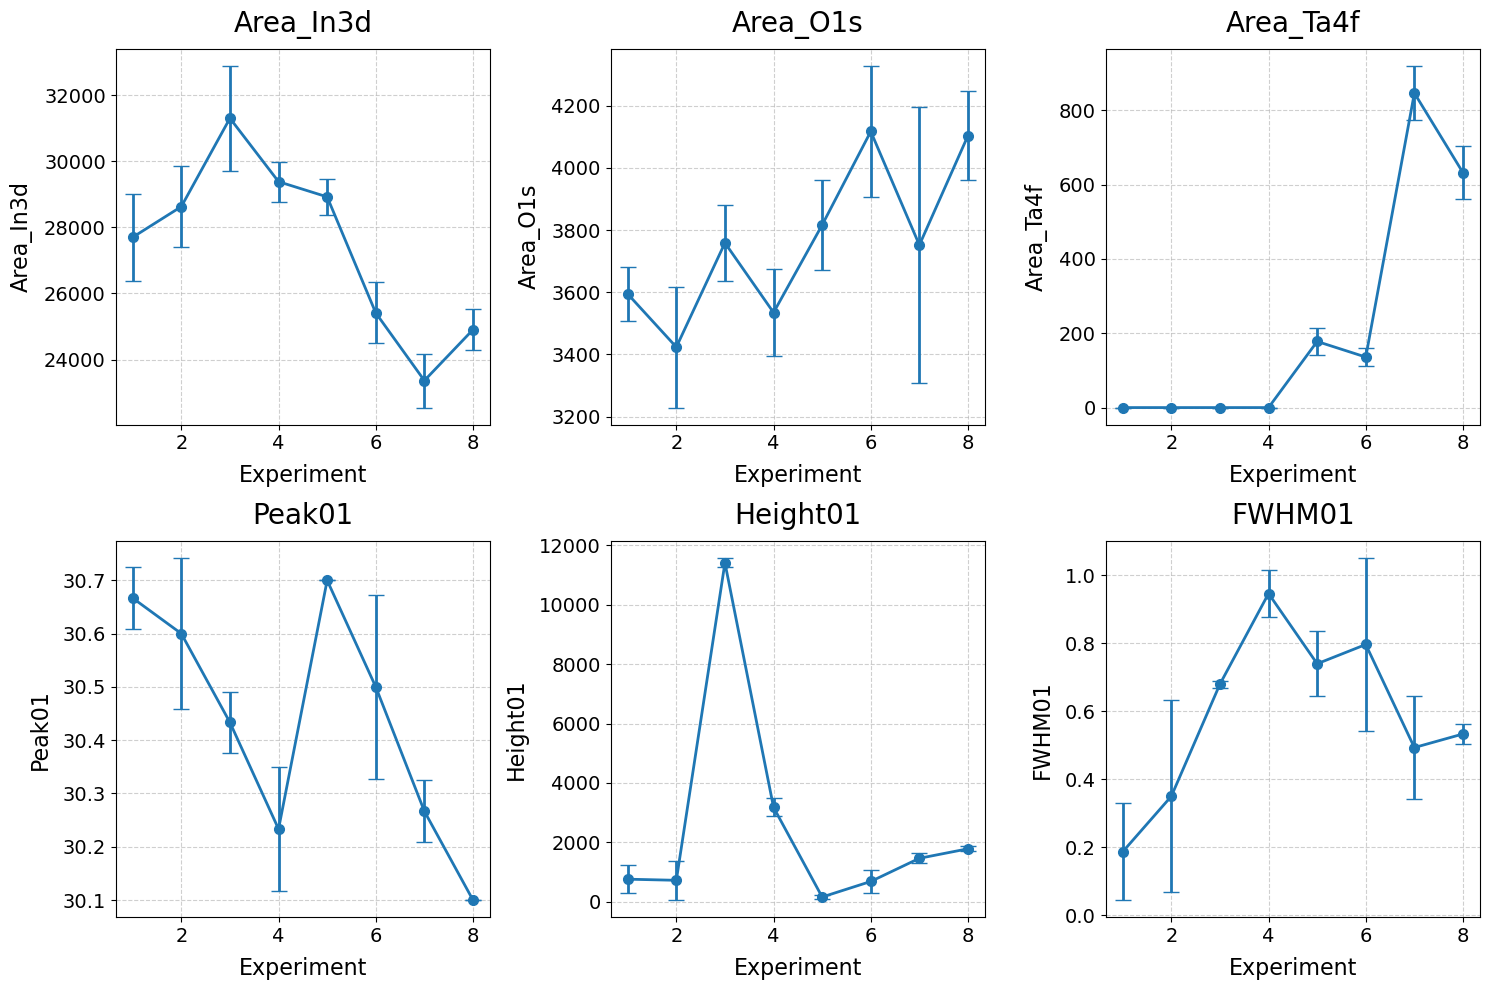

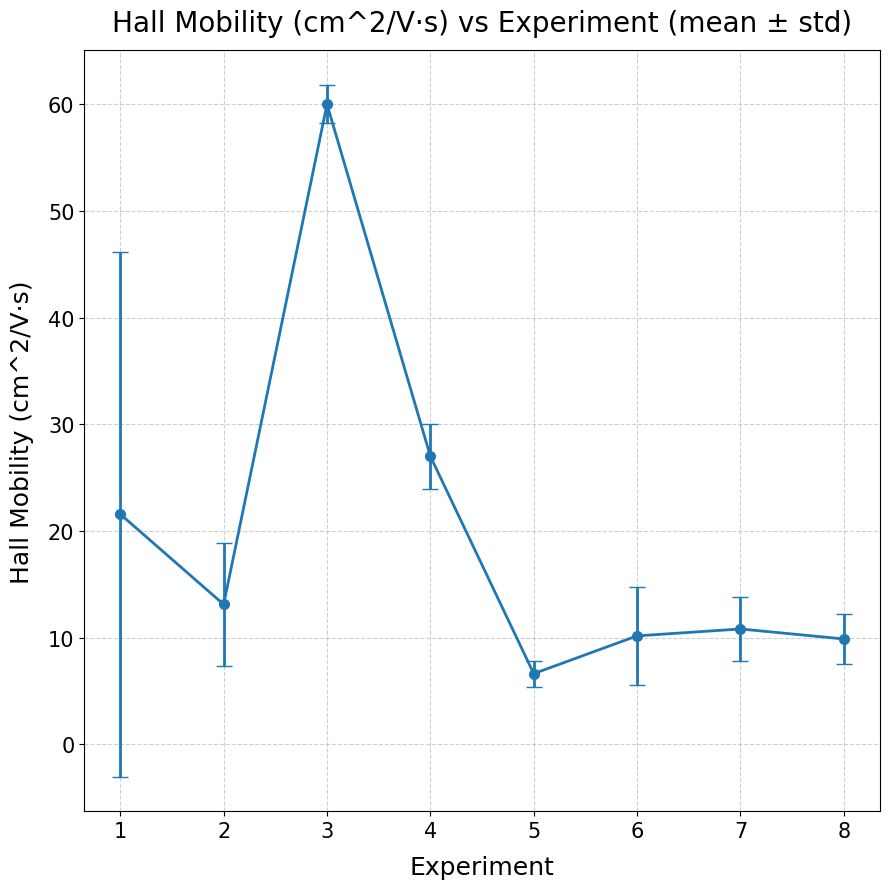

Coefficient of variation per experiment (percent):


,CV_%_Area_In3d,CV_%_Area_O1s,CV_%_Area_Ta4f,CV_%_Peak01,CV_%_Height01,CV_%_FWHM01,CV_%_Hall Mobility (cm^2/V·s)
Experiment,,,,,,,
1,4.762,2.454,nan,0.188,61.957,76.202,114.108
2,4.295,5.680,nan,0.462,92.257,80.812,44.049
3,5.074,3.237,nan,0.190,1.339,1.471,3.000
4,2.043,3.940,nan,0.382,9.652,7.190,11.264
5,1.916,3.764,20.419,0.000,34.032,12.891,18.470
6,3.639,5.132,17.890,0.568,56.718,31.862,45.191
7,3.497,11.835,8.691,0.191,11.845,30.764,27.956
8,2.481,3.469,11.211,0.000,4.629,5.728,23.420


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) columns we want to analyze
cols_to_agg = [
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Peak01",
    "Height01",
    "FWHM01",
    "Hall Mobility (cm^2/V·s)",
]

# keep only those that exist
cols_to_agg = [c for c in cols_to_agg if c in master_df.columns]

# 2) group by experiment and compute mean and std
grp_mean = master_df.groupby("Experiment")[cols_to_agg].mean(numeric_only=True)
grp_std = master_df.groupby("Experiment")[cols_to_agg].std(numeric_only=True)

# separate hall mobility if present
hall_col = "Hall Mobility (cm^2/V·s)"
has_hall = hall_col in cols_to_agg

# variables to plot in the 3x2 grid (exclude hall mobility)
grid_cols = [c for c in cols_to_agg if c != hall_col]

# 3) make a 2x3 figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, grid_cols):
    x = grp_mean.index.values
    y = grp_mean[col].values
    yerr = grp_std[col].values

    ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=6, markersize=7, linewidth=2)
    ax.set_title(col, fontsize=20, pad=12)
    ax.set_xlabel("Experiment", fontsize=16, labelpad=8)
    ax.set_ylabel(col, fontsize=16, labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)

# hide any unused axes
for i in range(len(grid_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# 3b) plot hall mobility separately
if has_hall:
    plt.figure(figsize=(9, 9))
    x = grp_mean.index.values
    y = grp_mean[hall_col].values
    yerr = grp_std[hall_col].values
    plt.errorbar(x, y, yerr=yerr, fmt="o-", capsize=6, markersize=7, linewidth=2)
    plt.title(f"{hall_col} vs Experiment (mean ± std)", fontsize=20, pad=14)
    plt.xlabel("Experiment", fontsize=18, labelpad=10)
    plt.ylabel(hall_col, fontsize=18, labelpad=10)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# 4) coefficient of variation (CV = std / mean) as PERCENT
cv_df = (grp_std / grp_mean.replace(0, np.nan)) * 100
cv_df = cv_df.add_prefix("CV_%_")

print("Coefficient of variation per experiment (percent):")
display(
    cv_df.style.format("{:.3f}").background_gradient(cmap="Blues")
)
cv_df.to_excel("output/cv_percetage.xlsx", index_label=False)


In [3]:
hall_col = "Hall Mobility (cm^2/V·s)"

# 1) Design table: one row per experiment with the knob settings
design_cols = [
    "Experiment",
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",
    "Anneal Temp (°C)",
]

design_df = (
    master_df[design_cols]
    .drop_duplicates(subset="Experiment")
    .set_index("Experiment")
)

# 2) Mean and std of Hall mobility per experiment
hall_mean = grp_mean[[hall_col]].rename(
    columns={hall_col: "Hall mobility mean (cm^2/V·s)"}
)
hall_std = grp_std[[hall_col]].rename(
    columns={hall_col: "Hall mobility std (cm^2/V·s)"}
)

# 3) Merge into a single summary table
summary = design_df.join(hall_mean).join(hall_std).reset_index()

# 4) Save to Excel
summary.to_excel("output/experiment_hall_stats.xlsx", index=False)

print(summary)


    Experiment  Power (W)  Substrate Temp (°C)  O2 Flow (sccm)  \
0            1         10                   25             0.3   
1            2         10                   25             0.3   
2            3         10                  400             3.0   
3            4         10                  400             3.0   
4            5         30                   25             3.0   
5            6         30                   25             3.0   
6            7         30                  400             0.3   
7            8         30                  400             0.3   
8            9         20                   25             3.0   
9           10         30                   25             0.3   
10          11         20                  400             2.0   
11          12         20                  400             0.3   
12          13         10                   25             2.0   
13          14         20                   25             2.0   
14        

In [4]:
# build a per-trial dataset with knobs + Hall mobility
cols = design_cols + [hall_col]   # from your code
df_trials = master_df[cols].dropna(subset=[hall_col]).copy()


## correlation matrix 

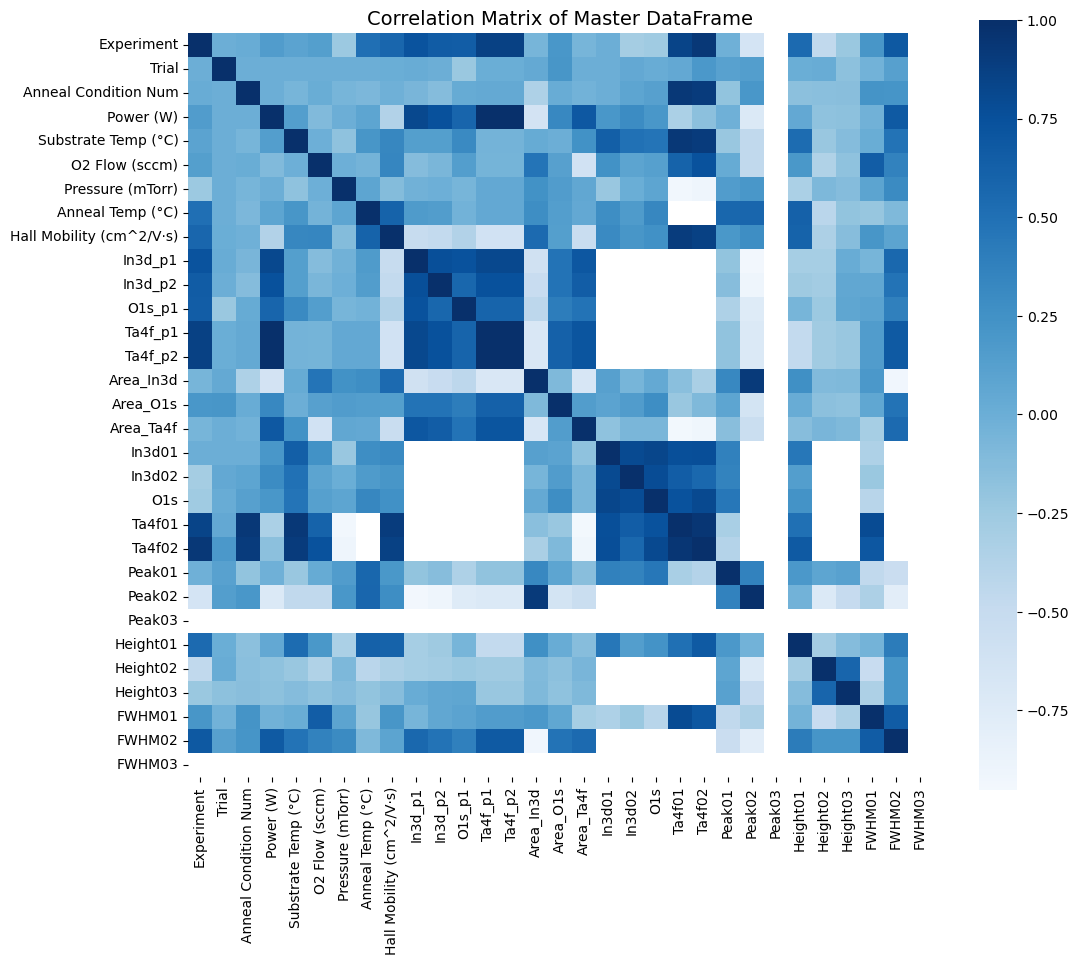

                            Experiment         Trial  Anneal Condition Num  \
Experiment                1.000000e+00  1.567374e-16          2.405626e-02   
Trial                     1.567374e-16  1.000000e+00          5.341563e-18   
Anneal Condition Num      2.405626e-02  5.341563e-18          1.000000e+00   
Power (W)                 1.572070e-01  9.647018e-17          1.121270e-16   
Substrate Temp (°C)       9.622504e-02  0.000000e+00         -5.555556e-02   
O2 Flow (sccm)            1.341852e-01  4.655484e-18          1.271023e-02   
Pressure (mTorr)         -2.405626e-01  3.204938e-17         -5.555556e-02   
Anneal Temp (°C)          5.062618e-01  6.573185e-17         -8.076445e-02   
Hall Mobility (cm^2/V·s)  5.746485e-01  2.150887e-03         -1.955583e-02   
In3d_p1                   7.318114e-01  2.245854e-02         -6.032431e-02   
In3d_p2                   6.638303e-01 -1.335720e-14         -1.343016e-01   
O1s_p1                    6.536818e-01 -2.285297e-01          2.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns from your master_df
df_corr = master_df.select_dtypes(include=["number"]).copy()

# Compute correlation matrix (Pearson by default)
corr_matrix = df_corr.corr()

# Display as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    # annot=True,       # show correlation values
    cmap="Blues",  # color palette
    center=0,
    fmt=".2f",
    square=True,
)
plt.title("Correlation Matrix of Master DataFrame", fontsize=14)
plt.show()

# Optional: save to Excel for exploration
# corr_matrix.to_excel("correlation_matrix.xlsx")
print(corr_matrix)


## Pair plots

Numeric columns used in pair plot:
['Experiment', 'Trial', 'Anneal Condition Num', 'Power (W)', 'Substrate Temp (°C)', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Hall Mobility (cm^2/V·s)', 'In3d_p1', 'In3d_p2', 'O1s_p1', 'Ta4f_p1', 'Ta4f_p2', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Peak01', 'Peak02', 'Peak03', 'Height01', 'Height02', 'Height03', 'FWHM01', 'FWHM02', 'FWHM03']


/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


<Figure size 1800x1800 with 0 Axes>

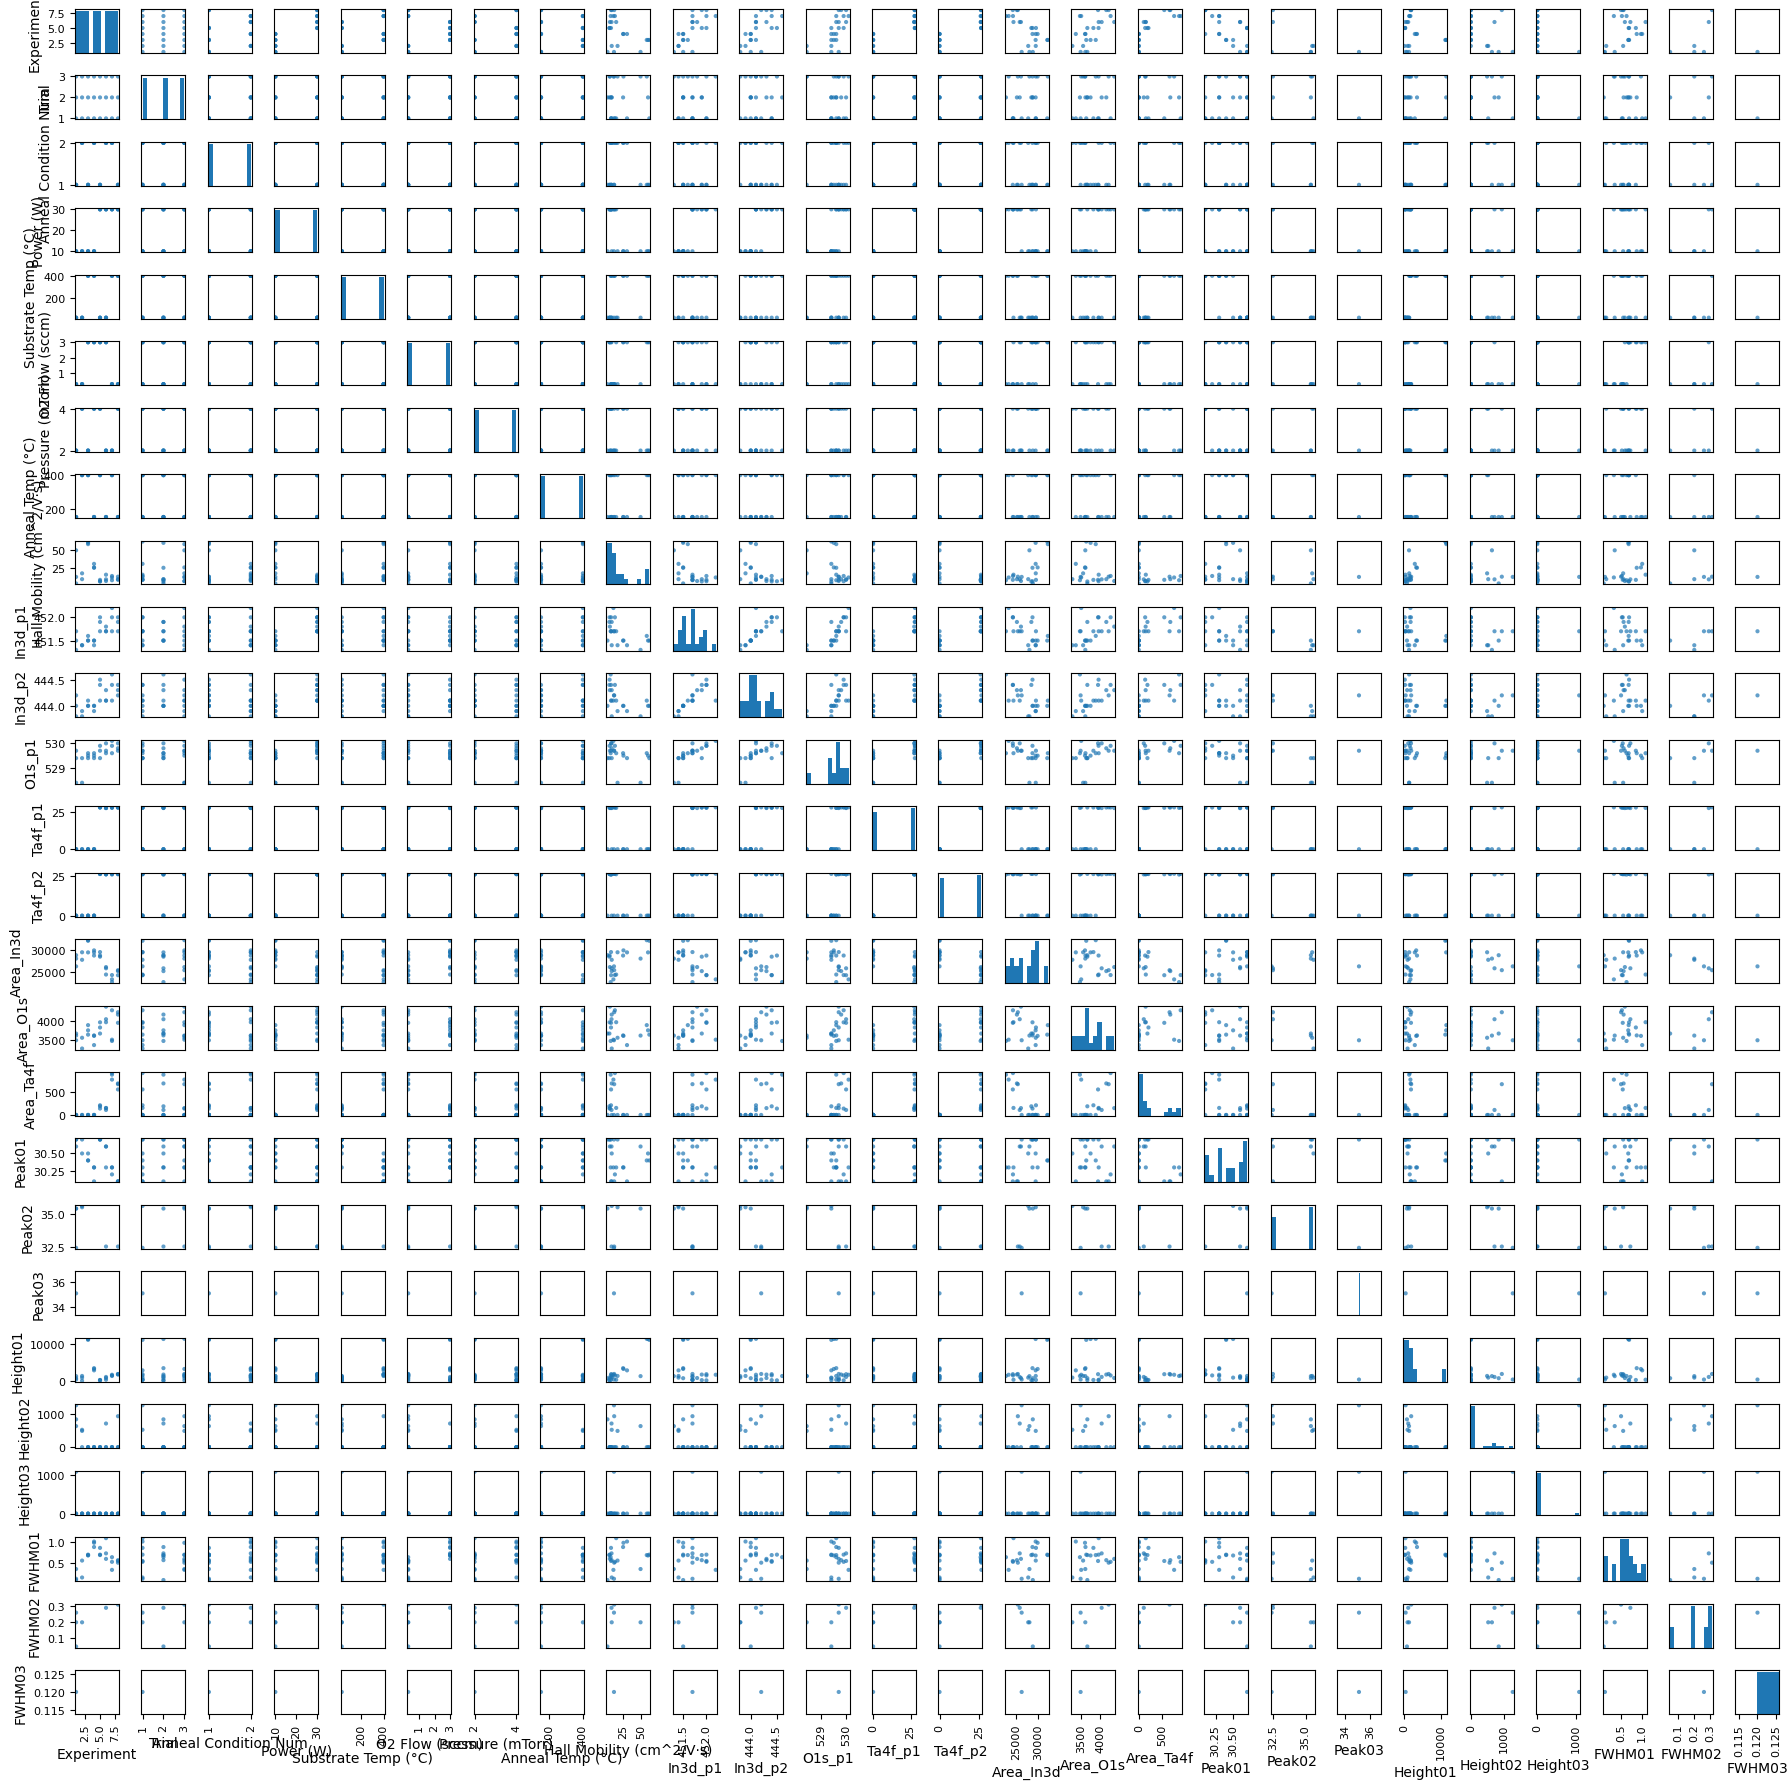

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# 1) pick only numeric columns from master_df
num_df = master_df.select_dtypes(include=[np.number]).copy()

print("Numeric columns used in pair plot:")
print(num_df.columns.tolist())

# 2) make a big scatter-matrix (pair plot)
plt.figure(figsize=(18, 18))
axes = scatter_matrix(
    num_df,
    diagonal='hist',
    alpha=0.7,
    figsize=(18, 18),
)

# make tick labels a bit smaller
for ax in axes.flatten():
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()


Columns in pair plot (in order):
['Hall Mobility (cm^2/V·s)', 'Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03']


<Figure size 3000x3000 with 0 Axes>

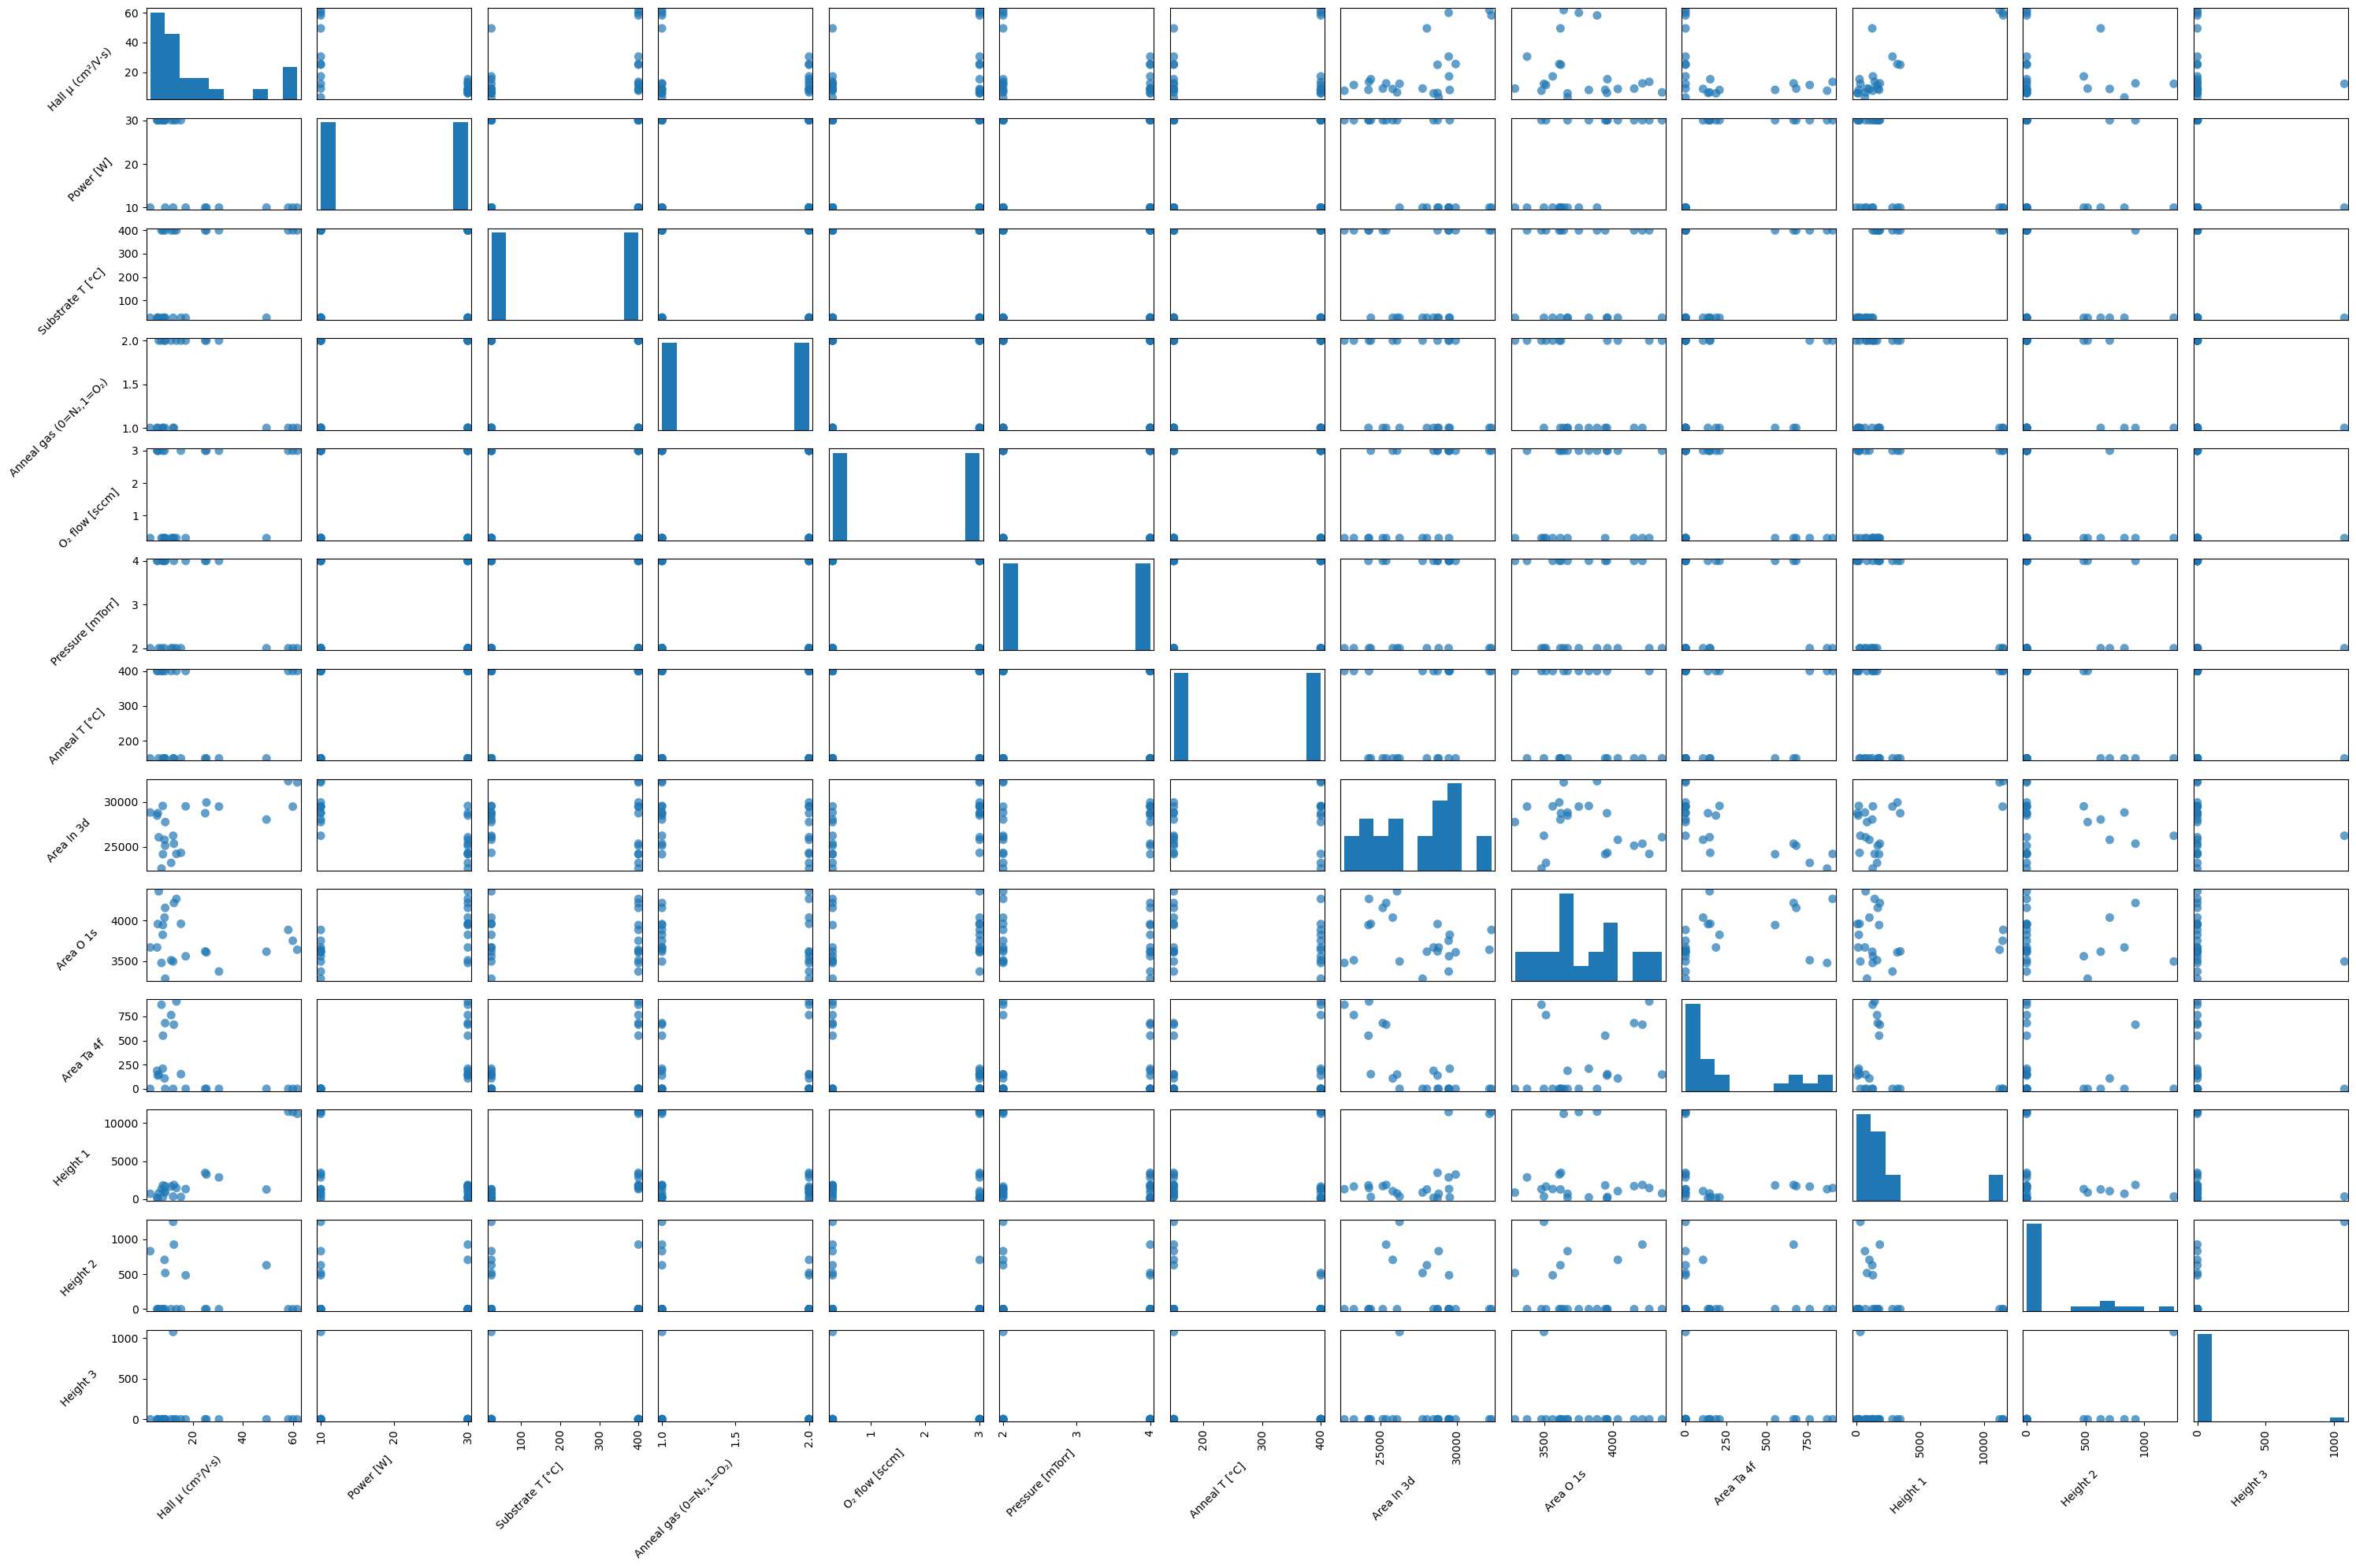

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# 1) name of your target
target_col = "Hall Mobility (cm^2/V·s)"

# 2) choose the predictors you care about (order after the target)
predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    # "In3d_p1", 
    # "In3d_p2", 
    # "O1s_p1", 
    # "Ta4f_p1", 
    # "Ta4f_p2",
    # "Peak01", 
    # "Peak02",
    # "Peak03", 
    "Height01",
    "Height02", 
    "Height03", 
    # "FWHM01", 
    # "FWHM02", 
    # "FWHM03",
]

# keep only those that actually exist in master_df
predictors = [c for c in predictors if c in master_df.columns]

# 3) put Hall mobility first, then predictors
cols_for_plot = [target_col] + predictors
df_plot = master_df[cols_for_plot].copy()

print("Columns in pair plot (in order):")
print(df_plot.columns.tolist())

# 3b) pretty labels (rename columns)
label_map = {
    "Hall Mobility (cm^2/V·s)": "Hall μ (cm²/V·s)",
    "Power (W)": "Power [W]",
    "Substrate Temp (°C)": "Substrate T [°C]",
    "Anneal Condition Num": "Anneal gas (0=N₂,1=O₂)",
    "O2 Flow (sccm)": "O₂ flow [sccm]",
    "Pressure (mTorr)": "Pressure [mTorr]",
    "Anneal Temp (°C)": "Anneal T [°C]",
    "Area_In3d": "Area In 3d",
    "Area_O1s": "Area O 1s",
    "Area_Ta4f": "Area Ta 4f",
    "Height01": "Height 1",
    "Height02": "Height 2",
    "Height03": "Height 3",
}

df_plot = df_plot.rename(columns=label_map)

# 4) make the scatter matrix
plt.figure(figsize=(30, 30))
axes = scatter_matrix(
    df_plot,
    diagonal="hist",
    alpha=0.7,
    figsize=(30, 20),
    s=250
)

show_labels = True  # set to False to hide everything

for ax in axes.flatten():
    # tick number size (leave numbers horizontal)
    ax.tick_params(axis="both", labelsize=10)
    
    if show_labels:
        # rotate X and Y AXIS LABELS (titles), not tick numbers
        xlab = ax.get_xlabel()
        ylab = ax.get_ylabel()
        ax.set_xlabel(xlab, rotation=45, ha="right", labelpad=10)
        ax.set_ylabel(ylab, rotation=45, ha="right", labelpad=10)
    else:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xlabel("")
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

### main effect

Predictors used: ['Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03']


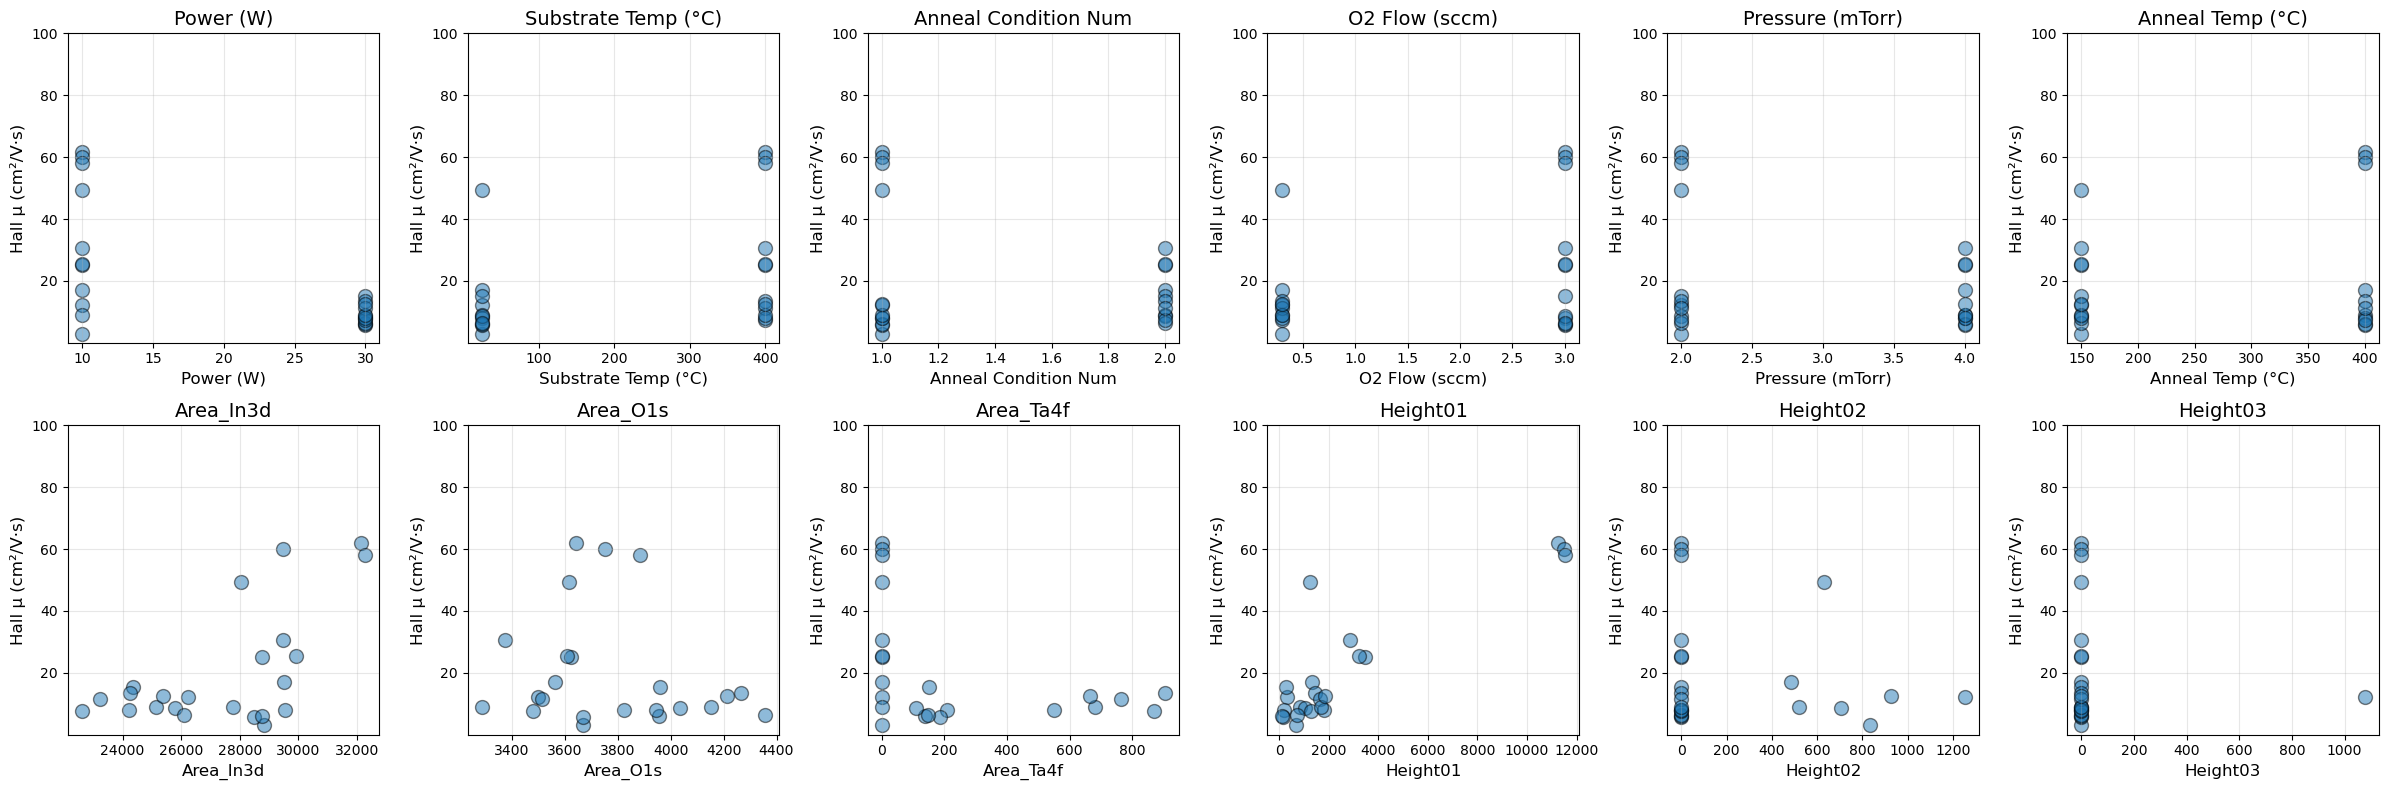

In [9]:
import numpy as np
import matplotlib.pyplot as plt

target_col = "Hall Mobility (cm^2/V·s)"

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",
    "Anneal Condition",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]

# keep only predictors that exist and are numeric
predictors = [
    c for c in predictors
    if c in master_df.columns and np.issubdtype(master_df[c].dtype, np.number)
]

print("Predictors used:", predictors)

n_rows, n_cols = 2, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 8))
axes = axes.flatten()

for ax, col in zip(axes, predictors):
    x = master_df[col].values
    y = master_df[target_col].values

    # scatter
    ax.scatter(x, y, s=100, alpha=0.5, edgecolor="k")

    # optional: simple linear fit line if enough points
    # if len(x[~np.isnan(x)]) > 2:
    #     try:
    #         coeffs = np.polyfit(x[~np.isnan(x)], y[~np.isnan(x)], 1)
    #         x_line = np.linspace(np.nanmin(x), np.nanmax(x), 50)
    #         y_line = coeffs[0] * x_line + coeffs[1]
    #         ax.plot(x_line, y_line, linewidth=2)
    #     except Exception:
    #         pass

    ax.set_title(col, fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Hall μ (cm²/V·s)", fontsize=12)
    ax.set_ylim(top=100)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(alpha=0.3)

# hide any unused axes (in case < 12 predictors)
for i in range(len(predictors), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


## Ridz Visualization

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


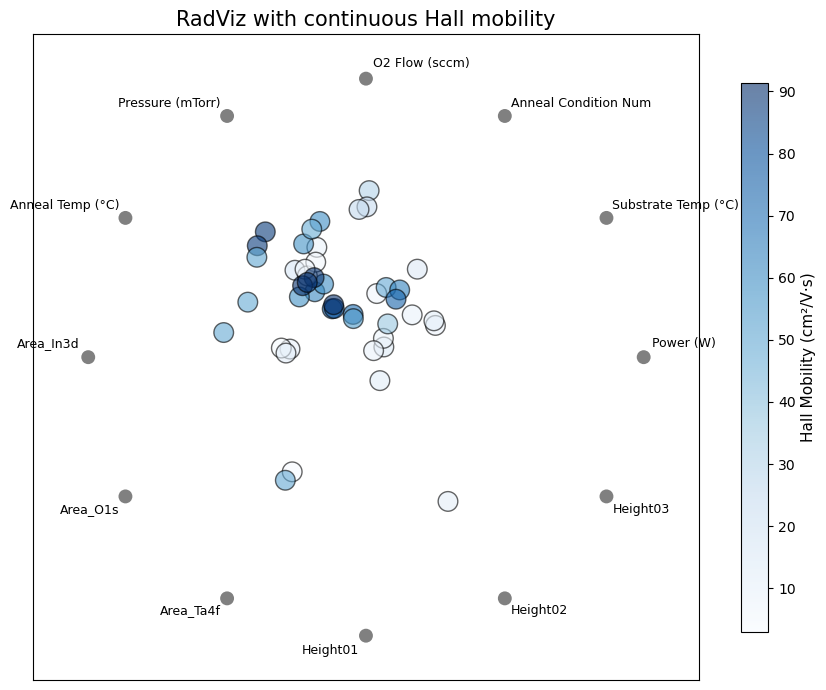

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import radviz

target_col = "Hall Mobility (cm^2/V·s)"

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]

predictors = [
    c for c in predictors
    if c in master_df.columns and np.issubdtype(master_df[c].dtype, np.number)
]

cols_for_radviz = predictors + [target_col]
df_radviz = master_df[cols_for_radviz].dropna().copy()

df_radviz["HallMobilityBin"] = pd.qcut(
    df_radviz[target_col],
    q=3,
    labels=["Low μ", "Med μ", "High μ"]
)

df_radviz_plot = df_radviz[predictors + ["HallMobilityBin"]].copy()

# jitter
np.random.seed(0)
jitter_strength = 0.02
for col in predictors:
    vals = df_radviz_plot[col].to_numpy(dtype=float)
    col_range = vals.max() - vals.min()
    if col_range == 0:
        continue
    noise = np.random.normal(0.0, jitter_strength * col_range, size=vals.shape)
    df_radviz_plot[col] = vals + noise

fig, ax = plt.subplots(figsize=(9, 7))

# 1) draw the radviz frame/anchors
radviz(df_radviz_plot, class_column="HallMobilityBin", ax=ax)

# 2) remove the legend
leg = ax.get_legend()
if leg is not None:
    leg.remove()

# 3) fade/remove the class points that pandas drew
# ax.collections are the scatter groups from radviz
for coll in ax.collections:
    coll.set_alpha(0)      # or coll.set_visible(False)

ax.set_title("RadViz with continuous Hall mobility", fontsize=15)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

# pull labels in
for txt in ax.texts:
    x, y = txt.get_position()
    r = np.sqrt(x**2 + y**2)
    if r > 0:
        new_r = 1.03
        scale = new_r / r
        txt.set_position((x * scale, y * scale))
        txt.set_fontsize(9)

# ======================================================
# overlay your own scatter with colorbar
# ======================================================
X = df_radviz_plot[predictors].to_numpy(dtype=float)

X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_range = X_max - X_min
X_range[X_range == 0] = 1.0
X_norm = (X - X_min) / X_range

n_samples, n_features = X_norm.shape
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False)
anchors = np.stack([np.cos(angles), np.sin(angles)], axis=1)

den = X_norm.sum(axis=1)
den[den == 0] = 1e-12
coords = (X_norm @ anchors) / den[:, None]

x_rv = coords[:, 0]
y_rv = coords[:, 1]

hall_vals = df_radviz[target_col].to_numpy(dtype=float)

sc = ax.scatter(
    x_rv,
    y_rv,
    c=hall_vals,
    cmap="Blues",
    s=200,
    alpha=0.6,
    edgecolor="k",
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Hall Mobility (cm²/V·s)", fontsize=11)

plt.tight_layout()
plt.show()


# Linear Regression Model (preliminar)

## Model including all predictors (preliminar)

Formula used:
Q('Hall Mobility (cm^2/V·s)') ~ Q('Power (W)') + Q('Substrate Temp (°C)') + Q('Anneal Condition Num') + Q('O2 Flow (sccm)') + Q('Pressure (mTorr)') + Q('Anneal Temp (°C)')
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.721
Model:                                       OLS   Adj. R-squared:                  0.678
Method:                            Least Squares   F-statistic:                     16.82
Date:                           Thu, 12 Feb 2026   Prob (F-statistic):           1.81e-09
Time:                                   12:11:59   Log-Likelihood:                -192.57
No. Observations:                             46   AIC:                             399.1
Df Residuals:                                 39   BIC:                             411.9
Df Model:                                      6                                         
Cova

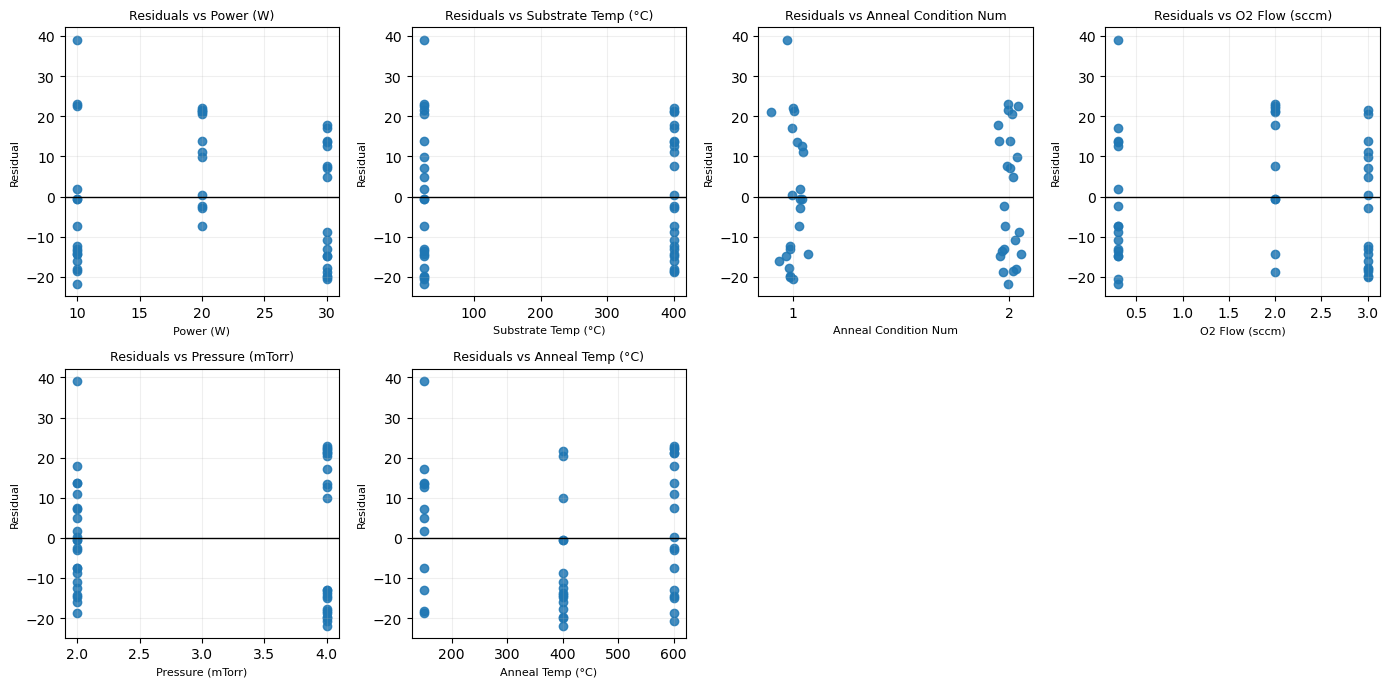

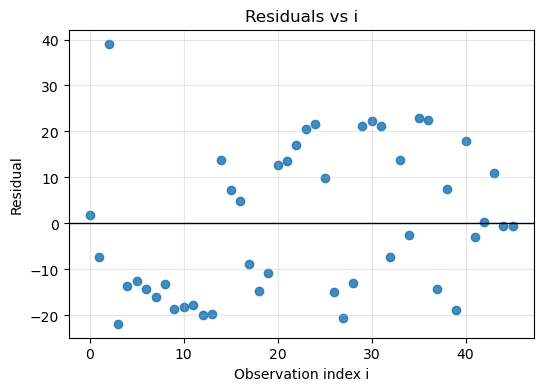

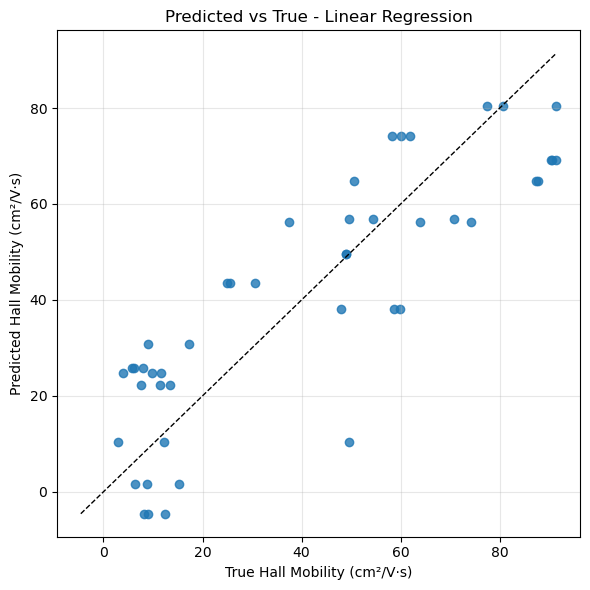

In [8]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# If you still have A, B, C, D, E, F from earlier Taguchi code, uncomment and run once:
# del A, B, C, D, E, F

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    #"Anneal Condition",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]
target = "Hall Mobility (cm^2/V·s)"

# ----------------------------------
# Choose predictors to exclude
# ----------------------------------
# Put any names from `predictors` here to remove them from the model
exclude_for_model = {
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
    #"Anneal Condition Num",
}

# drop rows with missing data in any of these
df_use = master_df[predictors + [target]].dropna()

# ----------------------------------
# Build formula programmatically
# ----------------------------------
terms = []
for col in predictors:
    if col in exclude_for_model:
        continue

    if col == "Anneal Condition":
        # categorical
        terms.append("C(Q('Anneal Condition'))")
    else:
        terms.append(f"Q('{col}')")

rhs = " + ".join(terms)
formula = f"Q('{target}') ~ {rhs}"

print("Formula used:")
print(formula)

model = smf.ols(formula=formula, data=df_use).fit()
print(model.summary())

# =========================
# Residual plots per predictor
# =========================

resid = model.resid

# If you want residuals for all predictors (even excluded) use:
# pred_cols = predictors
# If you want residuals only for predictors included in the model, use:
pred_cols = [col for col in predictors if col not in exclude_for_model]

n = len(pred_cols)
n_rows = 3
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, pred_cols):
    x = df_use[col].values
    y = resid.values

    if col == "Anneal Condition Num":
        # jitter for categorical
        x_plot = x.astype(float) + np.random.normal(0, 0.03, size=len(x))
        ax.scatter(x_plot, y, alpha=0.85)
        ax.set_xticks(sorted(np.unique(x)))
    else:
        ax.scatter(x, y, alpha=0.85)

    ax.axhline(0, color="k", linewidth=1)
    ax.set_title(f"Residuals vs {col}", fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Residual", fontsize=8)
    ax.grid(alpha=0.2)

# hide unused axes if any
for i in range(len(pred_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# =========================
# Residuals vs index (like the slide)
# =========================
plt.figure(figsize=(6, 4))
plt.scatter(np.arange(len(resid)), resid, alpha=0.85)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Observation index i")
plt.ylabel("Residual")
plt.title("Residuals vs i")
plt.grid(alpha=0.3)
plt.show()

summary = model.summary2()

# Extract main tables
coef_table = summary.tables[1]    # coefficients table
info_table = summary.tables[0]    # model info (R^2, etc.)

# Save them into Excel (different sheets)
with pd.ExcelWriter("output/ols_model_summary.xlsx") as writer:
    info_table.to_excel(writer, sheet_name="Model_Info")
    coef_table.to_excel(writer, sheet_name="Coefficients")


################################
# Get true and predicted
################################

y_true = df_use[target].values               # true Hall Mobility
y_pred = model.fittedvalues.values           # or model.predict(df_use)
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.8)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1)
plt.xlabel("True Hall Mobility (cm²/V·s)")
plt.ylabel("Predicted Hall Mobility (cm²/V·s)")
plt.title("Predicted vs True - Linear Regression")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [11]:
# print(model.params.index)
# print(sorted(df_use["Anneal Condition Num"].unique()))


In [9]:
from statsmodels.stats.anova import anova_lm

# =========================
# ANOVA table (Type II) + clean names
# =========================

def clean_term_name(term: str) -> str:
    """
    Remove patsy's Q(...) and C(Q(...)) wrappers,
    keeping the original variable name (with units).
    """
    # e.g. "Q('Power (W)')" -> "Power (W)"
    if term.startswith("Q('") and term.endswith("')"):
        return term[3:-2]

    # e.g. "C(Q('Anneal Condition Num'))" -> "Anneal Condition Num"
    if term.startswith("C(Q('") and term.endswith("'))"):
        return term[5:-3]

    # leave anything else as is (e.g. "Residual")
    return term

anova_table = anova_lm(model, typ=2)

# apply cleaning to the index (row names)
anova_table.index = [clean_term_name(t) for t in anova_table.index]

print("\n=== ANOVA table (Type II, cleaned names) ===")
print(anova_table)
anova_table.to_excel("output/anova_test.xlsx")



=== ANOVA table (Type II, cleaned names) ===
                            sum_sq    df          F        PR(>F)
Power (W)              6666.774275   1.0  22.308242  2.987830e-05
Substrate Temp (°C)    2903.584421   1.0   9.715923  3.423321e-03
Anneal Condition Num     41.772205   1.0   0.139777  7.105273e-01
O2 Flow (sccm)         4027.687936   1.0  13.477378  7.218141e-04
Pressure (mTorr)        110.170680   1.0   0.368651  5.472594e-01
Anneal Temp (°C)      14848.417817   1.0  49.685513  1.836964e-08
Residual              11655.073389  39.0        NaN           NaN


## manually selected model with only significant factors

Formula used:
Q('Hall Mobility (cm^2/V·s)') ~ Q('Power (W)') + Q('Substrate Temp (°C)') + Q('O2 Flow (sccm)') + Q('Pressure (mTorr)') + Q('Anneal Temp (°C)') + Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)') + Q('Power (W)'):Q('O2 Flow (sccm)') + Q('Power (W)'):C(Q('Anneal Condition Num'))
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.755
Model:                                       OLS   Adj. R-squared:                  0.702
Method:                            Least Squares   F-statistic:                     14.23
Date:                           Thu, 12 Feb 2026   Prob (F-statistic):           3.33e-09
Time:                                   12:07:31   Log-Likelihood:                -189.63
No. Observations:                             46   AIC:                             397.3
Df Residuals:                                 37   BIC:                           

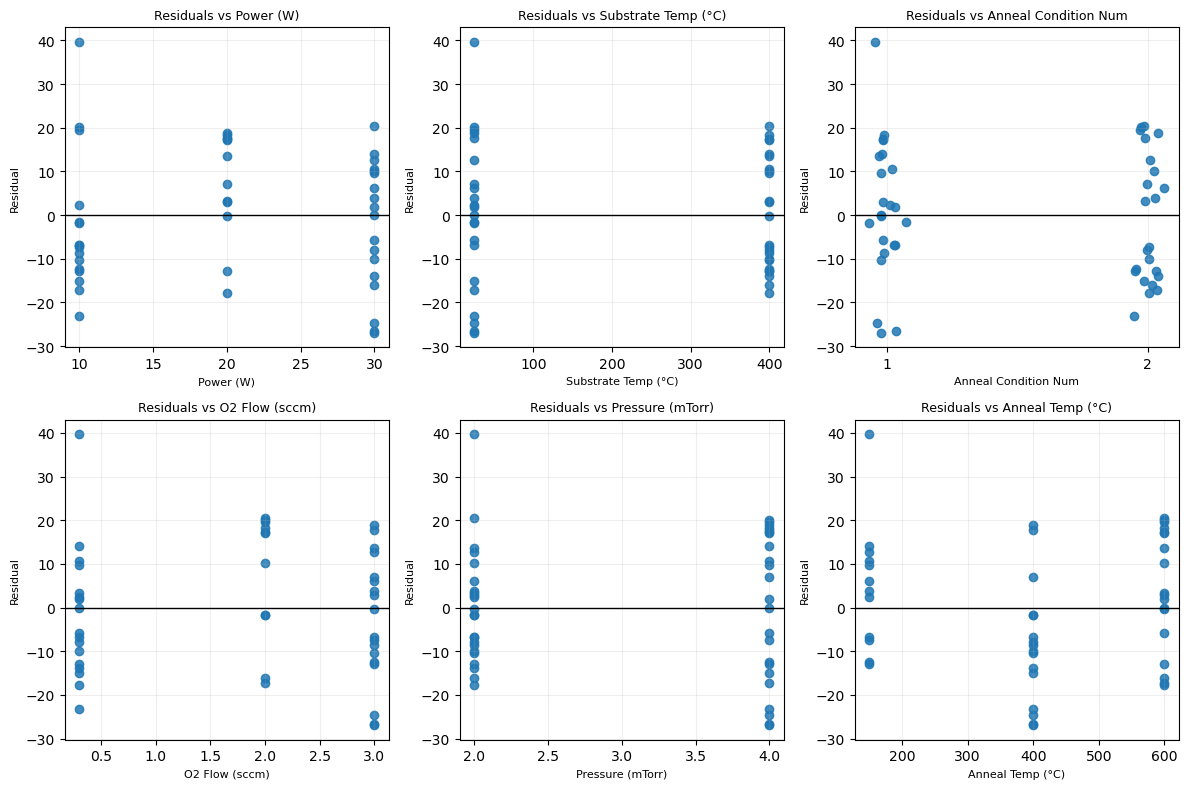

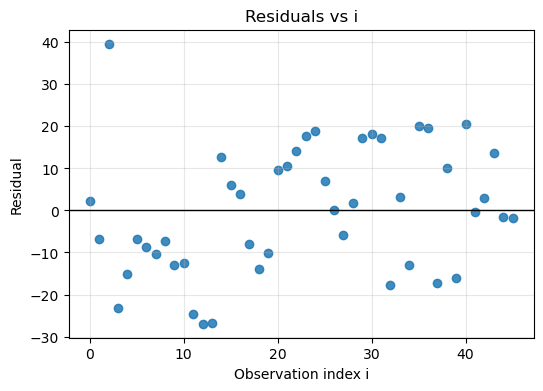

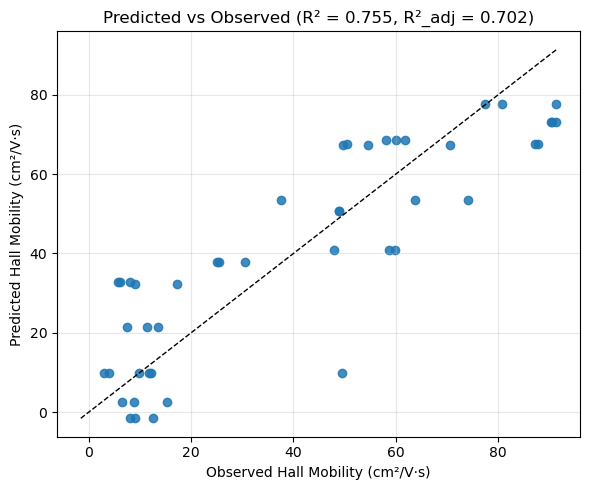

In [19]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
#del A, B, C, D, E, F    

target = "Hall Mobility (cm^2/V·s)"

# ----------------------------------
# Process predictors used in ANOVA
# ----------------------------------
process_predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
]

# Data subset: only these columns for now
df_use = master_df[process_predictors + [target]].dropna()

# ----------------------------------
# Build formula with:
#   - all main effects
#   - only selected interaction terms
# ----------------------------------

# main effects
main_terms = [
    "Q('Power (W)')",
    "Q('Substrate Temp (°C)')",
    "Q('O2 Flow (sccm)')",
    "Q('Pressure (mTorr)')",
    "Q('Anneal Temp (°C)')",
    #"C(Q('Anneal Condition Num'))",   # categorical
]

# interaction terms you highlighted in the ANOVA
interaction_terms = [
    # Substrate Temp × O2 Flow
    "Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)')",

    # Power × O2 Flow
    "Q('Power (W)'):Q('O2 Flow (sccm)')",

    # Power × Anneal Condition Num (categorical)
    "Q('Power (W)'):C(Q('Anneal Condition Num'))",
]


rhs = " + ".join(main_terms + interaction_terms)
formula = f"Q('{target}') ~ {rhs}"

print("Formula used:")
print(formula)

model = smf.ols(formula=formula, data=df_use).fit()
print(model.summary())

# =========================
# Residual plots per predictor (main effects only)
# =========================
resid = model.resid
pred_cols = process_predictors  # only the six process factors

n = len(pred_cols)
n_rows = 2
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, pred_cols):
    x = df_use[col].values
    y = resid.values

    if col == "Anneal Condition Num":
        # jitter for categorical
        x_plot = x.astype(float) + np.random.normal(0, 0.03, size=len(x))
        ax.scatter(x_plot, y, alpha=0.85)
        ax.set_xticks(sorted(np.unique(x)))
    else:
        ax.scatter(x, y, alpha=0.85)

    ax.axhline(0, color="k", linewidth=1)
    ax.set_title(f"Residuals vs {col}", fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Residual", fontsize=8)
    ax.grid(alpha=0.2)

# hide unused axes if any
for i in range(len(pred_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# =========================
# Residuals vs index
# =========================
plt.figure(figsize=(6, 4))
plt.scatter(np.arange(len(resid)), resid, alpha=0.85)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Observation index i")
plt.ylabel("Residual")
plt.title("Residuals vs i")
plt.grid(alpha=0.3)
plt.show()

# =========================
# Predicted vs observed plot
# =========================
y_true = df_use[target]
y_pred = model.fittedvalues

plt.figure(figsize=(6, 5))
plt.scatter(y_true, y_pred, alpha=0.85)
plt.xlabel("Observed Hall Mobility (cm²/V·s)")
plt.ylabel("Predicted Hall Mobility (cm²/V·s)")
plt.title("Predicted vs Observed")
r2 = model.rsquared
r2_adj = model.rsquared_adj
plt.title(f"Predicted vs Observed (R² = {r2:.3f}, R²_adj = {r2_adj:.3f})")

# 45-degree reference line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# Interaction terms and anova

In here I am including the main effects (6) and the interaction terms giving a total of 21 coefficients

In [14]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
]
target = "Hall Mobility (cm^2/V·s)"

df_use = master_df[predictors + [target]].dropna()

# -------------------------
# Build formula with ALL 2-way interactions
# -------------------------
rhs = (
    "Q('Power (W)')"
    " + Q('Substrate Temp (°C)')"
    " + C(Q('Anneal Condition Num'))"
    " + Q('O2 Flow (sccm)')"
    " + Q('Pressure (mTorr)')"
    " + Q('Anneal Temp (°C)')"
)

# ** 2 means: include all main effects and all 2-way interactions
formula = f"Q('Hall Mobility (cm^2/V·s)') ~ ({rhs}) ** 2"
print("Formula:", formula)

# -------------------------
# Fit model
# -------------------------
model = smf.ols(formula=formula, data=df_use).fit()
print(model.summary())

# -------------------------
# ANOVA (Type II) with cleaned names
# -------------------------
def _clean_single(term: str) -> str:
    term = term.strip()
    if term.startswith("Q('") and term.endswith("')"):
        return term[3:-2]      # drop Q('  ')
    if term.startswith("C(Q('") and term.endswith("'))"):
        return term[5:-3]      # drop C(Q('  '))
    return term

def clean_term_name(term: str) -> str:
    # Handle interactions like "Q('Power (W)'):Q('Substrate Temp (°C)')"
    if ":" in term:
        parts = term.split(":")
        clean_parts = [_clean_single(p) for p in parts]
        return " × ".join(clean_parts)  # nicer symbol for interaction
    else:
        return _clean_single(term)

anova_table = anova_lm(model, typ=2)
anova_table.index = [clean_term_name(t) for t in anova_table.index]

print("\n=== ANOVA table (Type II, with all 2-way interactions, cleaned names) ===")
print(anova_table)

# If you want to export:
anova_table.to_excel("output/anova_all_2way_interactions.xlsx")


Formula: Q('Hall Mobility (cm^2/V·s)') ~ (Q('Power (W)') + Q('Substrate Temp (°C)') + C(Q('Anneal Condition Num')) + Q('O2 Flow (sccm)') + Q('Pressure (mTorr)') + Q('Anneal Temp (°C)')) ** 2
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.918
Model:                                       OLS   Adj. R-squared:                  0.877
Method:                            Least Squares   F-statistic:                     22.31
Date:                           Thu, 12 Feb 2026   Prob (F-statistic):           3.09e-12
Time:                                   12:06:26   Log-Likelihood:                -164.50
No. Observations:                             46   AIC:                             361.0
Df Residuals:                                 30   BIC:                             390.3
Df Model:                                     15                                         

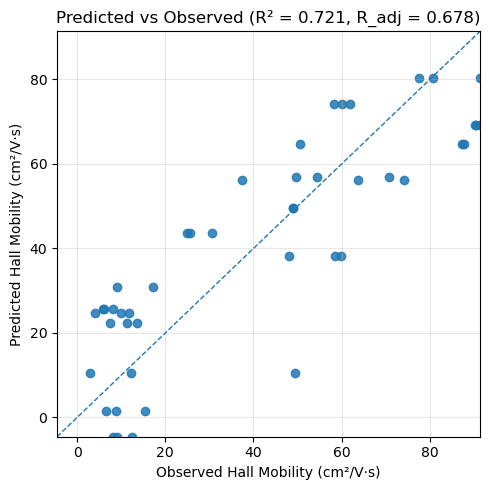

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pred_vs_observed(model, df, target_col, title_prefix="Predicted vs Observed"):
    """
    Scatter plot of predicted vs observed values for a fitted statsmodels OLS model.

    Parameters
    ----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Fitted OLS model (result of smf.ols(...).fit()).
    df : pandas.DataFrame
        Data used for prediction (can be training data or new data).
    target_col : str
        Name of the column in df that contains the true response values.
    title_prefix : str, optional
        Text to put at the beginning of the plot title.
    """
    # True values and predictions
    y_true = df[target_col]
    y_pred = model.predict(df)

    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.85)

    # 45-degree reference line
    lims = [
        np.nanmin([y_true.min(), y_pred.min()]),
        np.nanmax([y_true.max(), y_pred.max()])
    ]
    plt.plot(lims, lims, linestyle="--", linewidth=1)
    plt.xlim(lims)
    plt.ylim(lims)

    # Handle R^2 if available (for new-data predictions it is still the training R^2)
    try:
        r2 = model.rsquared
        r2_adj = model.rsquared_adj
        title = f"{title_prefix} (R² = {r2:.3f}, R_adj = {r2_adj:.3f})"
    except AttributeError:
        title = title_prefix

    plt.xlabel("Observed Hall Mobility (cm²/V·s)")
    plt.ylabel("Predicted Hall Mobility (cm²/V·s)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_pred_vs_observed(model, df_use, target_col=target)

## Calculating cooks distance for outlier point

In [11]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import OLSInfluence

infl = OLSInfluence(model)

h = infl.hat_matrix_diag                    # leverage h_ii
r_std = infl.resid_studentized_internal     # standardized residuals r_i
r_ = infl.resid
p_eff = int(model.df_model) + 1             # effective #params incl. intercept

# manual Cook's D using standardized residuals
cooks_manual = (r_std**2 * h) / (p_eff * (1.0 - h))

# statsmodels Cook's D for comparison
cooks_sm, _ = infl.cooks_distance

X = model.model.exog
resid = model.resid
h = infl.hat_matrix_diag

n = len(resid)
p_eff = int(model.df_model) + 1          # same as above
df_resid = model.df_resid               # effective residual df
MSE = np.sum(resid**2) / df_resid       # > 0

cooks_manual2 = (resid**2 / (p_eff * MSE)) * (h / (1.0 - h)**2)


compare = pd.DataFrame({
    "cooks_manual": cooks_manual,
    "cooks_statsmodels": cooks_sm,
})
print(compare)


    cooks_manual  cooks_statsmodels
0       0.000496           0.000496
1       0.008542           0.008542
2       0.238397           0.238397
3       0.050255           0.050255
5       0.019646           0.019646
6       0.013285           0.013285
7       0.017409           0.017409
8       0.022089           0.022089
9       0.027838           0.027838
10      0.056176           0.056176
11      0.053193           0.053193
12      0.028872           0.028872
13      0.036656           0.036656
14      0.035600           0.035600
15      0.030153           0.030153
16      0.008291           0.008291
17      0.003814           0.003814
18      0.006091           0.006091
19      0.017185           0.017185
20      0.009358           0.009358
21      0.026469           0.026469
22      0.030219           0.030219
23      0.047813           0.047813
24      0.025384           0.025384
25      0.028447           0.028447
26      0.005904           0.005904
27      0.024165           0

4/n cutoff for Cook's distance: 0.0870

Points with Cook's D > 4/n:
   idx  leverage  std_resid   cooks_d
2    2  0.205897   2.536955  0.238397


/tmp/ipykernel_1706600/3475557036.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for region, grp in diag.groupby("region"):


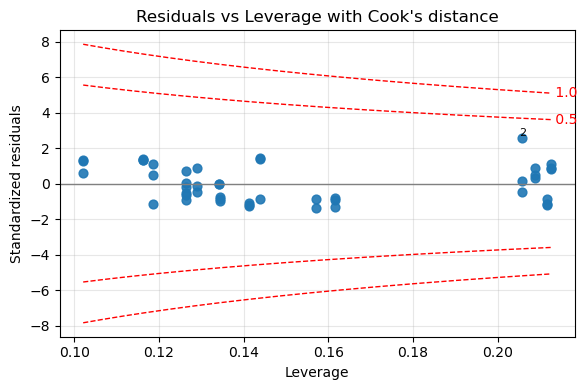

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import OLSInfluence

# ---------------------------------
# 1) Influence measures
# ---------------------------------
infl = OLSInfluence(model)
leverage  = infl.hat_matrix_diag
std_resid = infl.resid_studentized_internal
cooks_d, _ = infl.cooks_distance

# k used in Cook's D formula inside statsmodels
k = model.model.exog.shape[1]

# sample size
n = len(df_use)
cutoff_4_over_n = 4 / n
print(f"4/n cutoff for Cook's distance: {cutoff_4_over_n:.4f}")

# ---------------------------------
# 2) Build diagnostics table
# ---------------------------------
diag = pd.DataFrame({
    "idx": np.arange(len(df_use)),
    "leverage": leverage,
    "std_resid": std_resid,
    "cooks_d": cooks_d,
})

# classify by Cook's D
diag["region"] = pd.cut(
    diag["cooks_d"],
    bins=[-np.inf, 0.5, 1.0, np.inf],
    labels=["D < 0.5", "0.5 <= D < 1.0", "D >= 1.0"],
)

# flag observations above 4/n
diag["above_4_over_n"] = diag["cooks_d"] > cutoff_4_over_n

print("\nPoints with Cook's D > 4/n:")
print(diag.loc[diag["above_4_over_n"], ["idx", "leverage", "std_resid", "cooks_d"]])

# ---------------------------------
# 3) Plot: Residuals vs Leverage with Cook's contours
# ---------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

color_map = {
    "D < 0.5": "tab:blue",
    "0.5 <= D < 1.0": "tab:orange",
    "D >= 1.0": "tab:red",
}

for region, grp in diag.groupby("region"):
    ax.scatter(
        grp["leverage"],
        grp["std_resid"],
        label=region,
        alpha=0.9,
        s=40,
        color=color_map[region],
    )

# optionally label the 4/n points on the plot
for _, row in diag[diag["above_4_over_n"]].iterrows():
    ax.text(row["leverage"], row["std_resid"], str(int(row["idx"])),
            fontsize=8, ha="center", va="bottom")

ax.set_xlabel("Leverage")
ax.set_ylabel("Standardized residuals")
ax.set_title("Residuals vs Leverage with Cook's distance")

# Cook's distance contours that match statsmodels
lev_grid = np.linspace(leverage.min(), leverage.max(), 200)
lev_grid = lev_grid[(lev_grid > 0) & (lev_grid < 1)]

for d in [0.5, 1.0]:
    r_grid = np.sqrt(d * k * (1 - lev_grid) / lev_grid)
    ax.plot(lev_grid,  r_grid, "r--", linewidth=1)
    ax.plot(lev_grid, -r_grid, "r--", linewidth=1)
    ax.text(lev_grid[-1], r_grid[-1], f" {d}", color="r", va="center")

ax.axhline(0, color="grey", lw=1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Coefficient of variation without this point

Rows dropped: 1


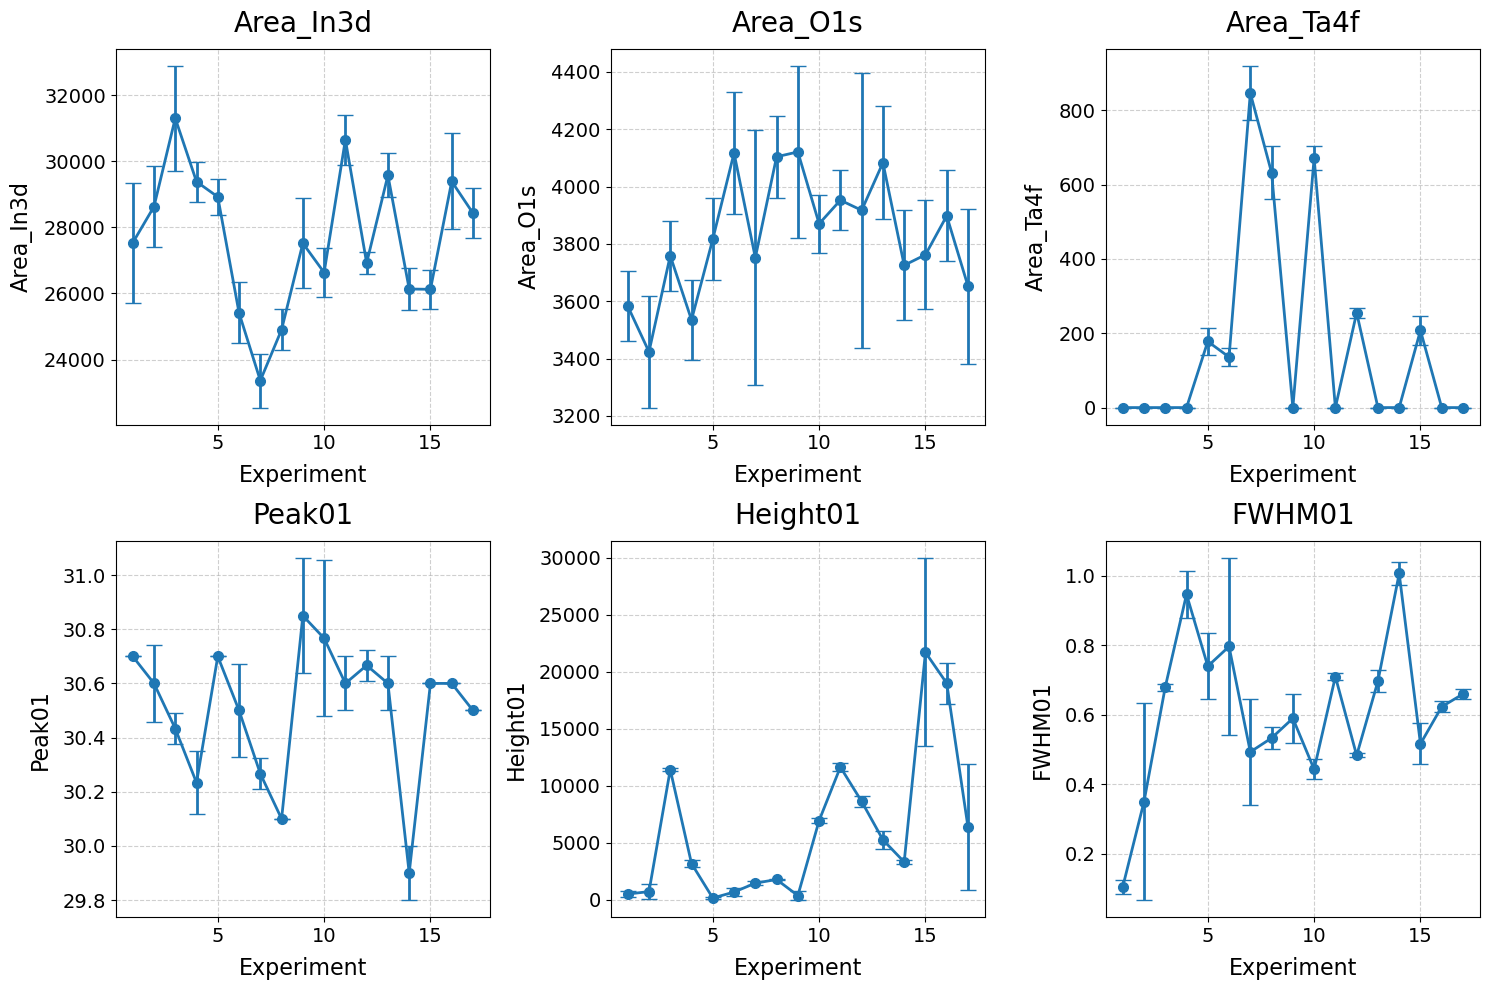

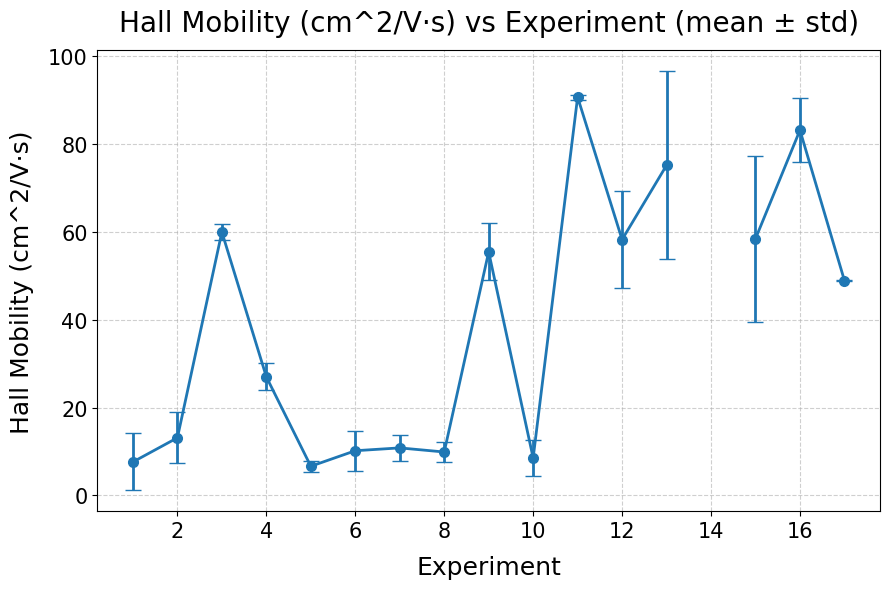

Coefficient of variation per experiment (percent):


,CV_%_Area_In3d,CV_%_Area_O1s,CV_%_Area_Ta4f,CV_%_Peak01,CV_%_Height01,CV_%_FWHM01,CV_%_Hall Mobility (cm^2/V·s)
Experiment,,,,,,,
1,6.605,3.394,nan,0.000,50.200,20.203,85.299
2,4.295,5.680,nan,0.462,92.257,80.812,44.049
3,5.074,3.237,nan,0.190,1.339,1.471,3.000
4,2.043,3.940,nan,0.382,9.652,7.190,11.264
5,1.916,3.764,20.419,0.000,34.032,12.891,18.470
6,3.639,5.132,17.890,0.568,56.718,31.862,45.191
7,3.497,11.835,8.691,0.191,11.845,30.764,27.956
8,2.481,3.469,11.211,0.000,4.629,5.728,23.420
9,4.953,7.291,nan,0.688,105.509,11.985,11.708


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) Drop the specific row (Experiment 1, replicate with 49.5 mobility, O2, 10 W, 25 °C, etc.)
mask_outlier = (
    (master_df["Experiment"] == 1) &
    (master_df["Power (W)"] == 10) &
    (master_df["Substrate Temp (°C)"] == 25) &
    (master_df["O2 Flow (sccm)"] == 0.3) &
    (master_df["Pressure (mTorr)"] == 2) &
    (master_df["Anneal Temp (°C)"] == 150) &
    (master_df["Hall Mobility (cm^2/V·s)"] == 49.5)
)

print("Rows dropped:", mask_outlier.sum())

df_clean = master_df.loc[~mask_outlier].copy()

# 1) columns we want to analyze
cols_to_agg = [
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Peak01",
    "Height01",
    "FWHM01",
    "Hall Mobility (cm^2/V·s)",
]

# keep only those that exist
cols_to_agg = [c for c in cols_to_agg if c in df_clean.columns]

# 2) group by experiment and compute mean and std
grp_mean = df_clean.groupby("Experiment")[cols_to_agg].mean(numeric_only=True)
grp_std  = df_clean.groupby("Experiment")[cols_to_agg].std(numeric_only=True)

# separate hall mobility if present
hall_col = "Hall Mobility (cm^2/V·s)"
has_hall = hall_col in cols_to_agg

# variables to plot in the 3x2 grid (exclude hall mobility)
grid_cols = [c for c in cols_to_agg if c != hall_col]

# 3) make a 2x3 figure for XPS features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, grid_cols):
    x = grp_mean.index.values
    y = grp_mean[col].values
    yerr = grp_std[col].values

    ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=6, markersize=7, linewidth=2)
    ax.set_title(col, fontsize=20, pad=12)
    ax.set_xlabel("Experiment", fontsize=16, labelpad=8)
    ax.set_ylabel(col, fontsize=16, labelpad=8)
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.grid(True, linestyle="--", alpha=0.6)

# hide any unused axes
for i in range(len(grid_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# 3b) plot hall mobility separately
if has_hall:
    plt.figure(figsize=(9, 6))
    x = grp_mean.index.values
    y = grp_mean[hall_col].values
    yerr = grp_std[hall_col].values

    plt.errorbar(x, y, yerr=yerr, fmt="o-", capsize=6, markersize=7, linewidth=2)
    plt.title(f"{hall_col} vs Experiment (mean ± std)", fontsize=20, pad=14)
    plt.xlabel("Experiment", fontsize=18, labelpad=10)
    plt.ylabel(hall_col, fontsize=18, labelpad=10)
    plt.tick_params(axis="both", which="major", labelsize=15)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# 4) coefficient of variation (CV = std / mean) as percent
cv_df = (grp_std / grp_mean.replace(0, np.nan)) * 100
cv_df = cv_df.add_prefix("CV_%_")

print("Coefficient of variation per experiment (percent):")
display(cv_df.style.format("{:.3f}").background_gradient(cmap="Blues"))

cv_df.to_excel("output/cv_percetage_no_outlier.xlsx", index_label=False)


## Re-fitting the model without the detected cooks distance outlier 

High Cook's distance points:
   Power (W)  Substrate Temp (°C)  Anneal Condition Num  O2 Flow (sccm)  \
2         10                   25                     1             0.3   

   Pressure (mTorr)  Anneal Temp (°C)  Area_In3d  Area_O1s  Area_Ta4f  \
2                 2               150    28042.0    3617.0        0.0   

   Height01  Height02  Height03  Hall Mobility (cm^2/V·s)   cooks_d  
2      1261       630         0                      49.5  0.238397  
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.767
Model:                                       OLS   Adj. R-squared:                  0.730
Method:                            Least Squares   F-statistic:                     20.82
Date:                           Thu, 12 Feb 2026   Prob (F-statistic):           1.24e-10
Time:                                   12:12:39   Log-Likelihood:                -

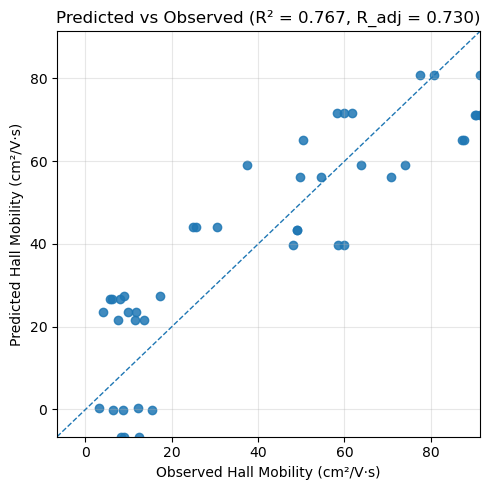

In [16]:
from statsmodels.stats.outliers_influence import OLSInfluence

# -------------------------
# 1) Get Cook's distance
# -------------------------
influence = OLSInfluence(model)
cooks_d = influence.cooks_distance[0]   # array of D_i

# Put Cook's D back on the data frame (same index order)
df_cd = df_use.copy()
df_cd["cooks_d"] = cooks_d

# Rule-of-thumb cutoff (you can also use 4/(n - k - 1), here 4/n is fine)
n = df_cd.shape[0]
cutoff = 4 / n

high_cd = df_cd["cooks_d"] > cutoff
print("High Cook's distance points:")
print(df_cd.loc[high_cd])

# -------------------------
# 2) Drop the high-D point(s) and refit
# -------------------------
df_refit = df_cd.loc[~high_cd].drop(columns="cooks_d")

model_refit = smf.ols(formula=formula, data=df_refit).fit()
print(model_refit.summary())

anova_refit = anova_lm(model_refit, typ=2)
anova_refit.index = [clean_term_name(t) for t in anova_refit.index]
print("\n=== ANOVA after removing high Cook's distance point(s) ===")
anova_refit.to_excel("output/anova_no_high_cooksd.xlsx")
print(anova_refit)
plot_pred_vs_observed(model_refit, df_refit, target_col=target)



### not significant predictors to consider removing:

In [17]:
# =========================
# Non-significant predictors (by ANOVA, after refit)
# =========================

alpha = 0.05  # significance level; change if you want (e.g. 0.10)

# anova_refit already computed in the previous cell
# Drop the Residual row and keep terms with p-value > alpha
nonsig_terms = (
    anova_refit
    .drop(index=["Residual"], errors="ignore")
    .loc[anova_refit["PR(>F)"] > alpha]
)

print(f"Non-significant terms at alpha = {alpha}:")
if nonsig_terms.empty:
    print("  None – all terms are significant at this level.")
else:
    print(nonsig_terms[["df", "F", "PR(>F)"]])


Non-significant terms at alpha = 0.05:
                       df         F    PR(>F)
Anneal Condition Num  1.0  0.002920  0.957187
Pressure (mTorr)      1.0  0.008075  0.928869


## Residuals vs predicted plot

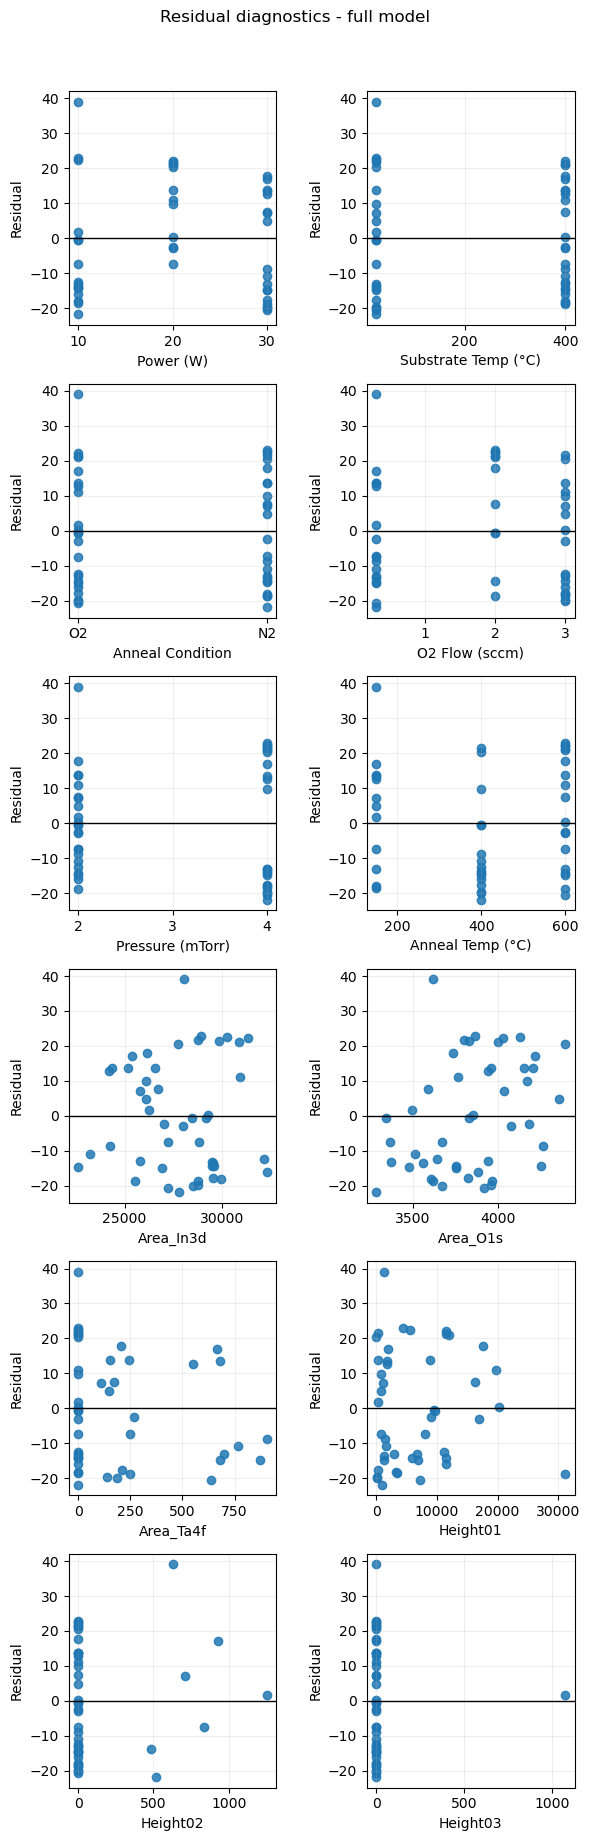

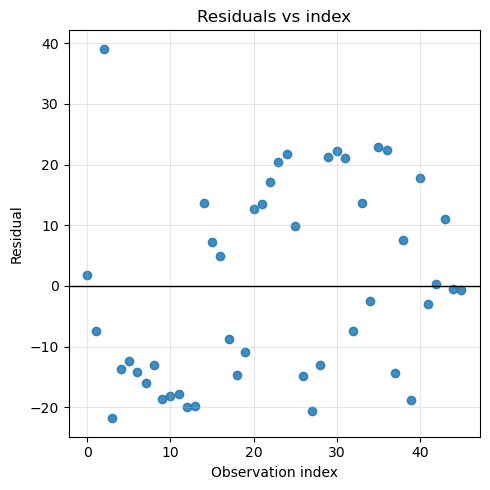

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import math

def plot_residuals_vs_predictors(
    model,
    df,
    predictors,
    categorical_cols=None,
    jitter_std=0.0,
    include_index_plot=True,
    title_prefix="Residuals vs predictors"
):
    """
    Make residuals vs predictor plots for a fitted statsmodels OLS model.

    Parameters
    ----------
    model : statsmodels RegressionResultsWrapper
        Fitted OLS model (from smf.ols(...).fit()).
    df : pandas.DataFrame
        Data frame used for the residual plots (same structure as used to fit).
    predictors : list of str
        Column names in df to use as predictors on the x-axes.
    categorical_cols : list of str or None
        Columns that should be treated as categorical and jittered on x.
        Example: ["Anneal Condition Num"].
    jitter_std : float
        Standard deviation of normal noise added to categorical x for jitter.
    include_index_plot : bool
        If True, also plot residuals vs observation index.
    title_prefix : str
        Optional prefix for a super-title (not required).
    """
    if categorical_cols is None:
        categorical_cols = []

    # Residuals from the model (on this data)
    resid = model.resid

    # Layout for subplots
    n = len(predictors)
    n_cols = 2
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, 3 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, predictors):
        x = df[col].values
        y = resid.values

        if col in categorical_cols:
            # jitter categorical levels on x-axis
            x_plot = x.astype(float) + np.random.normal(0, jitter_std, size=len(x))
            ax.scatter(x_plot, y, alpha=0.85)
            ax.set_xticks(sorted(np.unique(x)))
        else:
            ax.scatter(x, y, alpha=0.85)

        ax.axhline(0, color="k", linewidth=1)
        ax.set_xlabel(col, fontsize=10)
        ax.set_ylabel("Residual", fontsize=10)
        ax.grid(alpha=0.2)

    # Hide any unused axes
    for i in range(len(predictors), len(axes)):
        axes[i].set_visible(False)

    if title_prefix:
        fig.suptitle(title_prefix, fontsize=12, y=1.02)

    plt.tight_layout()
    plt.show()

    # Optional residuals vs index plot
    if include_index_plot:
        plt.figure(figsize=(5, 5))
        plt.scatter(np.arange(len(resid)), resid, alpha=0.85)
        plt.axhline(0, color="k", linewidth=1)
        plt.xlabel("Observation index")
        plt.ylabel("Residual")
        plt.title("Residuals vs index")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_residuals_vs_predictors(
    model=model,
    df=df_use,
    predictors=predictors,  # your existing list
    categorical_cols=["Anneal Condition Num"],
    title_prefix="Residual diagnostics - full model"
)



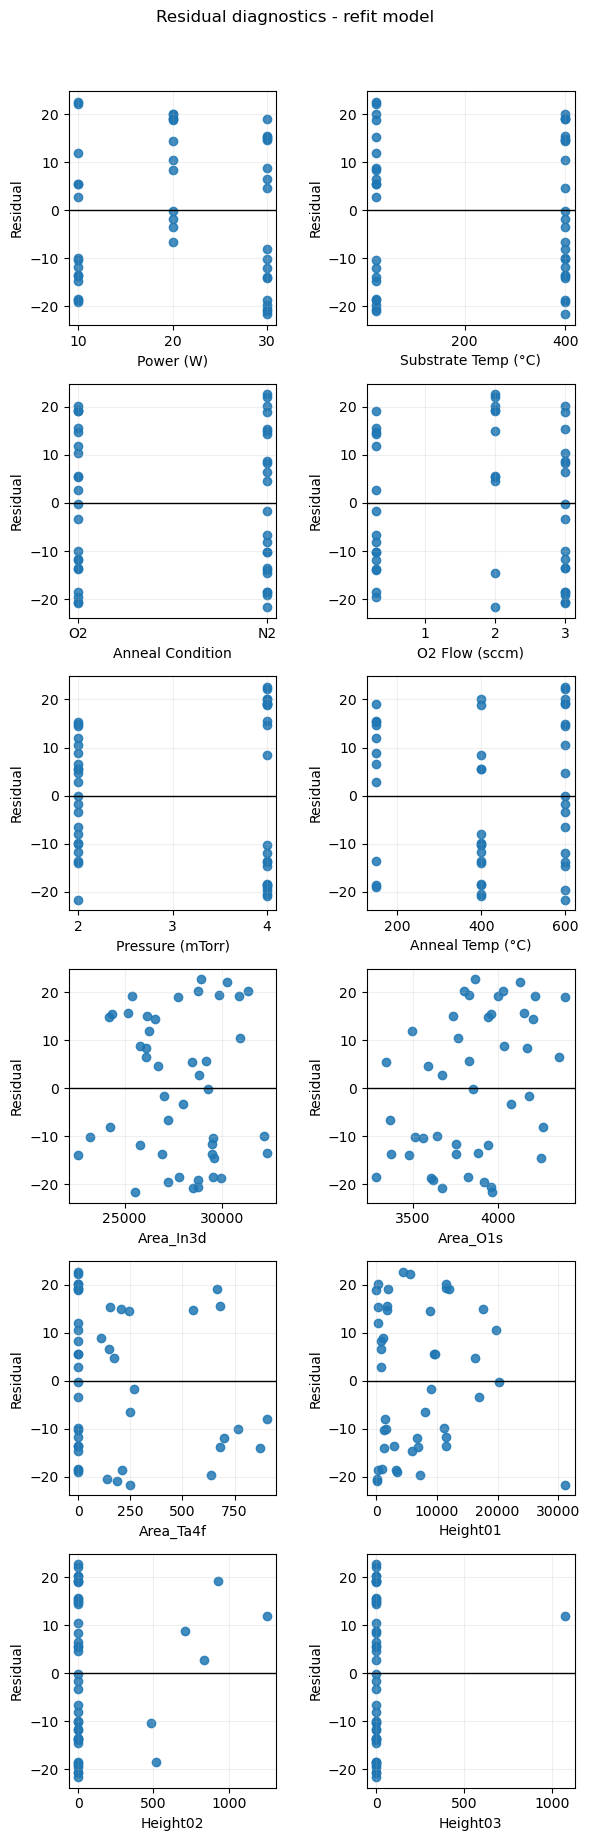

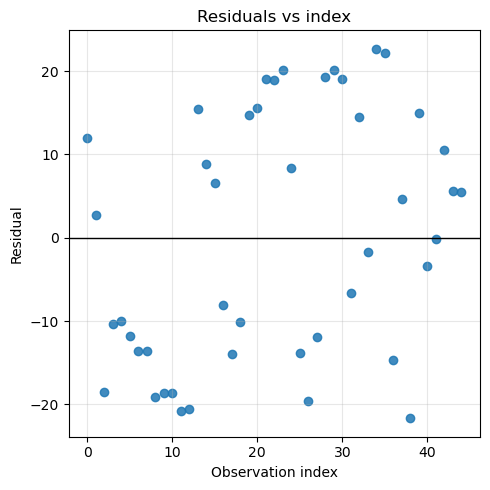

In [33]:
plot_residuals_vs_predictors(
    model=model_refit,
    df=df_refit,
    predictors=predictors,
    categorical_cols=["Anneal Condition Num"],
    title_prefix="Residual diagnostics - refit model"
)


## Threshold based on p-value pval_threshold = 0.10

In [29]:
# Get Type II ANOVA table
anova_table = anova_lm(model, typ=2)
anova_table.index = [clean_term_name(t) for t in anova_table.index]

alpha = 0.10  # p-value threshold

terms_to_keep = []
terms_not_sig = []

for term in anova_table.index:
    if term == "Residual":
        continue

    pval = anova_table.loc[term, "PR(>F)"]

    if pval < alpha:
        terms_to_keep.append(term)
    else:
        terms_not_sig.append(term)

print(f"Using alpha = {alpha}")
print("\nStatistically significant terms (p < alpha):")
for t in terms_to_keep:
    print(f"  - {t} (p = {anova_table.loc[t, 'PR(>F)']:.4f})")

print("\nNot statistically significant terms (p ≥ alpha):")
for t in terms_not_sig:
    print(f"  - {t} (p = {anova_table.loc[t, 'PR(>F)']:.4f})")


Using alpha = 0.1

Statistically significant terms (p < alpha):
  - Power (W) (p = 0.0311)
  - Power (W) × Anneal Condition Num (p = 0.0067)
  - Substrate Temp (°C) (p = 0.0001)
  - Substrate Temp (°C) × Anneal Condition Num (p = 0.0005)
  - Anneal Condition Num × O2 Flow (sccm) (p = 0.0031)
  - Pressure (mTorr) (p = 0.0073)
  - Anneal Temp (°C) (p = 0.0000)
  - Power (W) × Substrate Temp (°C) (p = 0.0442)
  - Power (W) × O2 Flow (sccm) (p = 0.0042)
  - Power (W) × Pressure (mTorr) (p = 0.0006)
  - Substrate Temp (°C) × O2 Flow (sccm) (p = 0.0008)
  - Substrate Temp (°C) × Pressure (mTorr) (p = 0.0392)
  - O2 Flow (sccm) × Anneal Temp (°C) (p = 0.0493)
  - Pressure (mTorr) × Anneal Temp (°C) (p = 0.0112)

Not statistically significant terms (p ≥ alpha):
  - Anneal Condition Num (p = 1.0000)
  - O2 Flow (sccm) (p = 0.1994)
  - Anneal Condition Num × Pressure (mTorr) (p = 0.9649)
  - Anneal Condition Num × Anneal Temp (°C) (p = 0.2561)
  - Power (W) × Anneal Temp (°C) (p = 0.2048)
  - Su

Reduced model formula:
Q('Hall Mobility (cm^2/V·s)') ~ C(Q('Anneal Condition Num')) + Q('Anneal Temp (°C)') + Q('O2 Flow (sccm)') + Q('Power (W)') + Q('Pressure (mTorr)') + Q('Substrate Temp (°C)') + Q('Power (W)'):C(Q('Anneal Condition Num')) + Q('Substrate Temp (°C)'):C(Q('Anneal Condition Num')) + C(Q('Anneal Condition Num')):Q('O2 Flow (sccm)') + Q('Power (W)'):Q('Substrate Temp (°C)') + Q('Power (W)'):Q('O2 Flow (sccm)') + Q('Power (W)'):Q('Pressure (mTorr)') + Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)') + Q('Substrate Temp (°C)'):Q('Pressure (mTorr)') + Q('O2 Flow (sccm)'):Q('Anneal Temp (°C)') + Q('Pressure (mTorr)'):Q('Anneal Temp (°C)')
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.827
Model:                                       OLS   Adj. R-squared:                  0.747
Method:                            Least Squares   F-statistic:            

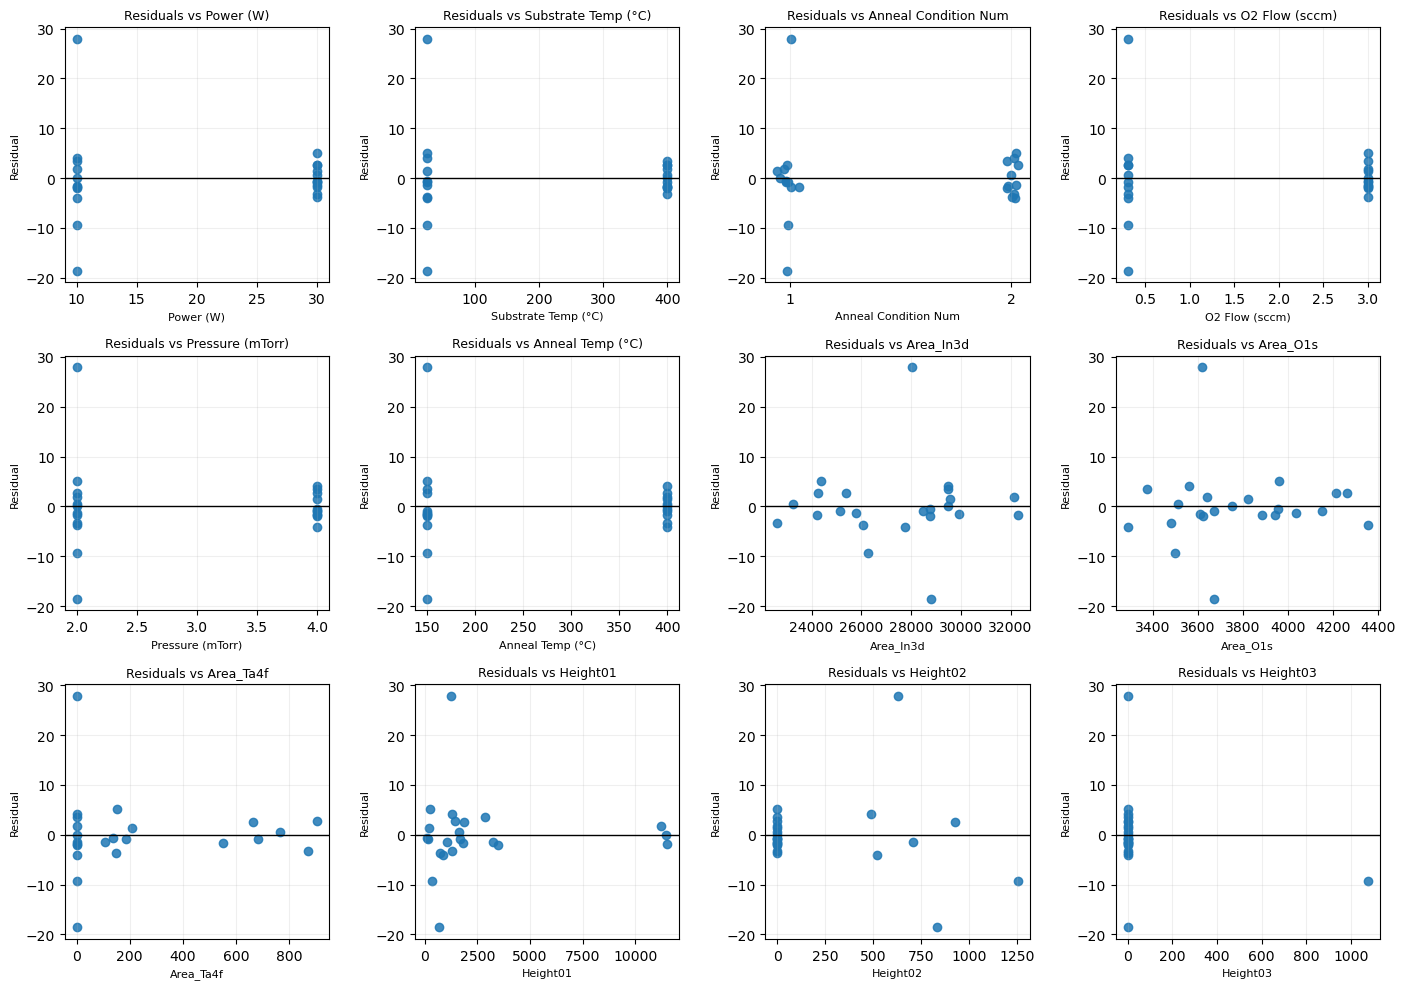

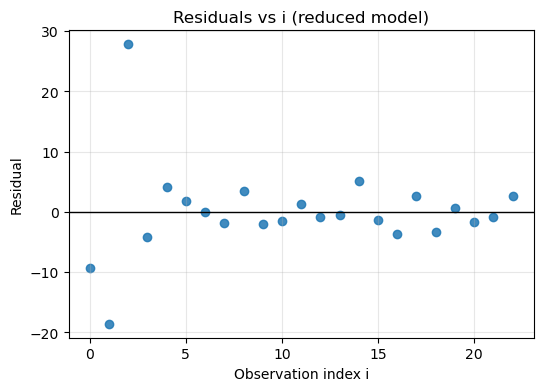

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]
target = "Hall Mobility (cm^2/V·s)"

df_use = master_df[predictors + [target]].dropna()

# =====================================================
# Terms you decided to keep
# =====================================================
kept_terms = [
    "Anneal Condition Num",
    "Power (W)",
    "Power (W) × Anneal Condition Num",
    "Substrate Temp (°C)",
    "Substrate Temp (°C) × Anneal Condition Num",
    "O2 Flow (sccm)",
    "Anneal Condition Num × O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Power (W) × Substrate Temp (°C)",
    "Power (W) × O2 Flow (sccm)",
    "Power (W) × Pressure (mTorr)",
    "Substrate Temp (°C) × O2 Flow (sccm)",
    "Substrate Temp (°C) × Pressure (mTorr)",
    "O2 Flow (sccm) × Anneal Temp (°C)",
    "Pressure (mTorr) × Anneal Temp (°C)",
]

# Map from cleaned names to patsy expressions
name_to_patsy = {
    "Power (W)": "Q('Power (W)')",
    "Substrate Temp (°C)": "Q('Substrate Temp (°C)')",
    "Anneal Condition Num": "C(Q('Anneal Condition Num'))",
    "O2 Flow (sccm)": "Q('O2 Flow (sccm)')",
    "Pressure (mTorr)": "Q('Pressure (mTorr)')",
    "Anneal Temp (°C)": "Q('Anneal Temp (°C)')",
}

# Build main effect terms (keep all main effects from kept_terms)
main_effect_names = sorted({t for t in kept_terms if "×" not in t})
main_terms_patsy = [name_to_patsy[t] for t in main_effect_names]

# Build interaction terms in patsy syntax
interaction_names = [t for t in kept_terms if "×" in t]
interaction_terms_patsy = []
for t in interaction_names:
    left, right = [x.strip() for x in t.split("×")]
    left_patsy = name_to_patsy[left]
    right_patsy = name_to_patsy[right]
    interaction_terms_patsy.append(f"{left_patsy}:{right_patsy}")

# =====================================================
# Build reduced formula
# =====================================================
rhs_terms = main_terms_patsy + interaction_terms_patsy
formula_reduced = (
    "Q('Hall Mobility (cm^2/V·s)') ~ " + " + ".join(rhs_terms)
)

print("Reduced model formula:")
print(formula_reduced)

# =====================================================
# Fit reduced model
# =====================================================
model_red = smf.ols(formula=formula_reduced, data=df_use).fit()
print(model_red.summary())

# =====================================================
# ANOVA for reduced model (with cleaned names)
# =====================================================

def _clean_single(term: str) -> str:
    term = term.strip()
    if term.startswith("Q('") and term.endswith("')"):
        return term[3:-2]
    if term.startswith("C(Q('") and term.endswith("'))"):
        return term[5:-3]
    return term

def clean_term_name(term: str) -> str:
    if ":" in term:
        parts = term.split(":")
        clean_parts = [_clean_single(p) for p in parts]
        return " × ".join(clean_parts)
    else:
        return _clean_single(term)

anova_red = anova_lm(model_red, typ=2)
anova_red.index = [clean_term_name(t) for t in anova_red.index]

print("\n=== Reduced model ANOVA (Type II, cleaned names) ===")
print(anova_red)

# =====================================================
# Residual plots per predictor (same as before)
# =====================================================
resid = model_red.resid
pred_cols = predictors

n = len(pred_cols)
n_rows = 3
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, pred_cols):
    x = df_use[col].values
    y = resid.values

    if col == "Anneal Condition Num":
        x_plot = x.astype(float) + np.random.normal(0, 0.03, size=len(x))
        ax.scatter(x_plot, y, alpha=0.85)
        ax.set_xticks(sorted(np.unique(x)))
    else:
        ax.scatter(x, y, alpha=0.85)

    ax.axhline(0, color="k", linewidth=1)
    ax.set_title(f"Residuals vs {col}", fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Residual", fontsize=8)
    ax.grid(alpha=0.2)

for i in range(len(pred_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(np.arange(len(resid)), resid, alpha=0.85)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Observation index i")
plt.ylabel("Residual")
plt.title("Residuals vs i (reduced model)")
plt.grid(alpha=0.3)
plt.show()


# Bayesian optimization

In [ ]:
import pandas as pd
import numpy as np
import torch
from botorch.models import SingleTaskGP
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import qExpectedImprovement
from botorch.optim import optimize_acqf

# columns
knob_cols = [
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",   # 0 or 1
    "Anneal Temp (°C)",
]
target_col = "Hall Mobility (cm^2/V·s)"

# 1) drop rows with missing knobs or missing target
df_bo = master_df[knob_cols + [target_col]].copy()
df_bo = df_bo.dropna(subset=knob_cols + [target_col])

# 2) build X and y
X = df_bo[knob_cols].astype(float).values
y = df_bo[target_col].astype(float).values.reshape(-1, 1)

# 3) normalize X to [0,1]
x_min = X.min(axis=0)
x_max = X.max(axis=0)
X_norm = (X - x_min) / (x_max - x_min + 1e-8)

# 4) make tensors
train_X = torch.tensor(X_norm, dtype=torch.double)
train_Y = torch.tensor(y, dtype=torch.double)

# 5) fit GP
model = SingleTaskGP(train_X, train_Y)
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)
print("GP fitted OK, n =", train_X.shape[0])

best_f = train_Y.max()

# 2) build acquisition
q = 1  # number of points to propose at once
acqf = qExpectedImprovement(model=model, best_f=best_f)

# 3) optimize acquisition in [0, 1]^d
bounds = torch.stack(
    [
        torch.zeros(train_X.shape[1], dtype=torch.double),
        torch.ones(train_X.shape[1], dtype=torch.double),
    ]
)

candidate, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=q,
    num_restarts=10,
    raw_samples=64,
)

# 4) unnormalize back to real space
candidate_np = candidate.detach().numpy()

suggestions = []
for row in candidate_np:
    # unnormalize
    real = row * (x_max - x_min) + x_min

    # round the categorical variable
    # find its index
    anneal_idx = knob_cols.index("Anneal Condition Num")
    real[anneal_idx] = round(real[anneal_idx])  # 0 or 1

    suggestions.append(dict(zip(knob_cols, real)))

# 5) print suggestions
for i, s in enumerate(suggestions, 1):
    print(f"Suggested point {i}:")
    for k, v in s.items():
        print(f"  {k}: {v:.3f}")


GP fitted OK, n = 23


/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/botorch/acquisition/monte_carlo.py:396: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Suggested point 1:
  Power (W): 10.000
  Substrate Temp (°C): 400.000
  O2 Flow (sccm): 3.000
  Pressure (mTorr): 2.298
  Anneal Condition Num: 1.000
  Anneal Temp (°C): 344.494


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


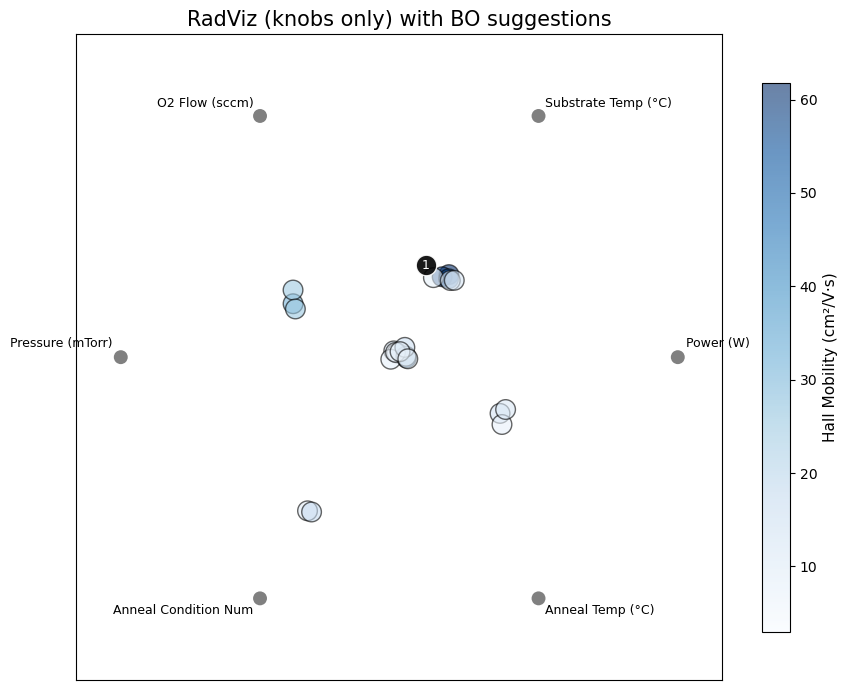

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import radviz

target_col = "Hall Mobility (cm^2/V·s)"

# -------------------------------------------------
# 1) Use only knob parameters for RadViz
# -------------------------------------------------
predictors_knobs = [
    c for c in knob_cols
    if c in master_df.columns and np.issubdtype(master_df[c].dtype, np.number)
]

cols_for_radviz = predictors_knobs + [target_col]
df_radviz = master_df[cols_for_radviz].dropna().copy()

# Bin Hall mobility just to satisfy pandas.radviz (we will hide these points)
df_radviz["HallMobilityBin"] = pd.qcut(
    df_radviz[target_col],
    q=3,
    labels=["Low μ", "Med μ", "High μ"],
)

df_radviz_plot = df_radviz[predictors_knobs + ["HallMobilityBin"]].copy()

# -------------------------------------------------
# 2) Optional jitter in each predictor to break ties (input space)
# -------------------------------------------------
np.random.seed(0)
jitter_strength = 0.02

for col in predictors_knobs:
    vals = df_radviz_plot[col].to_numpy(dtype=float)
    col_range = vals.max() - vals.min()
    if col_range == 0:
        continue
    noise = np.random.normal(0.0, jitter_strength * col_range, size=vals.shape)
    df_radviz_plot[col] = vals + noise

# -------------------------------------------------
# 3) Draw RadViz frame and anchors
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7))
radviz(df_radviz_plot, class_column="HallMobilityBin", ax=ax)

# Remove legend created by radviz
leg = ax.get_legend()
if leg is not None:
    leg.remove()

# Hide the class scatter that radviz drew
for coll in ax.collections:
    coll.set_alpha(0)

ax.set_title("RadViz (knobs only) with BO suggestions", fontsize=15)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

# Pull text labels slightly outward and shrink font
for txt in ax.texts:
    x, y = txt.get_position()
    r = np.sqrt(x**2 + y**2)
    if r > 0:
        new_r = 1.03
        scale = new_r / r
        txt.set_position((x * scale, y * scale))
        txt.set_fontsize(9)

# -------------------------------------------------
# 4) Compute RadViz coordinates for existing data
# -------------------------------------------------
X = df_radviz[predictors_knobs].to_numpy(dtype=float)

X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_range = X_max - X_min
X_range[X_range == 0] = 1.0
X_norm = (X - X_min) / X_range

n_samples, n_features = X_norm.shape
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False)
anchors = np.stack([np.cos(angles), np.sin(angles)], axis=1)

den = X_norm.sum(axis=1)
den[den == 0] = 1e-12
coords = (X_norm @ anchors) / den[:, None]

x_rv = coords[:, 0]
y_rv = coords[:, 1]
hall_vals = df_radviz[target_col].to_numpy(dtype=float)

# ---------- NEW: jitter in RadViz coordinates for background points ----------
rng_bg = np.random.default_rng(123)
rv_jitter = 0.02  # adjust if you want more / less spread
x_rv_j = x_rv + rng_bg.normal(0.0, rv_jitter, size=x_rv.shape)
y_rv_j = y_rv + rng_bg.normal(0.0, rv_jitter, size=y_rv.shape)

# Continuous Hall mobility background
sc = ax.scatter(
    x_rv_j,
    y_rv_j,
    c=hall_vals,
    cmap="Blues",
    s=200,
    alpha=0.6,
    edgecolor="k",
    zorder=2,
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Hall Mobility (cm²/V·s)", fontsize=11)

# -------------------------------------------------
# 5) Overlay BO suggested points as black dots
# -------------------------------------------------
suggest_df = pd.DataFrame(suggestions)

# Keep only the knob columns used in RadViz
cand_X = suggest_df[predictors_knobs].astype(float).to_numpy()

cand_norm = (cand_X - X_min) / X_range
den_cand = cand_norm.sum(axis=1)
den_cand[den_cand == 0] = 1e-12
coords_cand = (cand_norm @ anchors) / den_cand[:, None]

x_cand = coords_cand[:, 0]
y_cand = coords_cand[:, 1]

# ---------- NEW: small jitter for suggested points too ----------
rng_cand = np.random.default_rng(456)
cand_jitter = 0.015
x_cand_j = x_cand + rng_cand.normal(0.0, cand_jitter, size=x_cand.shape)
y_cand_j = y_cand + rng_cand.normal(0.0, cand_jitter, size=y_cand.shape)

ax.scatter(
    x_cand_j,
    y_cand_j,
    c="k",
    s=220,
    alpha=0.9,
    edgecolor="white",
    linewidths=1.0,
    zorder=5,
)

# Optional: label suggested points 1, 2, 3
for i, (xc, yc) in enumerate(zip(x_cand_j, y_cand_j), start=1):
    ax.text(
        xc,
        yc,
        str(i),
        color="white",
        fontsize=9,
        ha="center",
        va="center",
        zorder=6,
    )

plt.tight_layout()
plt.show()


# LVGP

In [ ]:
print(master_df.columns.tolist())

['Experiment', 'Trial', 'Anneal Condition Num', 'Power (W)', 'Substrate Temp (°C)', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Condition', 'Anneal Temp (°C)', 'Hall Mobility (cm^2/V·s)', 'In3d_p1', 'In3d_p2', 'O1s_p1', 'Ta4f_p1', 'Ta4f_p2', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Peak01', 'Peak02', 'Peak03', 'Height01', 'Height02', 'Height03', 'FWHM01', 'FWHM02', 'FWHM03']


In [ ]:
import pandas as pd
import numpy as np
import torch

from botorch.models import SingleTaskGP
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll

knob_cols = [
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",   # 0 or 1
    "Anneal Temp (°C)",
]
target_col = "Hall Mobility (cm^2/V·s)"

# 1) Clean data: drop rows with missing knobs or target
df_bo = master_df[knob_cols + [target_col]].copy()
df_bo = df_bo.dropna(subset=knob_cols + [target_col])

# Make sure anneal condition is 0/1 numeric
df_bo["Anneal Condition Num"] = df_bo["Anneal Condition Num"].astype(float)

# 2) Build X and y
X = df_bo[knob_cols].values.astype(float)
y = df_bo[target_col].values.astype(float).reshape(-1, 1)

# 3) Normalize X to [0,1] for each dimension
x_min = X.min(axis=0)
x_max = X.max(axis=0)
X_norm = (X - x_min) / (x_max - x_min + 1e-8)

train_X = torch.tensor(X_norm, dtype=torch.double)
train_Y = torch.tensor(y, dtype=torch.double)

# 4) Fit GP
model = SingleTaskGP(train_X, train_Y)
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

print("GP fitted, n =", train_X.shape[0])


GP fitted, n = 23


In [ ]:
from botorch.acquisition import qExpectedImprovement
from botorch.optim import optimize_acqf

# 1) Best Hall mobility observed so far
best_f = train_Y.max()

# 2) EI acquisition function
acqf = qExpectedImprovement(model=model, best_f=best_f)

d = train_X.shape[1]  # number of inputs
bounds = torch.stack(
    [torch.zeros(d, dtype=torch.double),
     torch.ones(d, dtype=torch.double)]
)

# 3) Optimize EI in [0,1]^d (continuous)
q = 4  # number of points to suggest
candidate, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=q,
    num_restarts=10,
    raw_samples=64,
)
print(candidate)
# 4) Unnormalize to real units
candidate_np = candidate.detach().numpy()[0]
suggested = candidate_np * (x_max - x_min) + x_min

# 5) Round ONLY the anneal condition to 0 or 1
anneal_idx = knob_cols.index("Anneal Condition Num")
suggested[anneal_idx] = round(suggested[anneal_idx])  # 0 or 1

# 6) Pack suggestions in a readable dict
suggestion = dict(zip(knob_cols, suggested))

print("Suggested next experiment:")
for k, v in suggestion.items():
    print(f"  {k}: {v:.3f}")


/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/botorch/acquisition/monte_carlo.py:396: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


tensor([[0.0000, 1.0000, 0.6722, 0.0000, 0.0000, 1.0000],
        [0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.6466],
        [0.0000, 1.0000, 1.0000, 0.3392, 0.0000, 1.0000],
        [0.0000, 1.0000, 1.0000, 0.0000, 0.3387, 1.0000]], dtype=torch.float64)
Suggested next experiment:
  Power (W): 10.000
  Substrate Temp (°C): 400.000
  O2 Flow (sccm): 2.115
  Pressure (mTorr): 2.000
  Anneal Condition Num: 1.000
  Anneal Temp (°C): 400.000


# Trees 

In [12]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, root_mean_squared_error

# -------------------------------
# 0) Same setup as your OLS code
# -------------------------------
predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical (treated as numeric codes here)
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]
target = "Hall Mobility (cm^2/V·s)"

exclude_for_model = {
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
    # you currently keep "Anneal Condition Num" in the model
}

# build clean df
df_use = master_df[predictors + [target]].dropna()

# ------------------------------------------
# 1) Select features
# ------------------------------------------
feature_cols = [col for col in predictors if col not in exclude_for_model]
X = df_use[feature_cols].values
y = df_use[target].values

print("Features used:", feature_cols)

# ------------------------------------------
# 2) Fit regression tree on ALL data
# ------------------------------------------
tree_reg = DecisionTreeRegressor(
    max_depth=3,        # tweak as you like
    min_samples_leaf=3,
    random_state=0,
)
tree_reg.fit(X, y)

# ------------------------------------------
# 3) In-sample performance
# ------------------------------------------
y_pred = tree_reg.predict(X)

rmse_in = root_mean_squared_error(y, y_pred)
r2_in = r2_score(y, y_pred)

print(f"In-sample RMSE = {rmse_in:.3f}")
print(f"In-sample R²   = {r2_in:.3f}")

# ------------------------------------------
# 4) Cross-validated performance (no explicit test split)
# ------------------------------------------
cv_r2 = cross_val_score(tree_reg, X, y, cv=5, scoring="r2")
cv_rmse = -cross_val_score(
    tree_reg, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("\nCV R² (5-fold):", np.round(cv_r2, 3), " | mean =", cv_r2.mean().round(3))
print("CV RMSE (5-fold):", np.round(cv_rmse, 3), " | mean =", cv_rmse.mean().round(3))

# ------------------------------------------
# 5) Feature importances
# ------------------------------------------
importances = tree_reg.feature_importances_
imp_df = pd.DataFrame(
    {"feature": feature_cols, "importance": importances}
).sort_values("importance", ascending=False)

print("\nFeature importances")
print(imp_df.to_string(index=False))


Features used: ['Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)']
In-sample RMSE = 11.255
In-sample R²   = 0.861

CV R² (5-fold): [ -0.154 -32.863   0.178  -0.204  -2.497]  | mean = -7.108
CV RMSE (5-fold): [23.261 35.379 20.093 28.233 32.095]  | mean = 27.812

Feature importances
             feature  importance
           Power (W)    0.428956
    Anneal Temp (°C)    0.344737
      O2 Flow (sccm)    0.121893
Anneal Condition Num    0.104414
 Substrate Temp (°C)    0.000000
    Pressure (mTorr)    0.000000


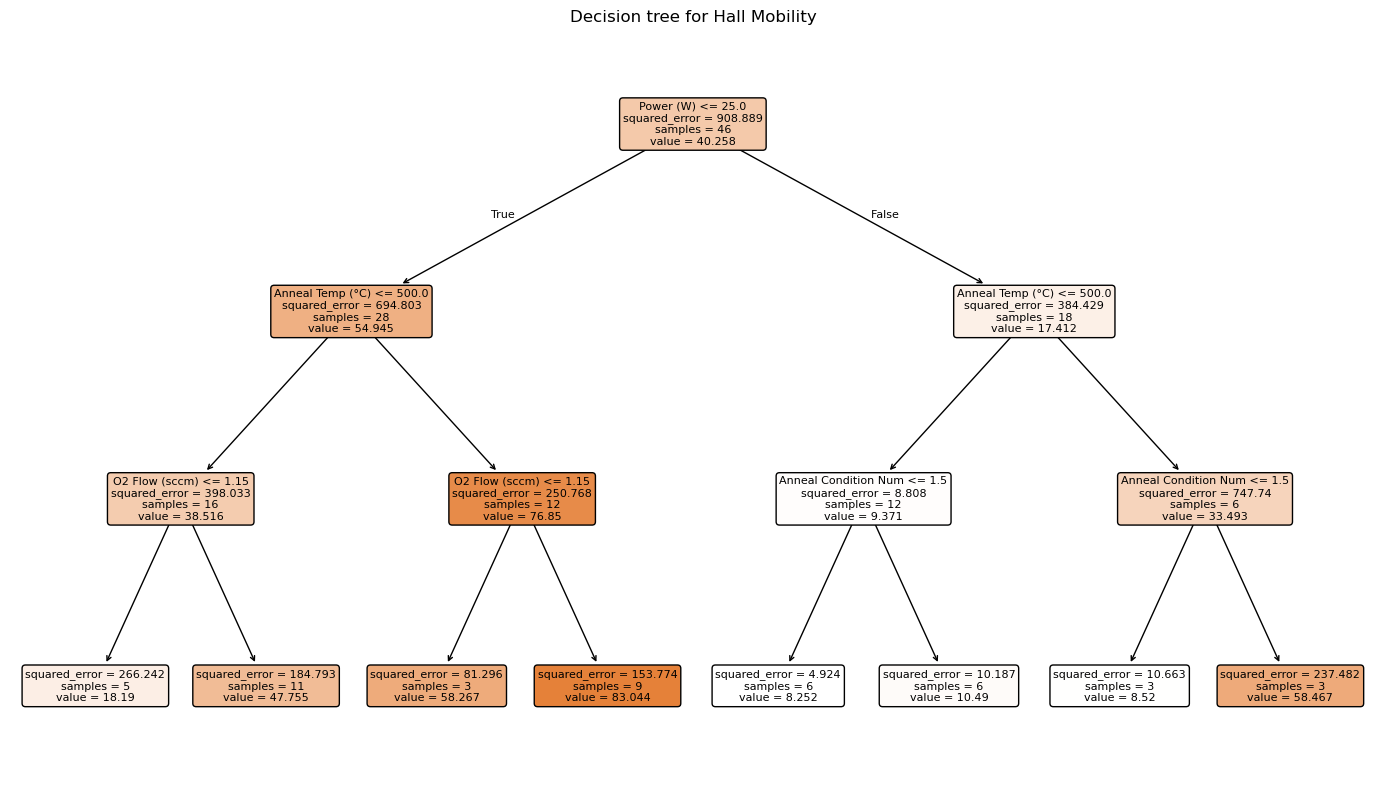

In [13]:
import matplotlib.pyplot as plt
from sklearn import tree

# ------------------------------------------
# Plot the decision tree
# ------------------------------------------
plt.figure(figsize=(14, 8))

tree.plot_tree(
    tree_reg,
    feature_names=feature_cols,
    filled=True,          # color leaves by value
    rounded=True,
    fontsize=8
)

plt.title("Decision tree for Hall Mobility")
plt.tight_layout()
plt.show()


Number of candidate alphas: 12

CPTABLE (like rpart$cptable):
     alpha  n_leaves  depth   cv_rmse  rel_error
  0.000000        14      5 31.940977   1.018168
  0.013636        14      5 33.459666   1.066578
  0.335589        11      5 31.978799   1.019373
  1.850580        10      5 35.719233   1.138605
  2.077973         9      4 34.959695   1.114394
  6.019758         8      4 35.719233   1.138605
 30.029589         8      4 33.611751   1.071426
 38.627142         7      4 31.371040   1.000000
 65.317159         6      3 31.552801   1.005794
 65.973742         3      2 31.552801   1.005794
219.059524         2      1 35.467571   1.130583
335.537357         1      0 38.094588   1.214323

Best alpha (min CV RMSE): 38.627142, leaves = 7, cv_rmse = 31.371


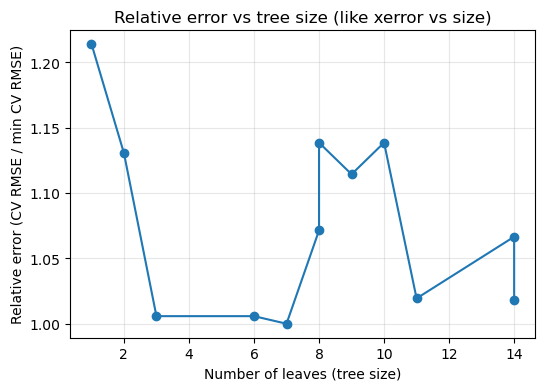

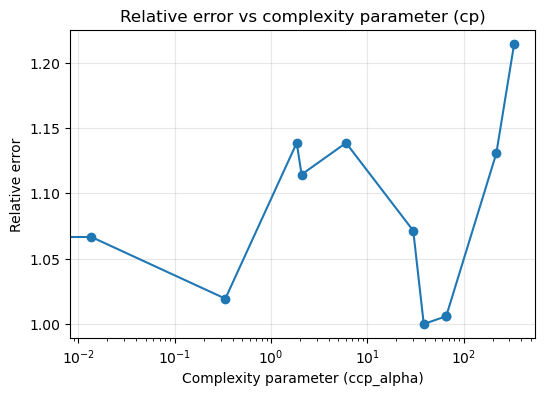

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

# ------------------------------------------
# 0) Cost-complexity pruning path
# ------------------------------------------
base_tree = DecisionTreeRegressor(
    random_state=0,
    min_samples_leaf=3,
    # do NOT set max_depth here, let pruning control complexity
)

path = base_tree.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas  # like cp in rpart
impurities = path.impurities

print("Number of candidate alphas:", len(ccp_alphas))

# ------------------------------------------
# 1) Fit a tree for each alpha and do CV
# ------------------------------------------
trees = []
cv_rmse_list = []
n_leaves_list = []
depth_list = []

for alpha in ccp_alphas:
    tree_reg = DecisionTreeRegressor(
        # random_state=15,
        min_samples_leaf=3,
        ccp_alpha=alpha,
    )
    # 5-fold CV RMSE
    cv_rmse = -cross_val_score(
        tree_reg,
        X,
        y,
        cv=3,
        scoring="neg_root_mean_squared_error",
    )
    cv_rmse_list.append(cv_rmse.mean())

    tree_reg.fit(X, y)
    trees.append(tree_reg)
    n_leaves = np.sum(tree_reg.tree_.children_left == -1)
    n_leaves_list.append(n_leaves)
    depth_list.append(tree_reg.get_depth())

cv_rmse_array = np.array(cv_rmse_list)

# relative error: CV RMSE relative to the *smallest* CV RMSE
best_rmse = cv_rmse_array.min()
rel_error = cv_rmse_array / best_rmse

# ------------------------------------------
# 2) Build a cptable-like summary
# ------------------------------------------
cptable = pd.DataFrame({
    "alpha": ccp_alphas,
    "n_leaves": n_leaves_list,
    "depth": depth_list,
    "cv_rmse": cv_rmse_array,
    "rel_error": rel_error,
})

# find best (min CV error)
best_idx = np.argmin(cv_rmse_array)
best_alpha = ccp_alphas[best_idx]
best_n_leaves = n_leaves_list[best_idx]

print("\nCPTABLE (like rpart$cptable):")
print(cptable.head(15).to_string(index=False))  # show first 15 rows

print(f"\nBest alpha (min CV RMSE): {best_alpha:.6f}, "
      f"leaves = {best_n_leaves}, "
      f"cv_rmse = {best_rmse:.3f}")

# ------------------------------------------
# 3) Plots similar to R: relative error vs size and vs cp
# ------------------------------------------

# (a) relative error vs number of leaves
plt.figure(figsize=(6, 4))
plt.plot(n_leaves_list, rel_error, marker="o")
plt.xlabel("Number of leaves (tree size)")
plt.ylabel("Relative error (CV RMSE / min CV RMSE)")
plt.title("Relative error vs tree size (like xerror vs size)")
plt.grid(alpha=0.3)
plt.show()

# (b) relative error vs complexity parameter alpha
plt.figure(figsize=(6, 4))
plt.plot(ccp_alphas, rel_error, marker="o")
plt.xlabel("Complexity parameter (ccp_alpha)")
plt.ylabel("Relative error")
plt.title("Relative error vs complexity parameter (cp)")
plt.grid(alpha=0.3)
plt.xscale("log")  # cp / alpha often looks better on log scale
plt.show()


Best-pruned tree:
  n_leaves: 7
  depth   : 4
R² (on all data) = 0.870


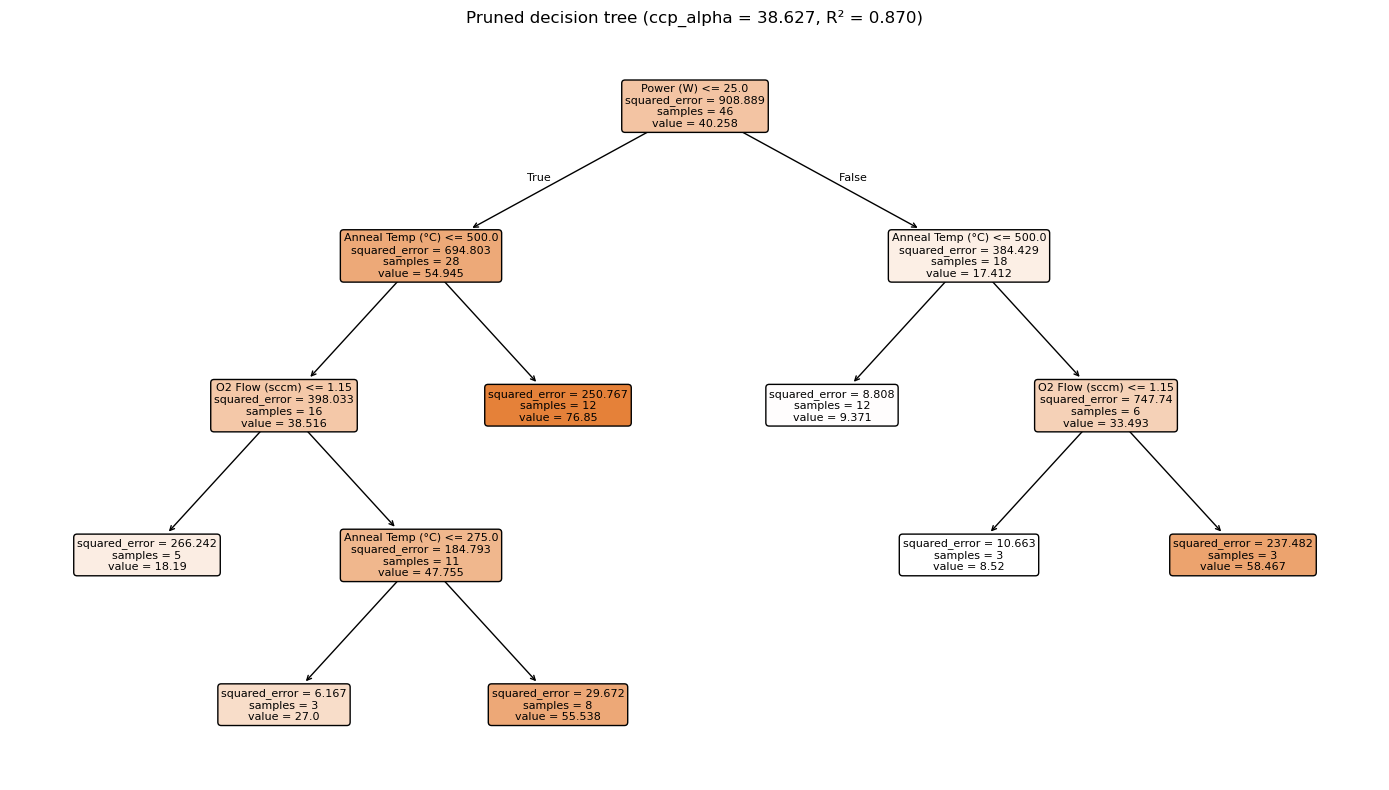


Feature importances:
             feature  importance
           Power (W)    0.424468
    Anneal Temp (°C)    0.389994
      O2 Flow (sccm)    0.185537
 Substrate Temp (°C)    0.000000
Anneal Condition Num    0.000000
    Pressure (mTorr)    0.000000


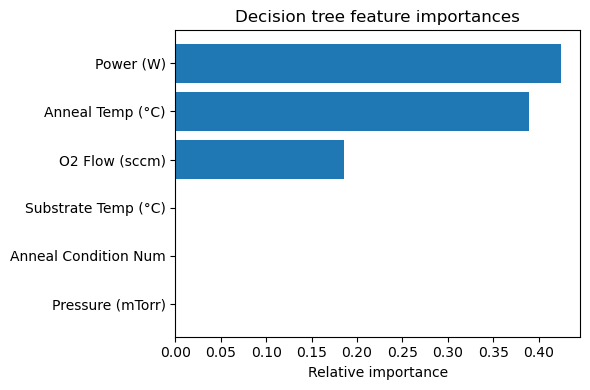

In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.metrics import r2_score

# -------------------------------
# 1) Refit the best-pruned tree
# -------------------------------
best_alpha = 0  # or use the value you printed from cptable

# tree_best = DecisionTreeRegressor(
#     random_state=0,
#     min_samples_leaf=3,
#     ccp_alpha=best_alpha,
# )

best_tree = trees[best_idx]

# use the selected best tree and refit on all data
tree_best = best_tree
# tree_best.fit(X, y)

print("Best-pruned tree:")
print("  n_leaves:", np.sum(tree_best.tree_.children_left == -1))
print("  depth   :", tree_best.get_depth())

# ---- R² on all data ----
y_pred = tree_best.predict(X)
r2 = r2_score(y, y_pred)
print(f"R² (on all data) = {r2:.3f}")

# -------------------------------
# 2) Plot the pruned tree
# -------------------------------
plt.figure(figsize=(14, 8))

tree.plot_tree(
    tree_best,
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    f"Pruned decision tree (ccp_alpha = {tree_best.ccp_alpha:.3f}, R² = {r2:.3f})"
)
plt.tight_layout()
plt.show()
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1) Get importances
importances = tree_best.feature_importances_   # one value per feature
imp_df = pd.DataFrame(
    {"feature": feature_cols, "importance": importances}
).sort_values("importance", ascending=False)

print("\nFeature importances:")
print(imp_df.to_string(index=False))

# 2) (Optional) Bar plot
plt.figure(figsize=(6, 4))
plt.barh(imp_df["feature"], imp_df["importance"])
plt.gca().invert_yaxis()  # most important on top
plt.xlabel("Relative importance")
plt.title("Decision tree feature importances")
plt.tight_layout()
plt.show()


In [16]:
print(trees[best_idx].ccp_alpha)

38.62714179841896
